# HDBSCAN Clustering Pipeline v2

**Author:** Nadia ELORGA-CASTAGNET  
**CHU de Bordeaux - Master 2 PHDS 2025/2026**

## Pipeline overview

```
CHUNK 1 - Configuration, imports, column definitions
CHUNK 2 - All functions
CHUNK 3 - STEP 1: Distance matrix + 2D grid sweep (mcs x min_samples)
CHUNK 4 - STEP 2: Final run with full visualizations
```

## Key changes from v1
- **2D grid sweep**: sweeps mcs AND min_samples simultaneously, all values as % of N
- min_samples always << mcs -> fewer outliers
- 4 heatmaps per run: outlier rate, silhouette, combined score, n_clusters
- cluster_selection_method = 'leaf' available as alternative to 'eom'
- All hyperparameter values derived from N -> portable to N=120000 without code changes


---
## CHUNK 1 - Configuration, Imports & Column Definitions


In [1]:
# ==============================================================================
# 0. CONFIGURATION
# ==============================================================================

CSV_PATH   = "df_final_binaire_imputed.csv"
OUTPUT_DIR = "Results/Regular_clustering/Full_dataset/With_counts"

GPU_DEVICE_ID = 1

SCALERS = ["minmax", "standard"]

UMAP_N_NEIGHBORS  = 30
UMAP_MIN_DIST     = 0.0
UMAP_N_COMPONENTS = 10
UMAP_RANDOM_STATE = 42

VIZ_N_NEIGHBORS = 30
VIZ_MIN_DIST    = 0.1
VIZ_TSNE_PERP   = 30
VIZ_TSNE_ITER   = 1500

# 'eom'  = Excess of Mass (fewer clusters, more outliers)
# 'leaf' = leaf clusters (more clusters, fewer outliers) <- try this to reduce outliers
HDBSCAN_CLUSTER_METHOD = "eom"

# 2D Grid sweep - parametrized as % of N
# mcs: 0.5% to 5% of N (minimum cluster size)
# ms : 1% to 20% of mcs (local density - always much smaller than mcs -> fewer outliers)
MCS_PCT_VALUES    = [0.02, 0.03, 0.04, 0.05]
MS_PCT_MCS_VALUES = [0.01, 0.05, 0.10, 0.20]
MS_FIXED_VALUES   = [1, 5, 10, 15]


# -------------------------------------------------------------------------------------------

# Final run parameters - UPDATE AFTER CHUNK 3
FINAL_PARAMS = {
    "s2_noweights_minmax"    : (500, 10),
    "s2_noweights_standard"  : (500, 10),
    "s2_hosp3x_minmax"       : (500, 10),
    "s2_hosp3x_standard"     : (500, 10),
    "s3_noweights"           : (500, 10),
    "s3_catdown"             : (500, 10),

}


# ------------------------------------------------------------------------------------------

# Combined score weight


N_MIN_CLUSTERS = 5
N_MAX_CLUSTERS = 15

W_SILHOUETTE = 0.35
W_STABILITY  = 0.25
W_OUTLIER    = 0.25
W_NCLUSTERS  = 0.15


# ------------------------------------------------------------------------------------------

WEIGHT_HOSP_S2          = 3.0
WEIGHT_BIO_VEINOUS      = 1 / 29
WEIGHT_IMAGING_DETAILED = 1 / 12
WEIGHT_HOSP_S3          = 5.0

BIO_BINS    = [-1, 0, 1, 2, 10]
BIO_LABELS  = ["0", "1", "2", "3+"]
IMAG_BINS   = [-1, 0, 1, 2, 10]
IMAG_LABELS = ["0", "1", "2", "3+"]

# ==============================================================================
# 1. IMPORTS
# ==============================================================================

import os, logging, time, pickle
import gower, hdbscan
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import torch
import umap
import umap.umap_ as umap_reduce
from datetime import datetime
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

log = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")

torch.cuda.set_device(GPU_DEVICE_ID)
torch.cuda.set_per_process_memory_fraction(0.5, device=GPU_DEVICE_ID)
print(f"GPU : {torch.cuda.get_device_name(GPU_DEVICE_ID)}")
print(f"Available memory : {torch.cuda.get_device_properties(GPU_DEVICE_ID).total_memory / 1e9:.0f} GB")

# ==============================================================================
# 2. COLUMN DEFINITIONS
# ==============================================================================

IMAGING_COLS_BOOL = {"has_ultrasound", "has_ct_scan", "has_xray", "has_mri"}

IMAGING_COLS_DETAILED = {
    "ultrasound_1", "ultrasound_2",
    "ct_scan_1", "ct_scan_2", "ct_scan_3",
    "xray_1", "xray_2", "xray_3",
    "mri_1", "mri_2",
}

BIO_VEINOUS = {
    "is_hemoglobine", "is_leucocytes", "is_formule_leuco",
    "is_urea", "is_creatinine", "is_sodium", "is_potassium",
    "is_platelets", "is_pt", "is_aptt", "is_calcium", "is_ck",
    "is_lactates", "is_troponine", "is_bnp", "is_ckmb", "is_ddimer",
    "is_crp", "is_pct", "is_alat", "is_asat", "is_bili_total",
    "is_lipase", "is_alp", "is_iron", "is_ferritin",
    "is_calcium_ionized", "is_aXa_aIIa", "is_fibrinogen",
}

BIO_EXAMS        = {"has_blood_test", "has_culture", "has_lumbar_puncture", "has_blood_gas"}
PROCEDURE_COLS   = {"had_ekg"}
DISPOSITION_COLS = {"hospitalization", "observation_unit",
                    #"inter_facility_transfer"
                    }
COLS_QUANTI      = ["imaging_exam_count", "bio_exam_count"]

SCENARIOS = {
    "scenario_2": list(IMAGING_COLS_BOOL | BIO_EXAMS | PROCEDURE_COLS | DISPOSITION_COLS) + COLS_QUANTI,
    "scenario_3": list(IMAGING_COLS_BOOL | BIO_EXAMS | PROCEDURE_COLS | DISPOSITION_COLS
                       | IMAGING_COLS_DETAILED | BIO_VEINOUS) + COLS_QUANTI,
}

print(f"Scenario 2: {len(SCENARIOS['scenario_2'])} variables")
print(f"Scenario 3: {len(SCENARIOS['scenario_3'])} variables")


GPU : NVIDIA A100-SXM4-80GB
Available memory : 85 GB
Scenario 2: 13 variables
Scenario 3: 52 variables


---
## CHUNK 2 - All Functions


In [2]:
# ==============================================================================
# FUNCTION 1: Data loading
# ==============================================================================

def load_and_preprocess(csv_path=CSV_PATH):
    df = pd.read_csv(csv_path, low_memory=False)
    df["bio_exam_cat"]     = pd.cut(df["bio_exam_count"],     bins=BIO_BINS,  labels=BIO_LABELS)
    df["imaging_exam_cat"] = pd.cut(df["imaging_exam_count"], bins=IMAG_BINS, labels=IMAG_LABELS)
    for col in ("bio_exam_count", "imaging_exam_count"):
        dist = (df[col].value_counts(dropna=False).sort_index()
                .rename_axis(col).reset_index(name="n"))
        dist["pct"] = (dist["n"] / dist["n"].sum() * 100).round(1)
        log.info(f"\n{col} distribution:\n{dist.to_string(index=False)}")
    return df


# ==============================================================================
# FUNCTION 2: GPU distance matrix (Scenario 2)
# Hamming for binary (double-zeros count as similarity).
# Manhattan for quantitative after scaling.
# ==============================================================================

def compute_distance_matrix_gpu(df_sub, binary_cols, cat_cols, quanti_cols,
                                  weight_hosp=1.0, weight_quanti=1.0,
                                  scaler="minmax", device_id=GPU_DEVICE_ID):
    device = torch.device(f"cuda:{device_id}")
    n      = len(df_sub)
    D      = torch.zeros((n, n), device=device, dtype=torch.float32)

    for col in binary_cols:
        vals = torch.tensor(df_sub[col].values, dtype=torch.float32, device=device).unsqueeze(1)
        d    = torch.cdist(vals, vals, p=1)
        w    = weight_hosp if col == "hospitalization" else 1.0
        D   += d * w

    for col in cat_cols:
        codes = torch.tensor(df_sub[col].cat.codes.values, dtype=torch.float32, device=device).unsqueeze(1)
        D    += (codes != codes.T).float()

    if quanti_cols:
        q = df_sub[quanti_cols].values.astype("float32")
        q_scaled = (MinMaxScaler().fit_transform(q) if scaler == "minmax"
                    else StandardScaler().fit_transform(q)).astype("float32")
        q_tensor = torch.tensor(q_scaled, dtype=torch.float32, device=device)
        D       += torch.cdist(q_tensor, q_tensor, p=1) * weight_quanti

    D.fill_diagonal_(0)
    return D.cpu().numpy().astype(np.float64)


# ==============================================================================
# FUNCTION 3: Main HDBSCAN run
# Returns: (df_sub, D, fit_input, labels, clusterer)
# ==============================================================================

def run_hdbscan(df, scenario_name, run_label, distance_metric,
                scaler="minmax", weight_hosp=1.0, weight_quanti=1.0,
                gower_weights=None, min_cluster_size=500, min_samples=10):

    sc_dir = os.path.join(OUTPUT_DIR,
                          scaler if distance_metric == "precomputed" else "gower",
                          run_label)
    os.makedirs(sc_dir, exist_ok=True)

    cols   = [c for c in SCENARIOS[scenario_name] if c in df.columns]
    df_sub = df[cols].copy()

    if scenario_name == "scenario_3":
        essential = [c for c in cols if c not in IMAGING_COLS_DETAILED and c not in BIO_VEINOUS]
        df_sub    = df_sub.dropna(subset=essential)
    else:
        df_sub = df_sub.dropna()

    idx         = df_sub.index
    quanti_cols = [c for c in COLS_QUANTI if c in df_sub.columns]
    binary_cols = [c for c in df_sub.columns
                   if c not in quanti_cols and set(df_sub[c].dropna().unique()) <= {0, 1}]
    cat_cols    = [c for c in df_sub.columns if c not in binary_cols and c not in quanti_cols]
    for col in cat_cols:
        df_sub[col] = df_sub[col].astype("category")

    log.info(f"[{run_label}] n={len(df_sub)} | binary={len(binary_cols)} | cat={len(cat_cols)} | quanti={len(quanti_cols)}")

    t0       = time.time()
    col_list = list(df_sub.columns)
    n_vars   = len(col_list)

    if distance_metric == "gower":
        df_gower = df_sub.copy()
        for col in df_gower.select_dtypes(include="integer").columns:
            df_gower[col] = df_gower[col].astype("float64")
        for col in df_gower.select_dtypes(include="category").columns:
            df_gower[col] = df_gower[col].astype("object")
        weights = np.ones(n_vars)
        if gower_weights:
            for col, w in gower_weights.items():
                if col in col_list:
                    weights[col_list.index(col)] = w
        weights        = weights / weights.sum() * n_vars
        D              = gower.gower_matrix(df_gower, weight=weights).astype(np.float64)
        np.fill_diagonal(D, 0)
        fit_input      = D
        hdbscan_metric = "precomputed"
    else:
        D = compute_distance_matrix_gpu(
            df_sub, binary_cols=binary_cols, cat_cols=cat_cols,
            quanti_cols=quanti_cols, weight_hosp=weight_hosp,
            weight_quanti=weight_quanti, scaler=scaler,
        )
        fit_input      = D
        hdbscan_metric = "precomputed"

    log.info(f"[{run_label}] Distance matrix: {time.time()-t0:.1f}s")

    if scenario_name == "scenario_3":
        t0      = time.time()
        reducer = umap_reduce.UMAP(
            n_neighbors=UMAP_N_NEIGHBORS, min_dist=UMAP_MIN_DIST,
            n_components=UMAP_N_COMPONENTS, metric="precomputed",
            random_state=UMAP_RANDOM_STATE,
        )
        emb = reducer.fit_transform(D)
        np.save(os.path.join(sc_dir, "umap_embedding.npy"), emb)
        log.info(f"[{run_label}] UMAP shape={emb.shape} - {time.time()-t0:.1f}s")
        fit_input      = emb
        hdbscan_metric = "euclidean"

    t0        = time.time()
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size, min_samples=min_samples,
        metric=hdbscan_metric, cluster_selection_method=HDBSCAN_CLUSTER_METHOD,
        gen_min_span_tree=True,
    ).fit(fit_input)
    log.info(f"[{run_label}] HDBSCAN: {time.time()-t0:.1f}s")

    labels     = clusterer.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    log.info(f"[{run_label}] clusters={n_clusters} | noise={n_noise} ({100*n_noise/len(labels):.1f}%)")

    df_out            = df.loc[idx].copy()
    df_out["cluster"] = labels
    df_out.to_csv(os.path.join(sc_dir, f"clustering_mcs{min_cluster_size}_ms{min_samples}.csv"), index=False)

    return df_sub, D, fit_input, labels, clusterer


# ==============================================================================
# FUNCTION 4: 2D Grid sweep - mcs x min_samples as % of N
#
# Key principle: min_samples << mcs
#   Large min_samples -> stricter density -> MORE outliers
#   Small min_samples -> looser density  -> FEWER outliers
#
# All values derived from N -> same code works for N=30000 and N=120000
# ==============================================================================

def make_mcs_ms_grid(N):
    grid = []
    for mcs_pct in MCS_PCT_VALUES:
        mcs = max(10, int(N * mcs_pct))
        ms_values = sorted(set(MS_FIXED_VALUES + [max(1, int(mcs * p)) for p in MS_PCT_MCS_VALUES]))
        for ms in ms_values:
            grid.append({
                "mcs":        mcs,
                "ms":         ms,
                "mcs_pct_N":  round(mcs / N * 100, 2),
                "ms_pct_mcs": round(ms / mcs * 100, 2),
            })
    return grid



def cluster_score(n, n_min=N_MIN_CLUSTERS, n_max=N_MAX_CLUSTERS):
    if n_min <= n <= n_max:
        return 1.0
    elif n < n_min:
        return max(0.0, (n - 2) / (n_min - 2))
    else:
        return max(0.0, (50 - n) / (50 - n_max))



def run_grid_sweep(fit_input, metric, run_label, out_dir, N):
    """
    2D grid sweep over (mcs, min_samples).
    Outputs: CSV + 4 heatmaps + top-10 summary tables.
    """
    if metric == "precomputed":
        np.fill_diagonal(fit_input, 0)

    grid = make_mcs_ms_grid(N)
    print(f"\n Grid: {len(grid)} combinations for N={N:,}")
    print(f"   mcs range: {int(N*MCS_PCT_VALUES[0]):,} - {int(N*MCS_PCT_VALUES[-1]):,}")
    print(f"   ms  range: fixed {MS_FIXED_VALUES} + {[str(round(p*100))+'%mcs' for p in MS_PCT_MCS_VALUES]}")

    results = []
    for params in grid:
        mcs = params["mcs"]
        ms  = params["ms"]

        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=mcs, min_samples=ms,
            metric=metric, cluster_selection_method=HDBSCAN_CLUSTER_METHOD,
            gen_min_span_tree=False,
        ).fit(fit_input)

        labels       = clusterer.labels_
        n_clusters   = len(np.unique(labels[labels >= 0]))
        outlier_rate = float(np.mean(labels == -1))
        sil = (silhouette_score(fit_input, labels, metric=metric)
               if n_clusters >= 2 else np.nan)
        stability = (float(np.mean(clusterer.cluster_persistence_))
                     if len(clusterer.cluster_persistence_) > 0 else np.nan)

        results.append({
            "mcs":          mcs,
            "mcs_pct_N":    params["mcs_pct_N"],
            "ms":           ms,
            "ms_pct_mcs":   params["ms_pct_mcs"],
            "n_clusters":   n_clusters,
            "outlier_rate": outlier_rate,
            "outlier_pct":  round(outlier_rate * 100, 1),
            "silhouette":   round(sil, 4) if not np.isnan(sil) else np.nan,
            "stability":    round(stability, 4) if not np.isnan(stability) else np.nan,
        })

        sil_str = f"{sil:.3f}" if not np.isnan(sil) else "nan"
        log.info(f"[{run_label}] mcs={mcs:5d} ({params['mcs_pct_N']:.2f}%N) | "
                 f"ms={ms:4d} ({params['ms_pct_mcs']:.1f}%mcs) | "
                 f"clusters={n_clusters} | outliers={outlier_rate*100:.1f}% | sil={sil_str}")

    df_res = pd.DataFrame(results)

    # ── Combined score ──────────────────────────────────────────────
    def _minmax(s):
        mn, mx = s.min(), s.max()
        return (s - mn) / (mx - mn) if mx != mn else s * 0

    df_res["combined_score"] = (
        W_SILHOUETTE * _minmax(df_res["silhouette"].fillna(0))
        + W_STABILITY  * _minmax(df_res["stability"].fillna(0))
        - W_OUTLIER    * df_res["outlier_rate"]
        + W_NCLUSTERS  * df_res["n_clusters"].apply(cluster_score)
    ).round(4)

    # ── Save CSV ────────────────────────────────────────────────────
    os.makedirs(out_dir, exist_ok=True)
    df_res.to_csv(os.path.join(out_dir, f"grid_sweep_{run_label}.csv"), index=False)

    # ── Heatmaps ────────────────────────────────────────────────────
    for value_col, cmap, fmt, title_suffix in [
        ("outlier_pct",    "Reds",    ".1f", "Outlier rate (%)"),
        ("silhouette",     "Greens",  ".3f", "Silhouette score"),
        ("combined_score", "Blues",   ".3f", "Combined score"),
        ("n_clusters",     "YlOrBr",  ".0f", "Number of clusters"),
    ]:
        pivot = df_res.pivot_table(index="ms_pct_mcs", columns="mcs_pct_N",
                                   values=value_col, aggfunc="mean")
        plt.figure(figsize=(max(10, len(pivot.columns) * 1.5), max(5, len(pivot.index) * 0.9)))
        sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap,
                    xticklabels=[f"{v:.2f}%N" for v in pivot.columns],
                    yticklabels=[f"{v:.1f}%mcs" for v in pivot.index])
        plt.title(f"{title_suffix} - {run_label}\n(rows=ms as %mcs | cols=mcs as %N)")
        plt.xlabel("mcs (% of N)")
        plt.ylabel("min_samples (% of mcs)")
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"grid_{run_label}_{value_col}.png"), dpi=150)
        plt.show()

    COLS = ["mcs", "mcs_pct_N", "ms", "ms_pct_mcs", "n_clusters",
            "outlier_pct", "silhouette", "stability", "combined_score"]

    print(f"\n=== TOP 10 lowest outlier rate [{run_label}] ===")
    print(df_res.sort_values("outlier_pct").head(10)[COLS].to_string(index=False))

    print(f"\n=== TOP 10 highest combined score [{run_label}] ===")
    print(df_res.sort_values("combined_score", ascending=False).head(10)[COLS].to_string(index=False))

    print(f"\n=== FULL GRID [{run_label}] ===")
    print(df_res[COLS].sort_values(["mcs", "ms"]).to_string(index=False))

    return df_res


# ==============================================================================
# FUNCTION 5: HDBSCAN native tree visualizations
# Condensed tree, single linkage tree, MST (S3 only), cluster persistence
# ==============================================================================

def plot_hdbscan_trees(clusterer, run_label, out_dir):
    os.makedirs(out_dir, exist_ok=True)

    try:
        fig, ax = plt.subplots(figsize=(14, 7))
        clusterer.condensed_tree_.plot(select_clusters=True, axis=ax, colorbar=True)
        ax.set_title(f"Condensed Tree - {run_label}\nY = lambda = 1/distance | higher = more stable")
        ax.set_xlabel("Points / clusters")
        ax.set_ylabel("lambda (stability)")
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "condensed_tree.png"), dpi=150)
        plt.show()
    except Exception as e:
        log.warning(f"[{run_label}] Condensed tree: {e}")

    try:
        fig, ax = plt.subplots(figsize=(14, 7))
        clusterer.single_linkage_tree_.plot(axis=ax)
        ax.set_title(f"Single Linkage Tree - {run_label}")
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "single_linkage_tree.png"), dpi=150)
        plt.show()
    except Exception as e:
        log.warning(f"[{run_label}] Single linkage tree: {e}")

    try:
        mst = clusterer.minimum_spanning_tree_
        if mst is not None:
            fig, ax = plt.subplots(figsize=(14, 7))
            mst.plot(edge_cmap="viridis", edge_alpha=0.6, node_size=10, axis=ax)
            ax.set_title(f"Minimum Spanning Tree - {run_label}")
            plt.tight_layout()
            plt.savefig(os.path.join(out_dir, "minimum_spanning_tree.png"), dpi=150)
            plt.show()
    except Exception as e:
        log.warning(f"[{run_label}] MST: {e}")

    try:
        persistence = clusterer.cluster_persistence_
        if len(persistence) > 0:
            fig, ax = plt.subplots(figsize=(max(6, len(persistence)), 4))
            colors  = ["#e05c2e" if p == max(persistence) else "#aec6cf" for p in persistence]
            ax.bar(range(len(persistence)), persistence, color=colors)
            ax.set_xlabel("Cluster ID")
            ax.set_ylabel("Persistence (stability)")
            ax.set_title(f"Cluster Persistence - {run_label} (red = most stable)")
            ax.set_xticks(range(len(persistence)))
            plt.tight_layout()
            plt.savefig(os.path.join(out_dir, "cluster_persistence.png"), dpi=150)
            plt.show()
    except Exception as e:
        log.warning(f"[{run_label}] Cluster persistence: {e}")


# ==============================================================================
# FUNCTION 6: Cluster profile heatmap + Ward dendrogram
# Heatmap: mean variable values per cluster (outliers excluded)
# Dendrogram: annotates each merge with the most discriminating variable
# ==============================================================================

def plot_cluster_heatmap(df_sub, labels, title, out_dir, filename):
    os.makedirs(out_dir, exist_ok=True)
    df_prof            = df_sub.copy()
    df_prof["cluster"] = labels
    df_prof            = df_prof[df_prof["cluster"] != -1]
    if df_prof.empty:
        log.warning(f"[{title}] No clusters - heatmap skipped.")
        return pd.DataFrame()
    numeric_cols = [c for c in df_prof.select_dtypes(include=["number"]).columns if c != "cluster"]
    profile      = df_prof[numeric_cols + ["cluster"]].groupby("cluster").mean().round(3)
    if profile.empty:
        return profile
    n_cols = profile.shape[1]
    n_rows = profile.shape[0]
    plt.figure(figsize=(max(8, n_cols * 0.8), max(4, n_rows * 0.6)))
    sns.heatmap(profile, annot=True, cmap="YlOrRd", fmt=".2f",
                annot_kws={"size": max(6, min(10, 80 // n_cols))})
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    path = os.path.join(out_dir, filename)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    log.info(f"Saved: {path}")
    return profile


def plot_cluster_dendrogram(profile, title, out_dir, filename):
    os.makedirs(out_dir, exist_ok=True)
    Z               = linkage(profile.values, method="ward")
    variables       = profile.columns.tolist()
    cluster_vectors = {i: profile.iloc[i].values for i in range(len(profile))}
    plt.figure(figsize=(10, 5))
    dendrogram(Z, labels=profile.index.astype(str))
    plt.gca().grid(False)
    plt.title(title)
    for i, (c1, c2, dist, _) in enumerate(Z):
        c1, c2  = int(c1), int(c2)
        v1, v2  = cluster_vectors[c1], cluster_vectors[c2]
        top_var = variables[np.argmax(np.abs(v1 - v2))]
        cluster_vectors[len(cluster_vectors)] = (v1 + v2) / 2
        plt.text(i + 1, dist, top_var, rotation=45, fontsize=8, va="bottom", ha="center")
    plt.tight_layout()
    path = os.path.join(out_dir, filename)
    plt.savefig(path, dpi=150)
    plt.show()
    log.info(f"Saved: {path}")


# ==============================================================================
# FUNCTION 7: UMAP & t-SNE visualizations (2D png + 3D interactive HTML)
# ==============================================================================

def build_cluster_palette(labels):
    unique_clusters = sorted([c for c in np.unique(labels) if c != -1])
    palette   = (sns.color_palette("tab20", len(unique_clusters)) if len(unique_clusters) <= 20
                 else sns.color_palette("hsv", len(unique_clusters)))
    color_map = {c: palette[i] for i, c in enumerate(unique_clusters)}
    color_map[-1] = "lightgrey"
    return color_map


def _to_hex(color_map, c):
    col = color_map[c]
    return "#d3d3d3" if col == "lightgrey" else mcolors.to_hex(col)


def _scatter_clusters(emb, labels, color_map, title, out_dir, filename):
    unique_clusters = sorted([c for c in np.unique(labels) if c != -1])
    plt.figure(figsize=(9, 7))
    mask_noise = labels == -1
    if mask_noise.any():
        plt.scatter(emb[mask_noise, 0], emb[mask_noise, 1],
                    c="lightgrey", s=8, linewidth=0, label="Outliers (-1)", zorder=1, alpha=0.5)
    for c in unique_clusters:
        mask = labels == c
        plt.scatter(emb[mask, 0], emb[mask, 1], color=color_map[c],
                    s=10, linewidth=0, label=f"C{c}", zorder=2, alpha=0.8)
    plt.title(title)
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left", markerscale=2, fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, filename), dpi=150)
    plt.show()


def plot_umap_2d(X, labels, title, out_dir, filename, metric="precomputed"):
    os.makedirs(out_dir, exist_ok=True)
    emb       = umap.UMAP(n_components=2, n_neighbors=VIZ_N_NEIGHBORS,
                           min_dist=VIZ_MIN_DIST, metric=metric).fit_transform(X)
    color_map = build_cluster_palette(labels)
    _scatter_clusters(emb, labels, color_map, title, out_dir, filename)
    return color_map


def plot_umap_3d_html(X, labels, title, out_dir, filename_html, metric="precomputed", color_map=None):
    os.makedirs(out_dir, exist_ok=True)
    emb = umap.UMAP(n_components=3, n_neighbors=VIZ_N_NEIGHBORS,
                    min_dist=VIZ_MIN_DIST, metric=metric).fit_transform(X)
    if color_map is None:
        color_map = build_cluster_palette(labels)
    unique_clusters = sorted([c for c in np.unique(labels) if c != -1])
    df_plot = pd.DataFrame({"x": emb[:, 0], "y": emb[:, 1], "z": emb[:, 2],
                             "label": [str(l) for l in labels]})
    df_plot["order"] = df_plot["label"].apply(lambda x: -1 if x == "-1" else int(x))
    df_plot = df_plot.sort_values("order")
    fig = px.scatter_3d(df_plot, x="x", y="y", z="z", color="label",
                        color_discrete_map={str(c): _to_hex(color_map, c) for c in list(unique_clusters) + [-1]},
                        title=title, opacity=0.8,
                        category_orders={"label": ["-1"] + [str(c) for c in unique_clusters]})
    fig.update_traces(marker=dict(size=3))
    fig.update_layout(legend_title_text="Cluster")
    fig.write_html(os.path.join(out_dir, filename_html), include_plotlyjs="cdn")
    log.info(f"Saved: {filename_html}")


def plot_tsne_2d(X, labels, title, out_dir, filename, metric="precomputed", color_map=None):
    os.makedirs(out_dir, exist_ok=True)
    init = umap.UMAP(n_components=2, n_neighbors=VIZ_N_NEIGHBORS,
                     min_dist=VIZ_MIN_DIST, metric=metric).fit_transform(X)
    emb  = TSNE(n_components=2, perplexity=VIZ_TSNE_PERP, learning_rate="auto",
                init=init, metric=metric, max_iter=VIZ_TSNE_ITER).fit_transform(X)
    if color_map is None:
        color_map = build_cluster_palette(labels)
    _scatter_clusters(emb, labels, color_map, title, out_dir, filename)


def plot_tsne_3d_html(X, labels, title, out_dir, filename_html, metric="precomputed", color_map=None):
    os.makedirs(out_dir, exist_ok=True)
    init = umap.UMAP(n_components=3, n_neighbors=VIZ_N_NEIGHBORS,
                     min_dist=VIZ_MIN_DIST, metric=metric).fit_transform(X)
    emb  = TSNE(n_components=3, perplexity=VIZ_TSNE_PERP, learning_rate="auto",
                init=init, metric=metric, max_iter=VIZ_TSNE_ITER).fit_transform(X)
    if color_map is None:
        color_map = build_cluster_palette(labels)
    unique_clusters = sorted([c for c in np.unique(labels) if c != -1])
    df_plot = pd.DataFrame({"x": emb[:, 0], "y": emb[:, 1], "z": emb[:, 2],
                             "label": [str(l) for l in labels]})
    fig = px.scatter_3d(df_plot, x="x", y="y", z="z", color="label",
                        color_discrete_map={str(c): _to_hex(color_map, c) for c in list(unique_clusters) + [-1]},
                        title=title, opacity=0.8,
                        category_orders={"label": ["-1"] + [str(c) for c in unique_clusters]})
    fig.update_traces(marker=dict(size=3))
    fig.update_layout(legend_title_text="Cluster")
    fig.write_html(os.path.join(out_dir, filename_html), include_plotlyjs="cdn")
    log.info(f"Saved: {filename_html}")


# ==============================================================================
# FUNCTION 8: Outlier description
# Heatmap + bar chart comparing outliers vs clustered patients
# ==============================================================================

def describe_outliers_internal(df_sub, labels, run_label, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    df_work            = df_sub.copy()
    df_work["cluster"] = labels
    df_noise           = df_work[df_work["cluster"] == -1]
    df_clustered       = df_work[df_work["cluster"] != -1]
    n_noise            = len(df_noise)
    n_total            = len(df_work)
    log.info(f"[{run_label}] Outliers: {n_noise}/{n_total} ({100*n_noise/n_total:.1f}%)")
    if n_noise == 0:
        log.info("No outliers found.")
        return
    numeric_cols = [c for c in df_sub.select_dtypes(include="number").columns]
    compare = pd.DataFrame({
        "outliers":  df_noise[numeric_cols].mean().round(3),
        "clustered": df_clustered[numeric_cols].mean().round(3),
    })
    compare["diff"] = (compare["outliers"] - compare["clustered"]).round(3)
    compare = compare.sort_values("diff", key=abs, ascending=False)

    fig, ax = plt.subplots(figsize=(max(8, len(numeric_cols) * 0.8), 4))
    sns.heatmap(compare[["outliers", "clustered"]].T, annot=True, fmt=".2f",
                cmap="YlOrRd", ax=ax, annot_kws={"size": 8})
    ax.set_title(f"Outliers vs. clustered - {run_label}")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "outliers_heatmap.png"), dpi=150, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(max(8, len(numeric_cols) * 0.8), 5))
    colors  = ["tab:red" if v > 0 else "tab:blue" for v in compare["diff"]]
    ax.bar(compare.index, compare["diff"], color=colors, alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Difference (outliers - clustered)")
    ax.set_title(f"Outlier vs. clustered differences - {run_label}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "outliers_diff.png"), dpi=150)
    plt.show()

    compare.to_csv(os.path.join(out_dir, "outliers_compare.csv"))
    log.info(f"[{run_label}] Outlier description done.")


# ==============================================================================
# FUNCTION 9: Full postprocessing
# Calls all visualization functions for a final run
# ==============================================================================

def run_full_postprocessing(df_sub, D, fit_input, labels, clusterer,
                            run_label, out_dir, metric="precomputed"):
    """
    Full visualization suite:
    1. HDBSCAN native trees (condensed, single linkage, MST, persistence)
    2. Cluster profile heatmap + Ward dendrogram
    3. UMAP 2D/3D + t-SNE 2D/3D
    4. Outlier description (heatmap, bar chart, CSV)
    """
    t_start = time.time()
    os.makedirs(out_dir, exist_ok=True)

    plot_hdbscan_trees(clusterer, run_label, os.path.join(out_dir, "hdbscan_trees"))

    profile = plot_cluster_heatmap(df_sub, labels,
                                   title=f"Cluster profiles - {run_label}",
                                   out_dir=out_dir, filename="heatmap.png")
    if len(profile) >= 2:
        plot_cluster_dendrogram(profile, title=f"Cluster dendrogram - {run_label}",
                                out_dir=out_dir, filename="dendrogram.png")

    viz_input  = fit_input if metric == "euclidean" else D
    viz_metric = metric

    color_map = plot_umap_2d(viz_input, labels, title=f"UMAP 2D - {run_label}",
                             out_dir=out_dir, filename="umap2d.png", metric=viz_metric)
    plot_umap_3d_html(viz_input, labels, title=f"UMAP 3D - {run_label}",
                      out_dir=out_dir, filename_html="umap3d.html",
                      metric=viz_metric, color_map=color_map)
    plot_tsne_2d(viz_input, labels, title=f"t-SNE 2D - {run_label}",
                 out_dir=out_dir, filename="tsne2d.png",
                 metric=viz_metric, color_map=color_map)
    plot_tsne_3d_html(viz_input, labels, title=f"t-SNE 3D - {run_label}",
                      out_dir=out_dir, filename_html="tsne3d.html",
                      metric=viz_metric, color_map=color_map)

    describe_outliers_internal(df_sub, labels, run_label,
                               os.path.join(out_dir, "outliers"))

    log.info(f"[{run_label}] Full postprocessing done in {time.time()-t_start:.1f}s")


print("All functions loaded successfully.")


All functions loaded successfully.


---
## CHUNK 3 - STEP 1: Distance matrix + 2D grid sweep

**Goal:** Jointly identify the optimal (mcs, min_samples) pair for each run.

**What happens here:**
- Distance matrix computed once per run (stored for reuse)
- 2D grid sweep over (mcs, ms) - all values as % of N
- 4 heatmaps per run: outlier rate, silhouette, combined score, n_clusters
- Top 10 configurations by lowest outlier rate and combined score

**After running this chunk:**
1. Look at the heatmaps - find low outlier rate + reasonable n_clusters
2. Update FINAL_PARAMS in Chunk 1
3. Run Chunk 4

**Tip:** Try `HDBSCAN_CLUSTER_METHOD = 'leaf'` in Chunk 1 to reduce outliers.


INFO | 
bio_exam_count distribution:
 bio_exam_count     n  pct
              0 13163 42.5
              1 12344 39.9
              2  4285 13.8
              3  1101  3.6
              4    47  0.2
INFO | 
imaging_exam_count distribution:
 imaging_exam_count     n  pct
                  0 15214 49.2
                  1 13361 43.2
                  2  2183  7.1
                  3   165  0.5
                  4    17  0.1
INFO | [s2_noweights] n=30940 | binary=11 | cat=0 | quanti=2


Dataset loaded: 30,940 patients, 189 variables

Grid parametrization for N=30,940:
  mcs=  154 (0.5%N) | ms=[1, 5, 7, 10, 15, 30]
  mcs=  247 (0.8%N) | ms=[1, 2, 5, 10, 12, 24, 49]
  mcs=  309 (1.0%N) | ms=[1, 3, 5, 10, 15, 30, 61]
  mcs=  464 (1.5%N) | ms=[1, 4, 5, 10, 23, 46, 92]
  mcs=  618 (2.0%N) | ms=[1, 5, 6, 10, 30, 61, 123]
  mcs=  928 (3.0%N) | ms=[1, 5, 9, 10, 46, 92, 185]
  mcs= 1547 (5.0%N) | ms=[1, 5, 10, 15, 77, 154, 309]

SCALER: minmax

--- s2_noweights_minmax ---


INFO | [s2_noweights] Distance matrix: 25.2s
INFO | [s2_noweights] HDBSCAN: 76.0s
INFO | [s2_noweights] clusters=16 | noise=5497 (17.8%)



 Grid: 48 combinations for N=30,940
   mcs range: 154 - 1,547
   ms  range: fixed [1, 5, 10] + ['1%mcs', '5%mcs', '10%mcs', '20%mcs']


INFO | [s2_noweights_minmax] mcs=  154 (0.50%N) | ms=   1 (0.7%mcs) | clusters=45 | outliers=3.7% | sil=0.725
INFO | [s2_noweights_minmax] mcs=  154 (0.50%N) | ms=   5 (3.2%mcs) | clusters=47 | outliers=4.3% | sil=0.746
INFO | [s2_noweights_minmax] mcs=  154 (0.50%N) | ms=   7 (4.5%mcs) | clusters=48 | outliers=5.3% | sil=0.746
INFO | [s2_noweights_minmax] mcs=  154 (0.50%N) | ms=  10 (6.5%mcs) | clusters=45 | outliers=7.8% | sil=0.726
INFO | [s2_noweights_minmax] mcs=  154 (0.50%N) | ms=  15 (9.7%mcs) | clusters=46 | outliers=6.1% | sil=0.707
INFO | [s2_noweights_minmax] mcs=  154 (0.50%N) | ms=  30 (19.5%mcs) | clusters=46 | outliers=5.9% | sil=0.705
INFO | [s2_noweights_minmax] mcs=  247 (0.80%N) | ms=   1 (0.4%mcs) | clusters=37 | outliers=3.8% | sil=0.666
INFO | [s2_noweights_minmax] mcs=  247 (0.80%N) | ms=   2 (0.8%mcs) | clusters=35 | outliers=11.3% | sil=0.665
INFO | [s2_noweights_minmax] mcs=  247 (0.80%N) | ms=   5 (2.0%mcs) | clusters=38 | outliers=7.2% | sil=0.687
INFO | [

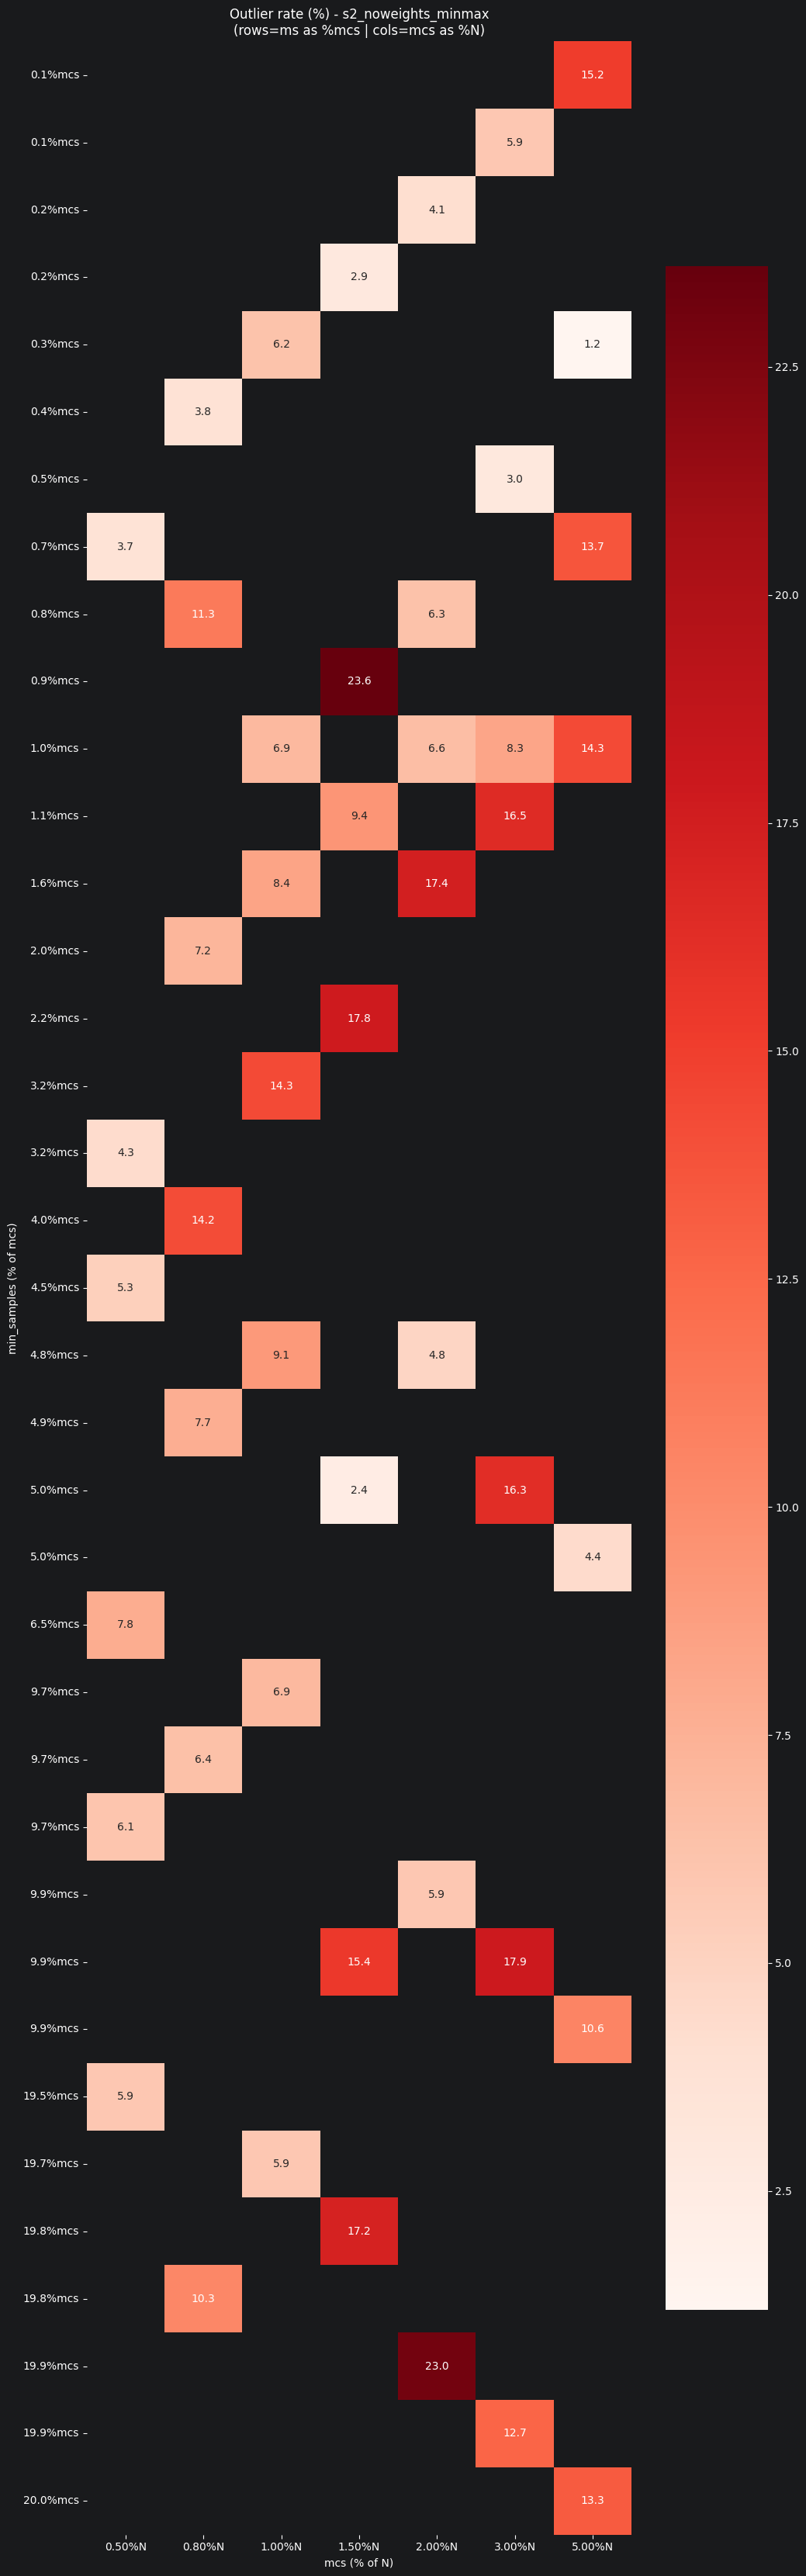

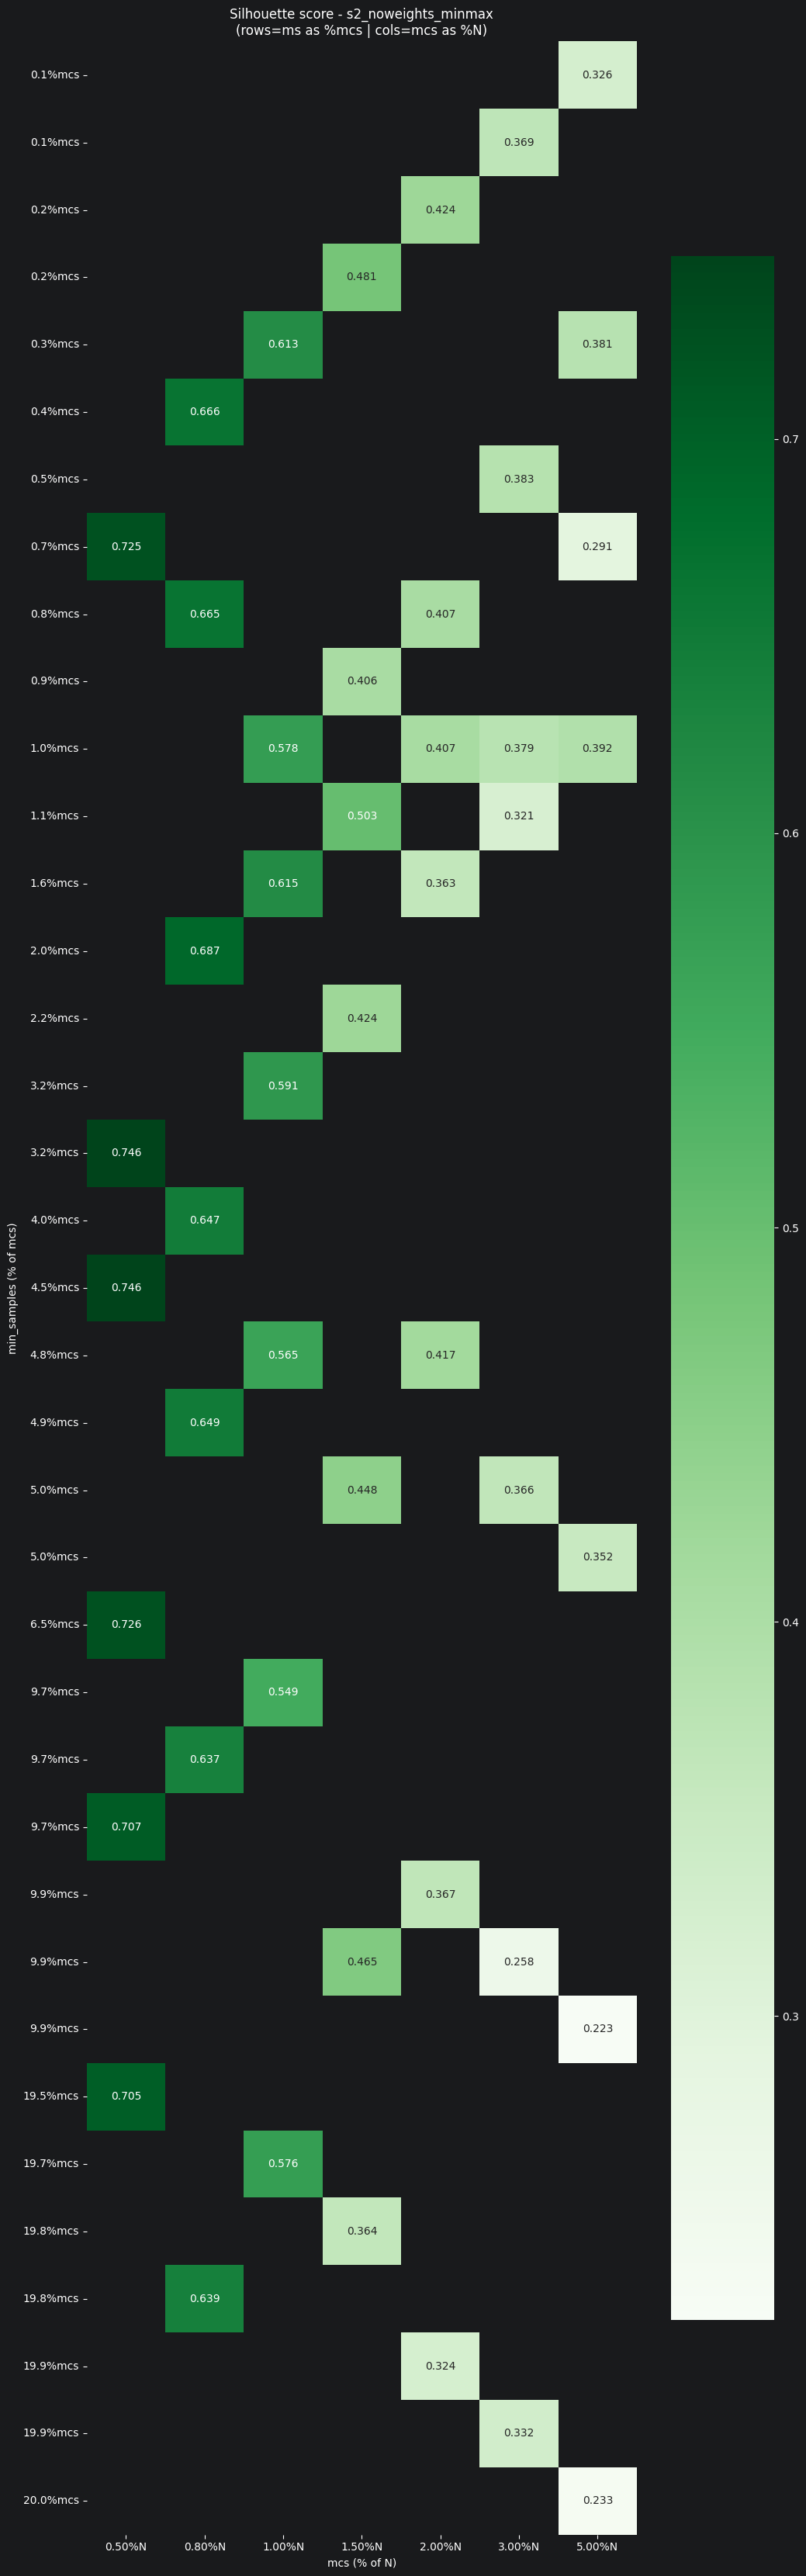

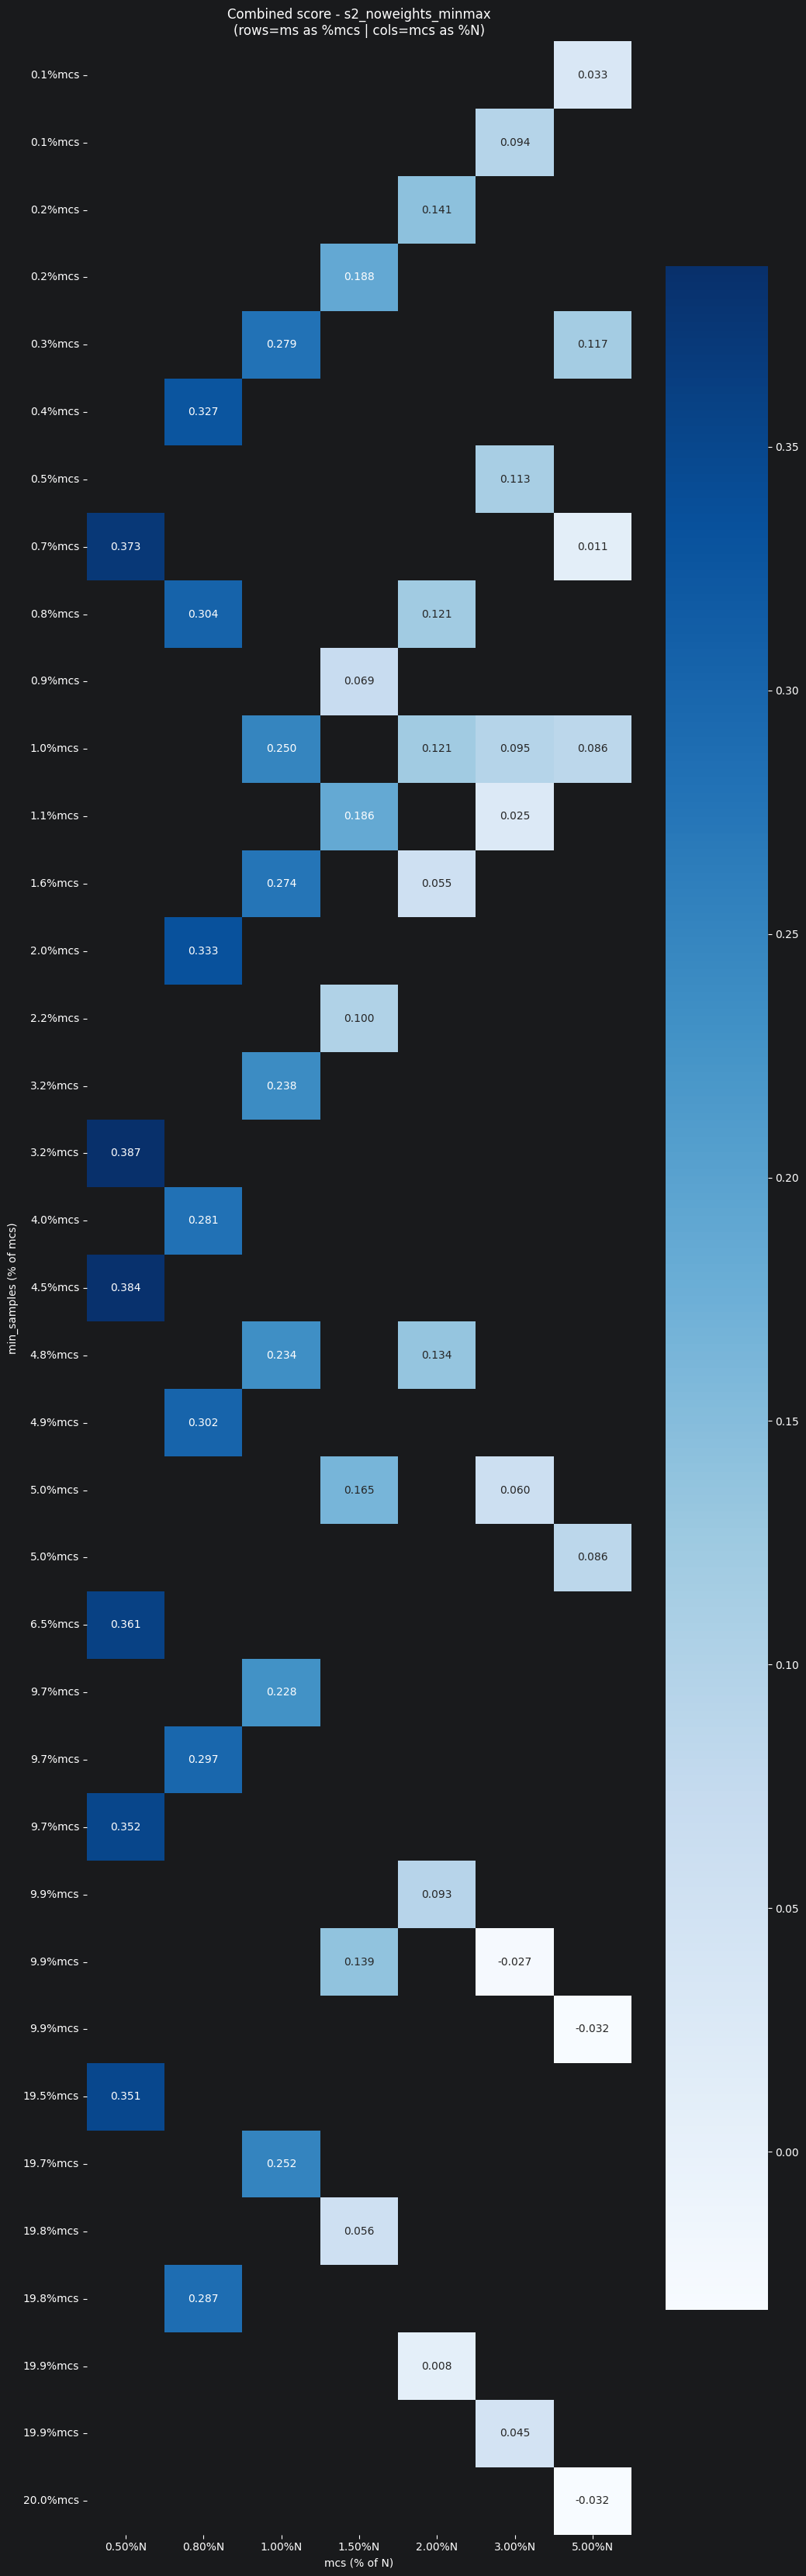

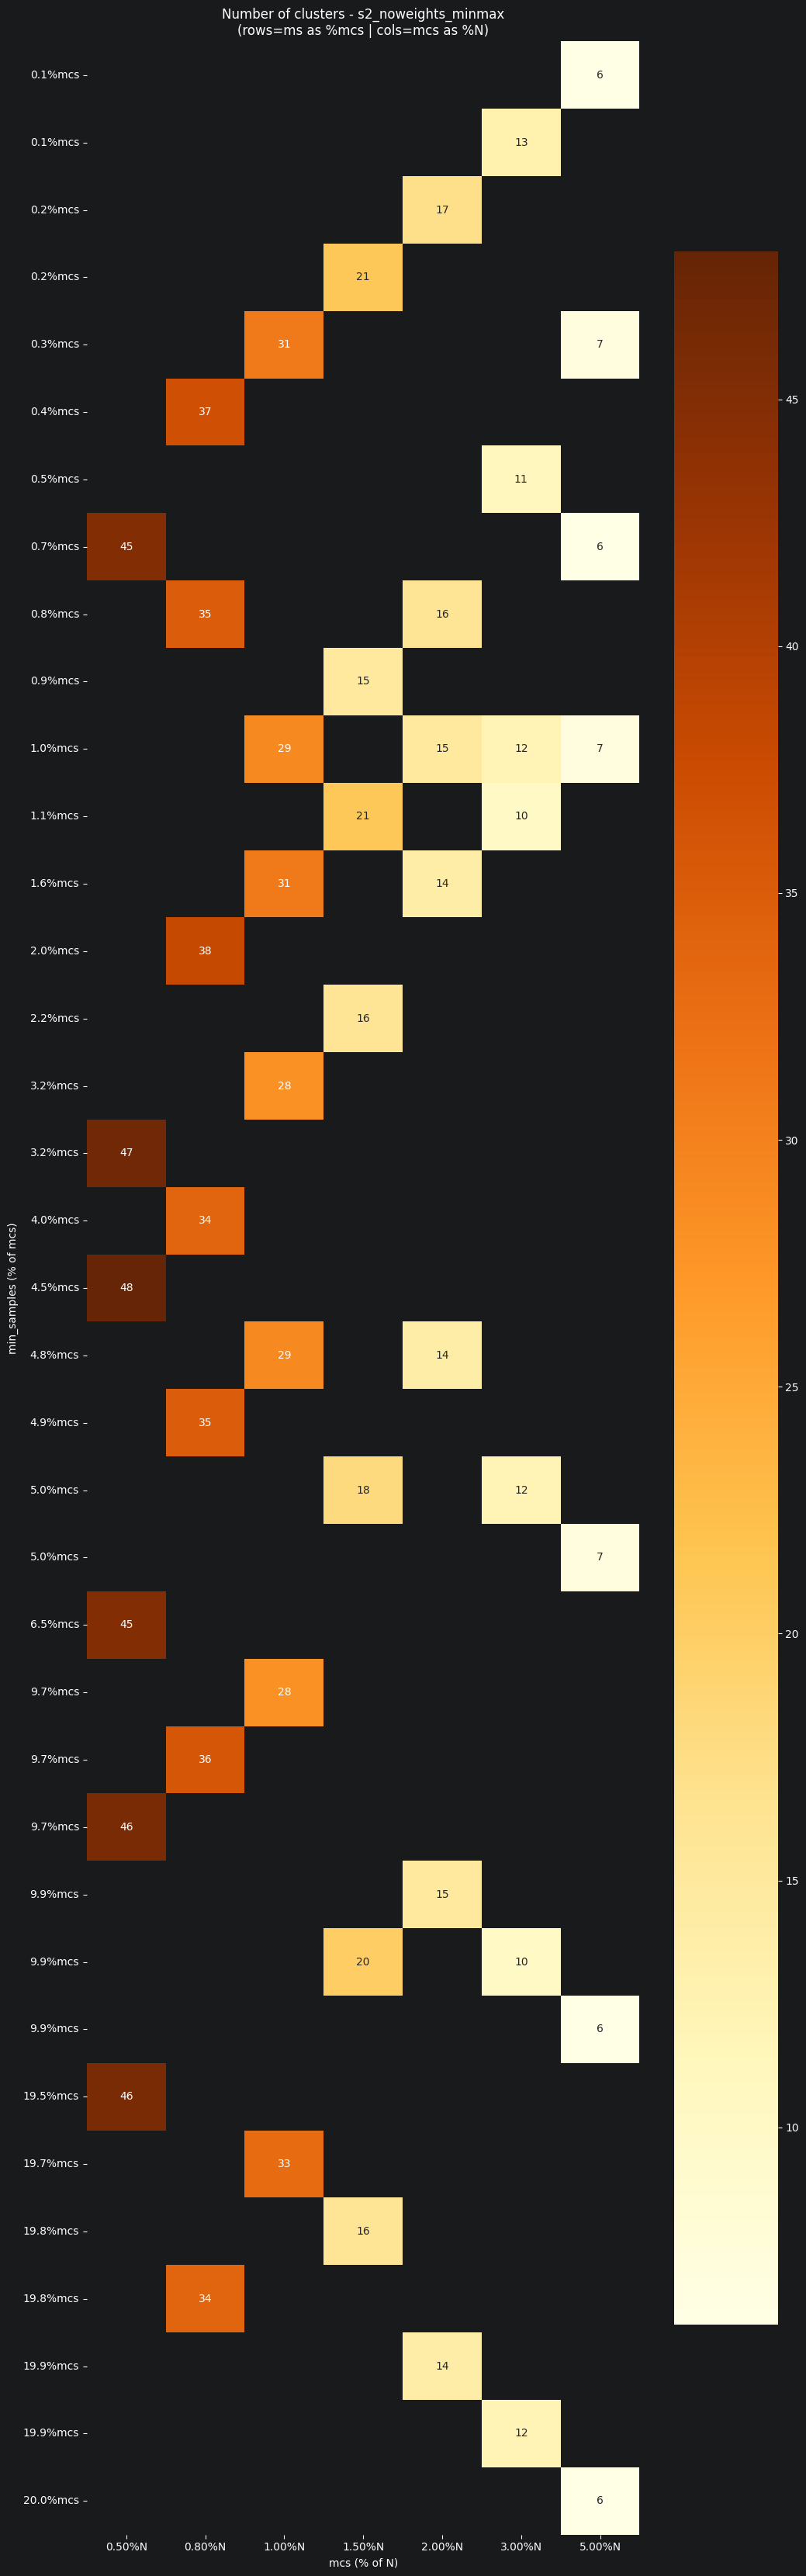

INFO | [s2_hosp3x] n=30940 | binary=11 | cat=0 | quanti=2



=== TOP 10 lowest outlier rate [s2_noweights_minmax] ===
 mcs  mcs_pct_N  ms  ms_pct_mcs  n_clusters  outlier_pct  silhouette  stability  combined_score
1547        5.0   5        0.32           7          1.2      0.3810        1.0          0.1171
 464        1.5  23        4.96          18          2.4      0.4478        1.0          0.1648
 464        1.5   1        0.22          21          2.9      0.4809        1.0          0.1883
 928        3.0   5        0.54          11          3.0      0.3826        1.0          0.1131
 154        0.5   1        0.65          45          3.7      0.7252        1.0          0.3727
 247        0.8   1        0.40          37          3.8      0.6659        1.0          0.3270
 618        2.0   1        0.16          17          4.1      0.4240        1.0          0.1414
 154        0.5   5        3.25          47          4.3      0.7463        1.0          0.3870
1547        5.0  77        4.98           7          4.4      0.3524        1.

INFO | [s2_hosp3x] Distance matrix: 25.2s
INFO | [s2_hosp3x] HDBSCAN: 78.2s
INFO | [s2_hosp3x] clusters=21 | noise=2399 (7.8%)



 Grid: 48 combinations for N=30,940
   mcs range: 154 - 1,547
   ms  range: fixed [1, 5, 10] + ['1%mcs', '5%mcs', '10%mcs', '20%mcs']


INFO | [s2_hosp3x_minmax] mcs=  154 (0.50%N) | ms=   1 (0.7%mcs) | clusters=47 | outliers=4.6% | sil=0.726
INFO | [s2_hosp3x_minmax] mcs=  154 (0.50%N) | ms=   5 (3.2%mcs) | clusters=42 | outliers=8.7% | sil=0.717
INFO | [s2_hosp3x_minmax] mcs=  154 (0.50%N) | ms=   7 (4.5%mcs) | clusters=46 | outliers=5.4% | sil=0.727
INFO | [s2_hosp3x_minmax] mcs=  154 (0.50%N) | ms=  10 (6.5%mcs) | clusters=51 | outliers=1.9% | sil=0.738
INFO | [s2_hosp3x_minmax] mcs=  154 (0.50%N) | ms=  15 (9.7%mcs) | clusters=47 | outliers=2.1% | sil=0.725
INFO | [s2_hosp3x_minmax] mcs=  154 (0.50%N) | ms=  30 (19.5%mcs) | clusters=46 | outliers=3.2% | sil=0.697
INFO | [s2_hosp3x_minmax] mcs=  247 (0.80%N) | ms=   1 (0.4%mcs) | clusters=37 | outliers=5.2% | sil=0.655
INFO | [s2_hosp3x_minmax] mcs=  247 (0.80%N) | ms=   2 (0.8%mcs) | clusters=37 | outliers=6.4% | sil=0.663
INFO | [s2_hosp3x_minmax] mcs=  247 (0.80%N) | ms=   5 (2.0%mcs) | clusters=32 | outliers=9.7% | sil=0.648
INFO | [s2_hosp3x_minmax] mcs=  247 

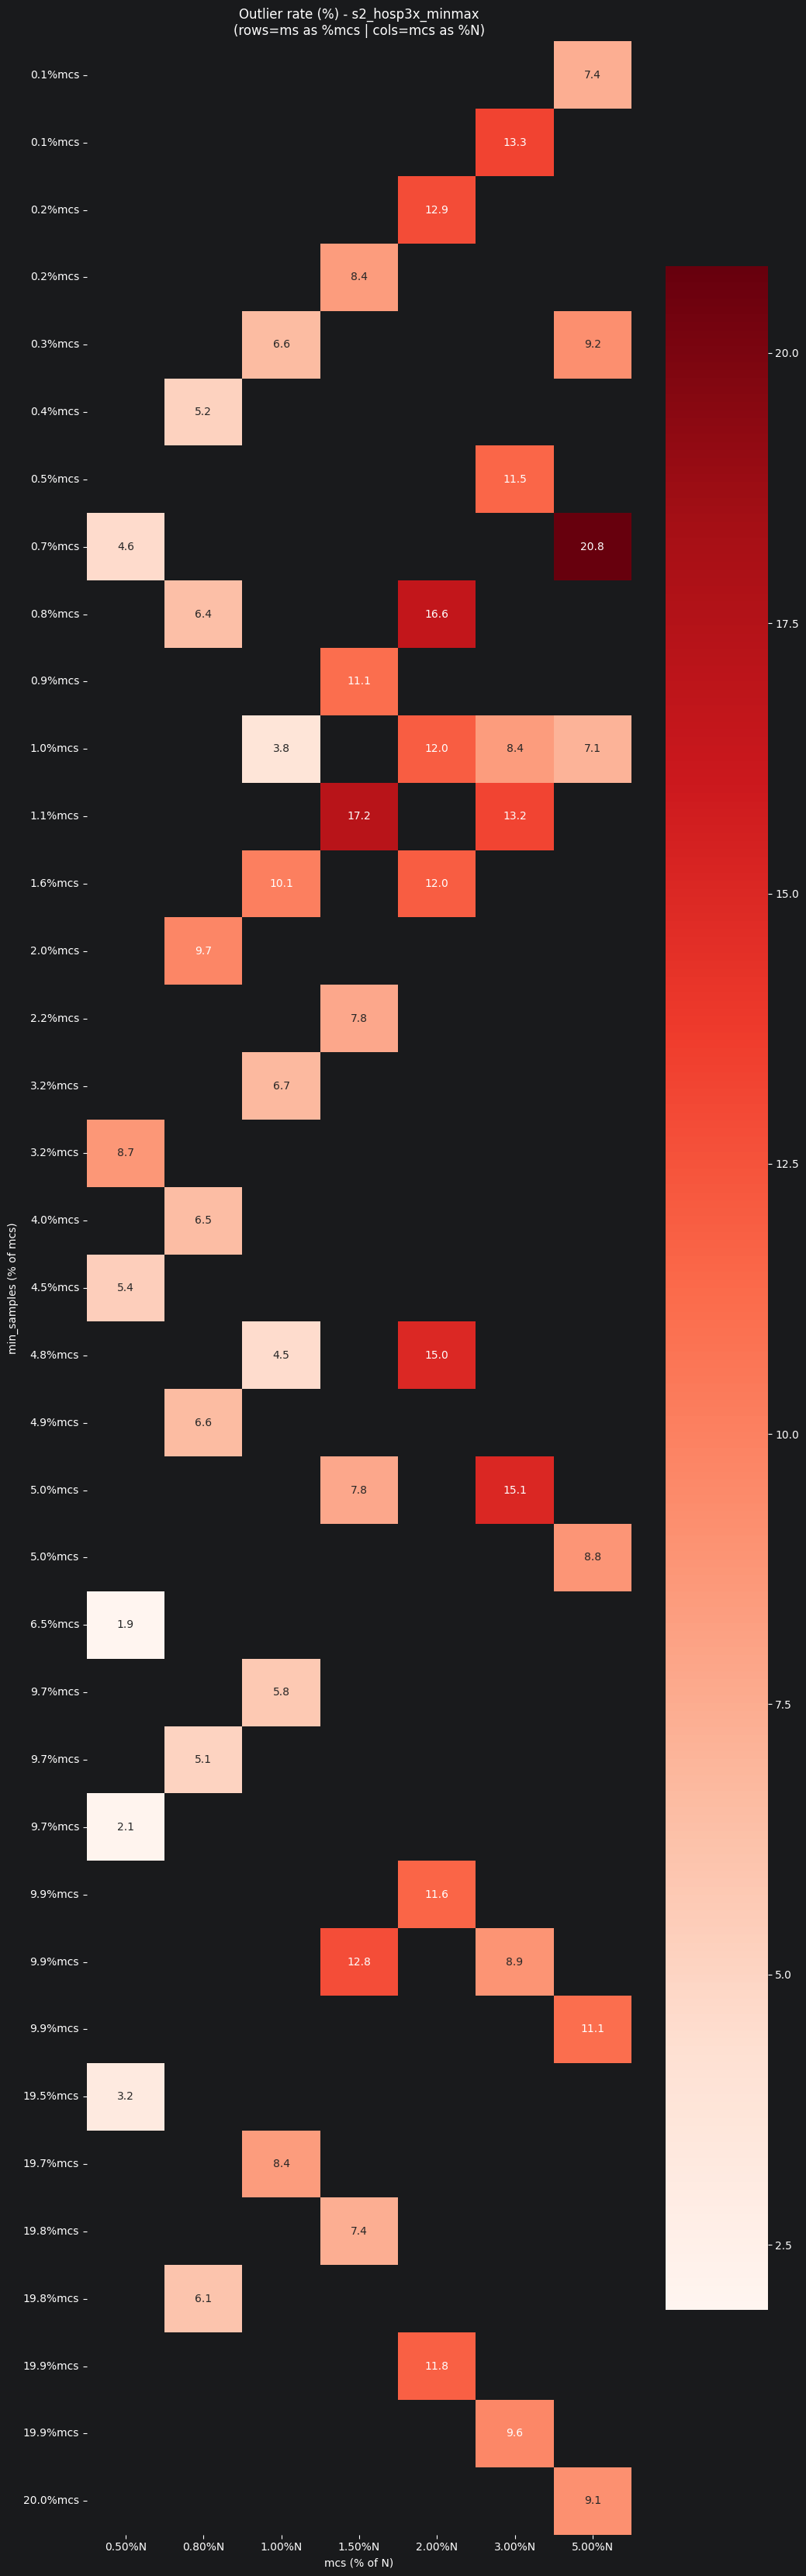

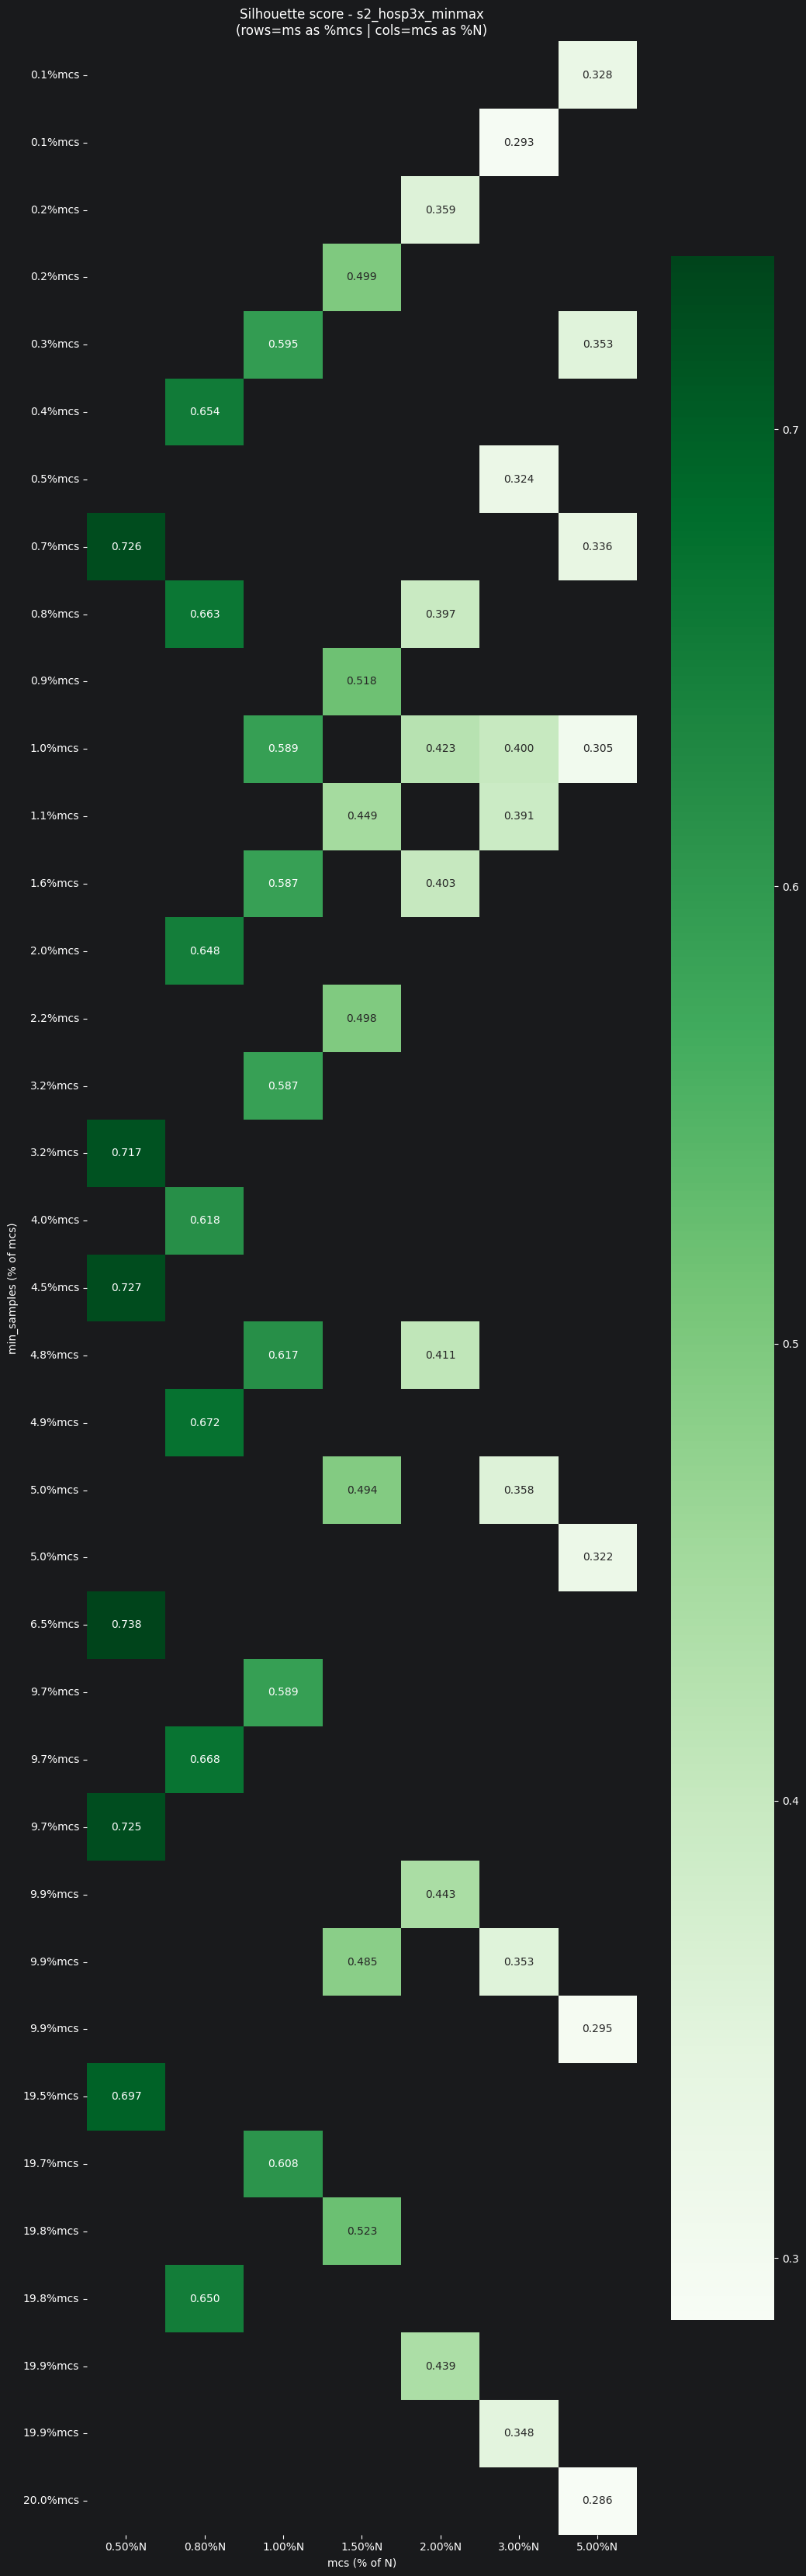

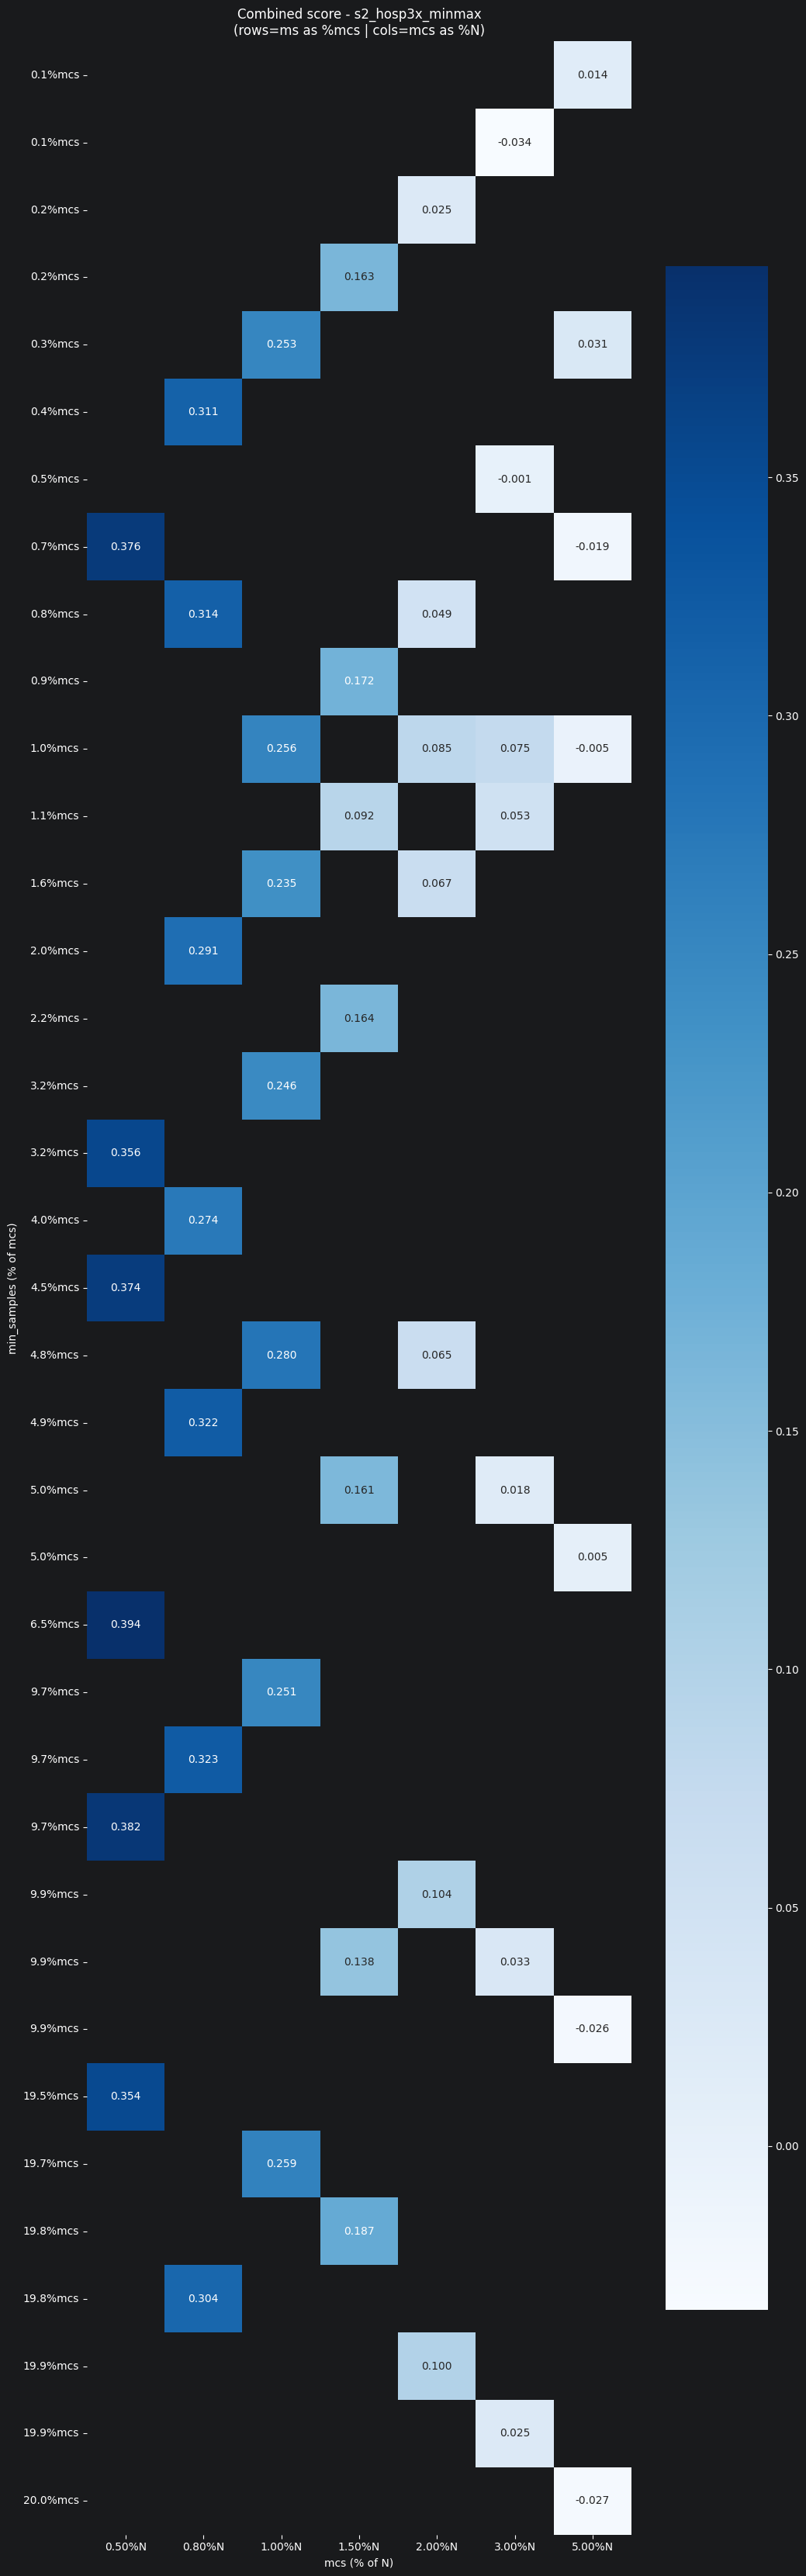

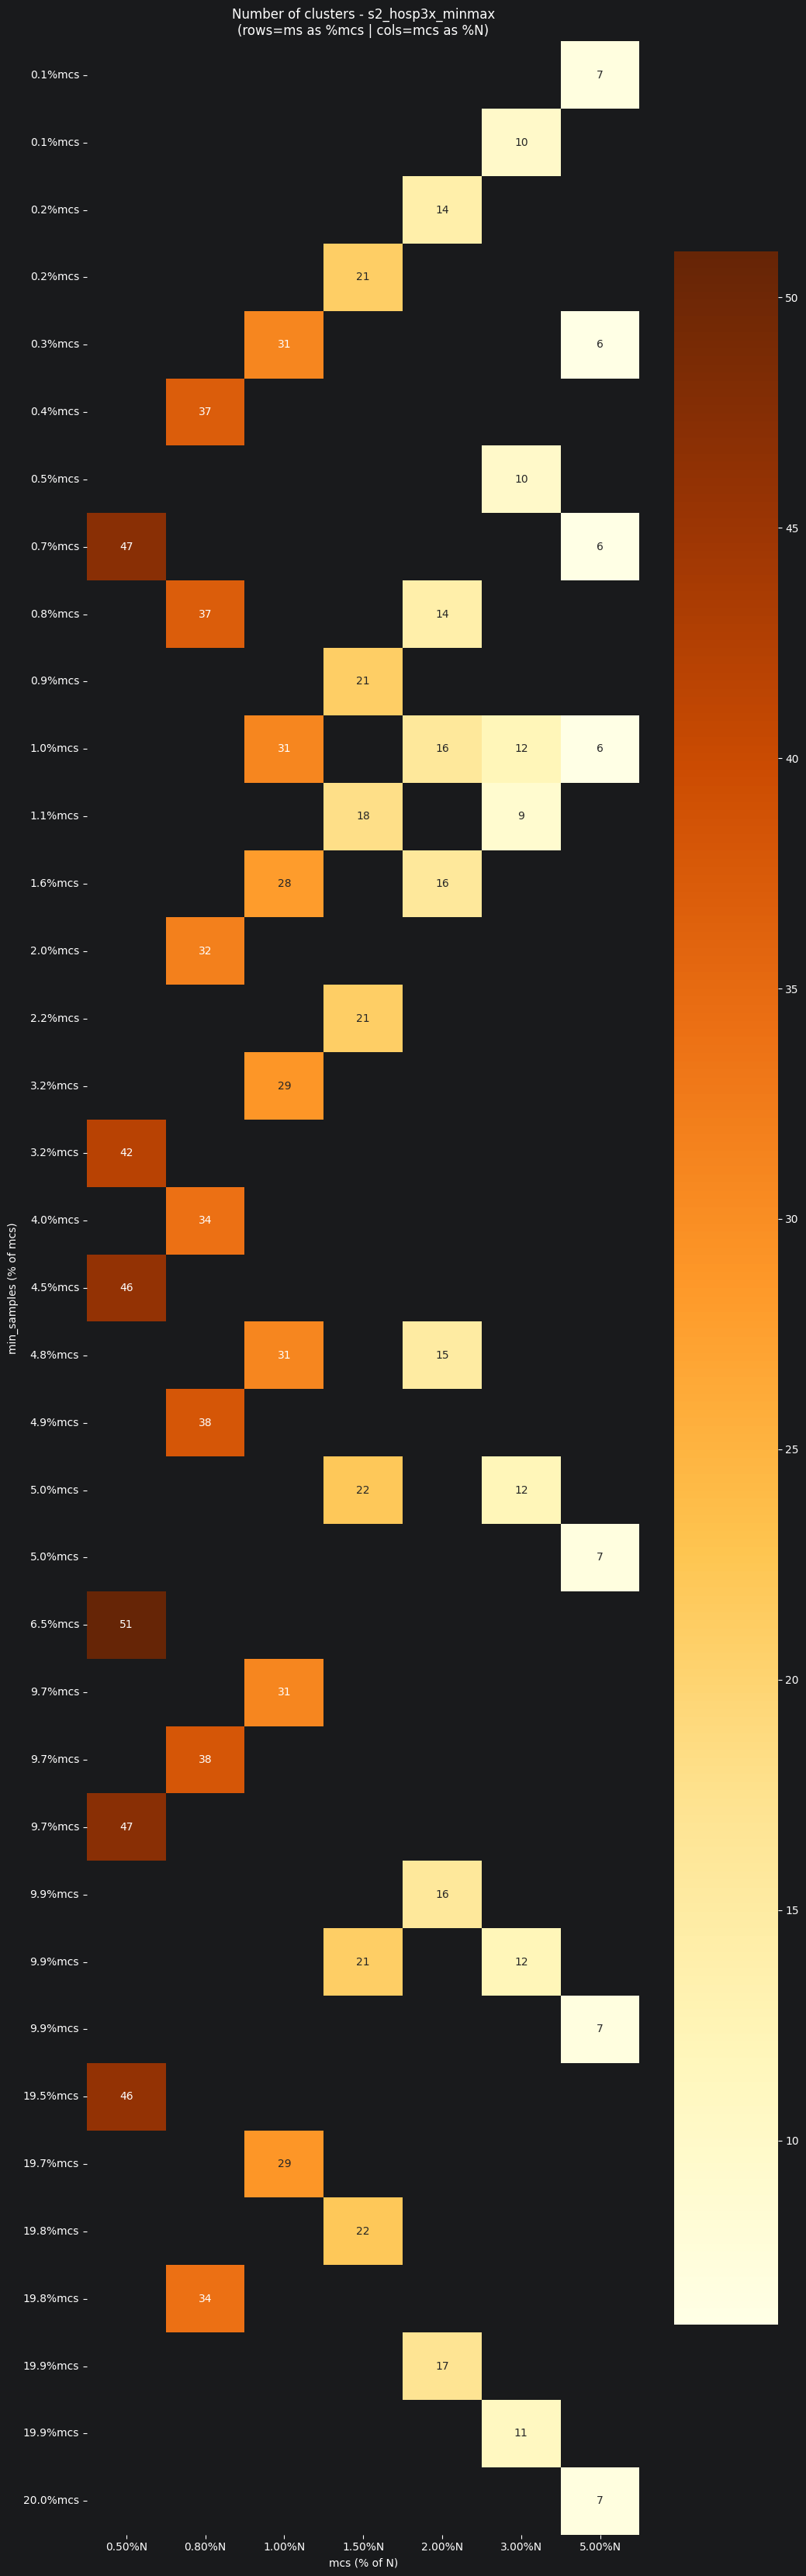

INFO | [s2_noweights] n=30940 | binary=11 | cat=0 | quanti=2



=== TOP 10 lowest outlier rate [s2_hosp3x_minmax] ===
 mcs  mcs_pct_N  ms  ms_pct_mcs  n_clusters  outlier_pct  silhouette  stability  combined_score
 154        0.5  10        6.49          51          1.9      0.7378        1.0          0.3942
 154        0.5  15        9.74          47          2.1      0.7249        1.0          0.3822
 154        0.5  30       19.48          46          3.2      0.6966        1.0          0.3539
 309        1.0   3        0.97          31          3.8      0.5885        1.0          0.2562
 309        1.0  15        4.85          31          4.5      0.6172        1.0          0.2796
 154        0.5   1        0.65          47          4.6      0.7260        1.0          0.3759
 247        0.8  24        9.72          38          5.1      0.6680        1.0          0.3228
 247        0.8   1        0.40          37          5.2      0.6545        1.0          0.3107
 154        0.5   7        4.55          46          5.4      0.7269        1.0  

INFO | [s2_noweights] Distance matrix: 25.3s
INFO | [s2_noweights] HDBSCAN: 75.8s
INFO | [s2_noweights] clusters=22 | noise=907 (2.9%)



 Grid: 48 combinations for N=30,940
   mcs range: 154 - 1,547
   ms  range: fixed [1, 5, 10] + ['1%mcs', '5%mcs', '10%mcs', '20%mcs']


INFO | [s2_noweights_standard] mcs=  154 (0.50%N) | ms=   1 (0.7%mcs) | clusters=49 | outliers=2.3% | sil=0.765
INFO | [s2_noweights_standard] mcs=  154 (0.50%N) | ms=   5 (3.2%mcs) | clusters=47 | outliers=3.9% | sil=0.771
INFO | [s2_noweights_standard] mcs=  154 (0.50%N) | ms=   7 (4.5%mcs) | clusters=46 | outliers=4.0% | sil=0.771
INFO | [s2_noweights_standard] mcs=  154 (0.50%N) | ms=  10 (6.5%mcs) | clusters=47 | outliers=2.4% | sil=0.774
INFO | [s2_noweights_standard] mcs=  154 (0.50%N) | ms=  15 (9.7%mcs) | clusters=46 | outliers=4.0% | sil=0.741
INFO | [s2_noweights_standard] mcs=  154 (0.50%N) | ms=  30 (19.5%mcs) | clusters=47 | outliers=5.6% | sil=0.763
INFO | [s2_noweights_standard] mcs=  247 (0.80%N) | ms=   1 (0.4%mcs) | clusters=39 | outliers=3.5% | sil=0.710
INFO | [s2_noweights_standard] mcs=  247 (0.80%N) | ms=   2 (0.8%mcs) | clusters=36 | outliers=7.3% | sil=0.715
INFO | [s2_noweights_standard] mcs=  247 (0.80%N) | ms=   5 (2.0%mcs) | clusters=37 | outliers=5.1% | s

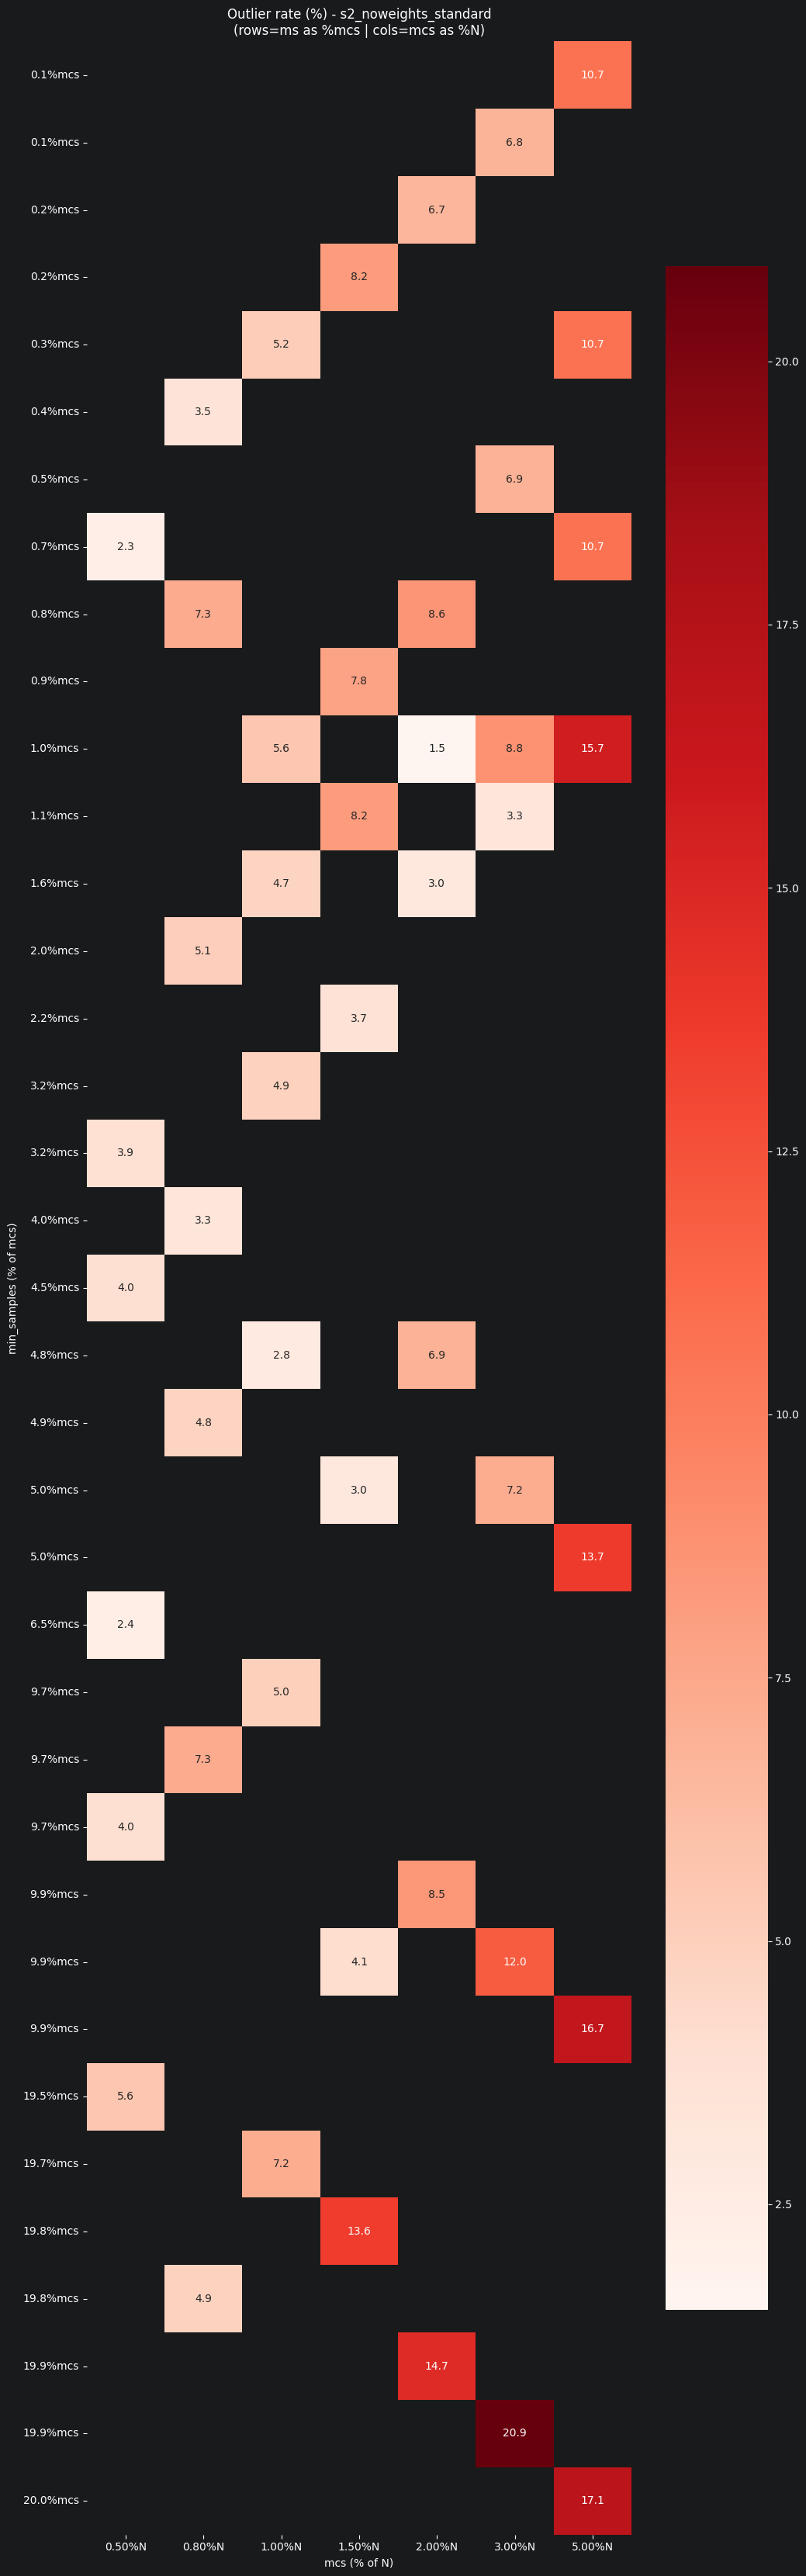

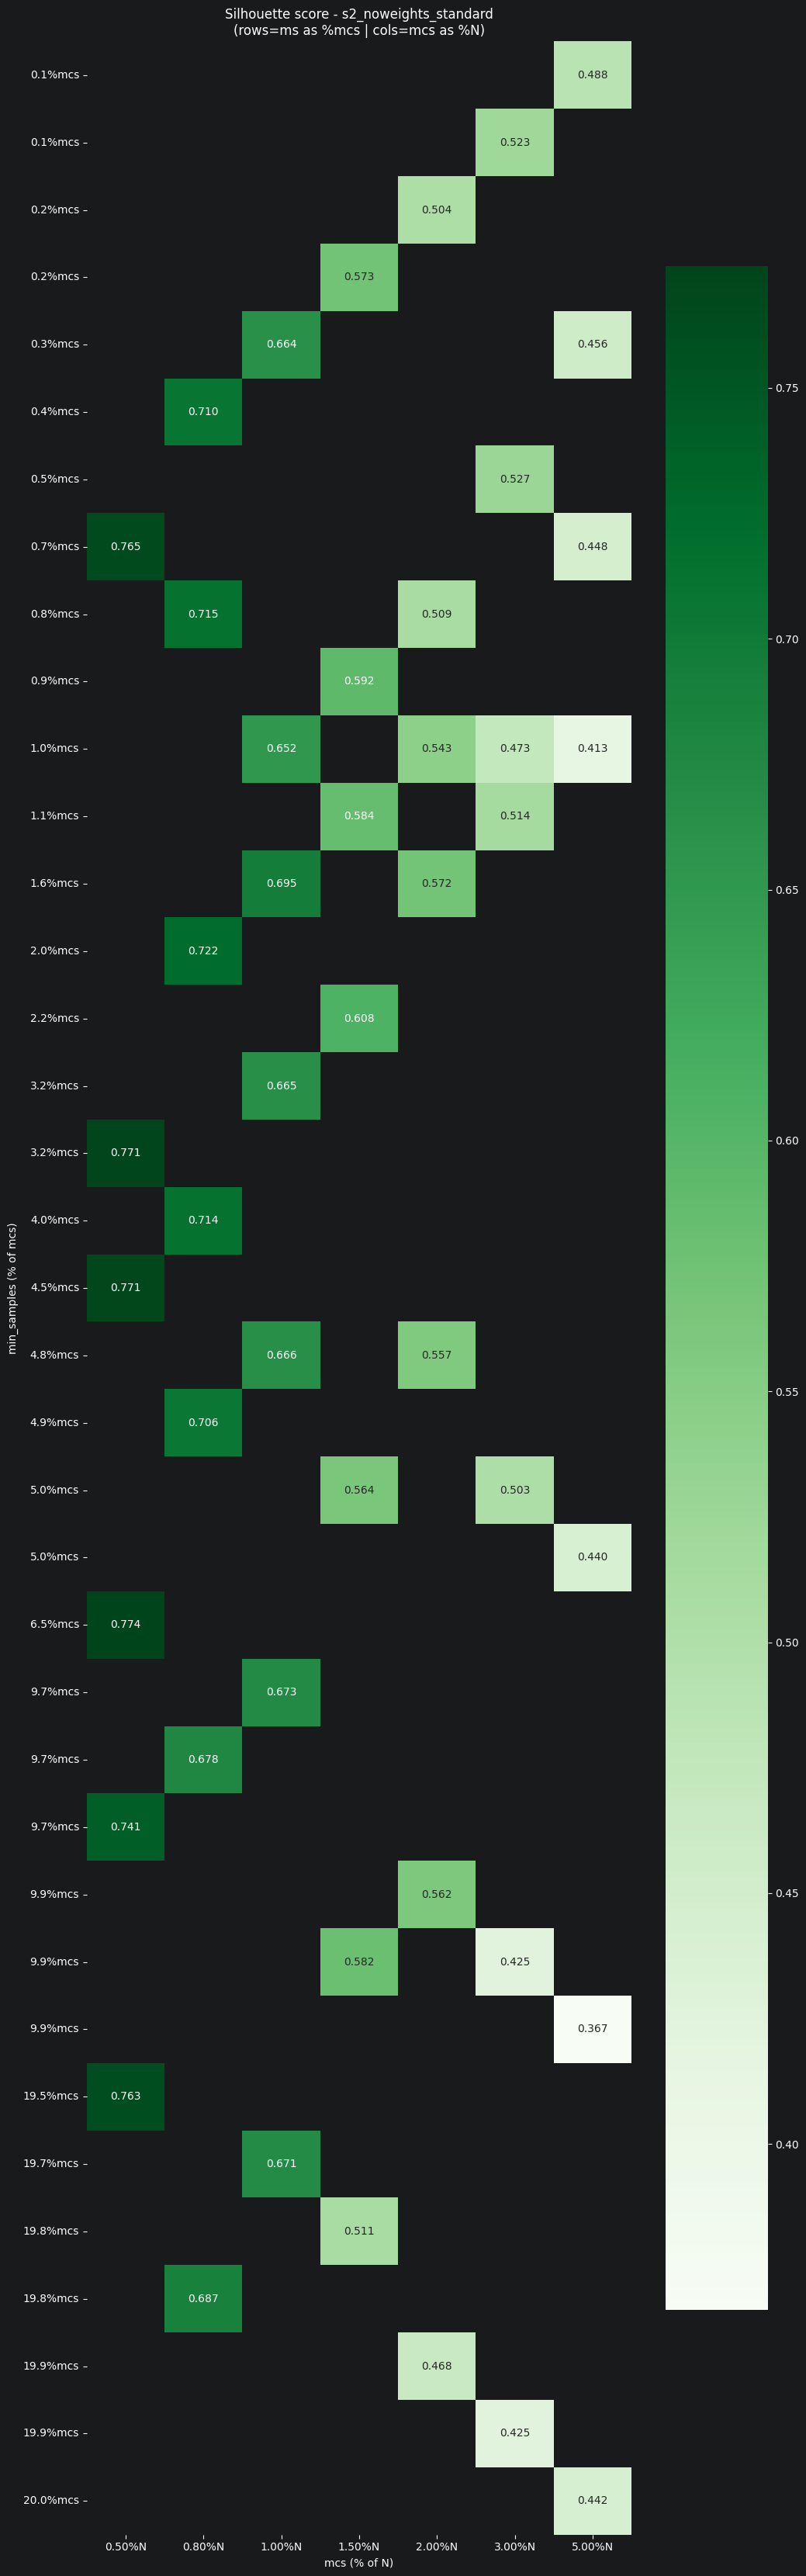

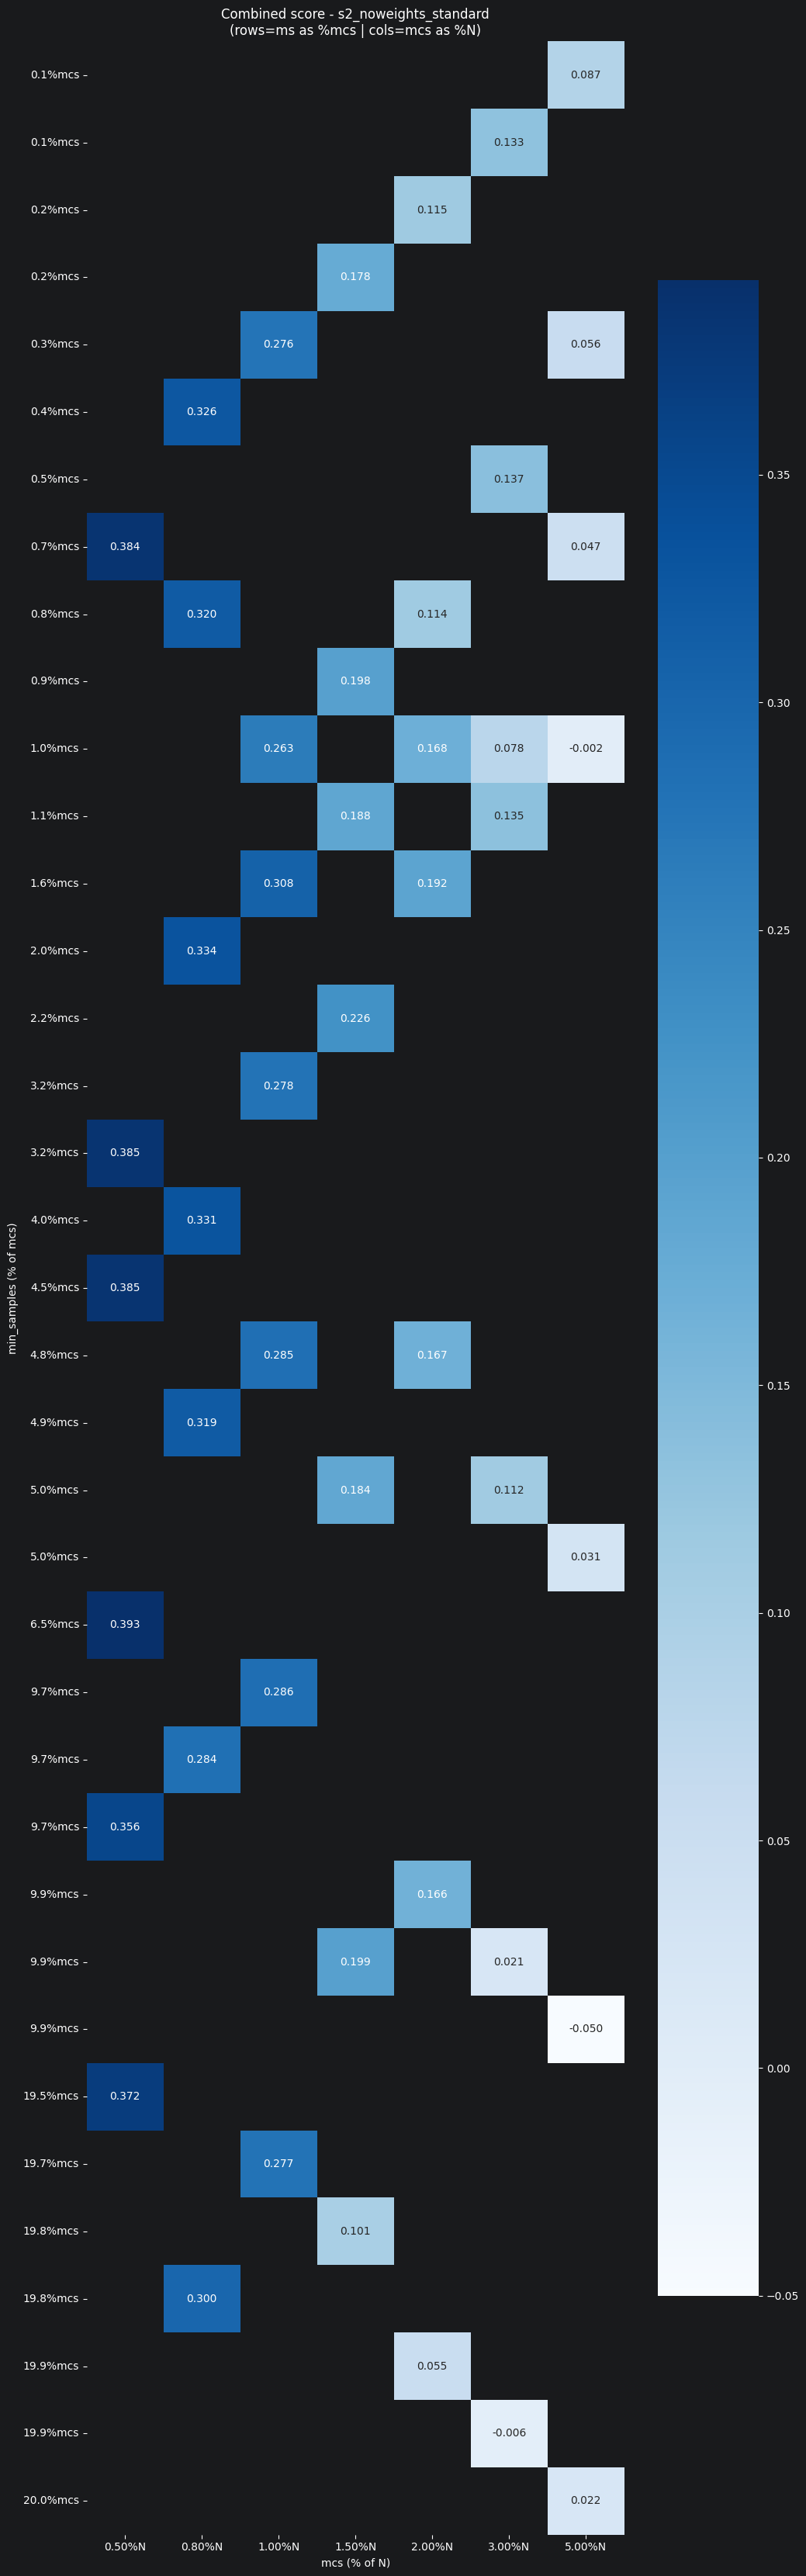

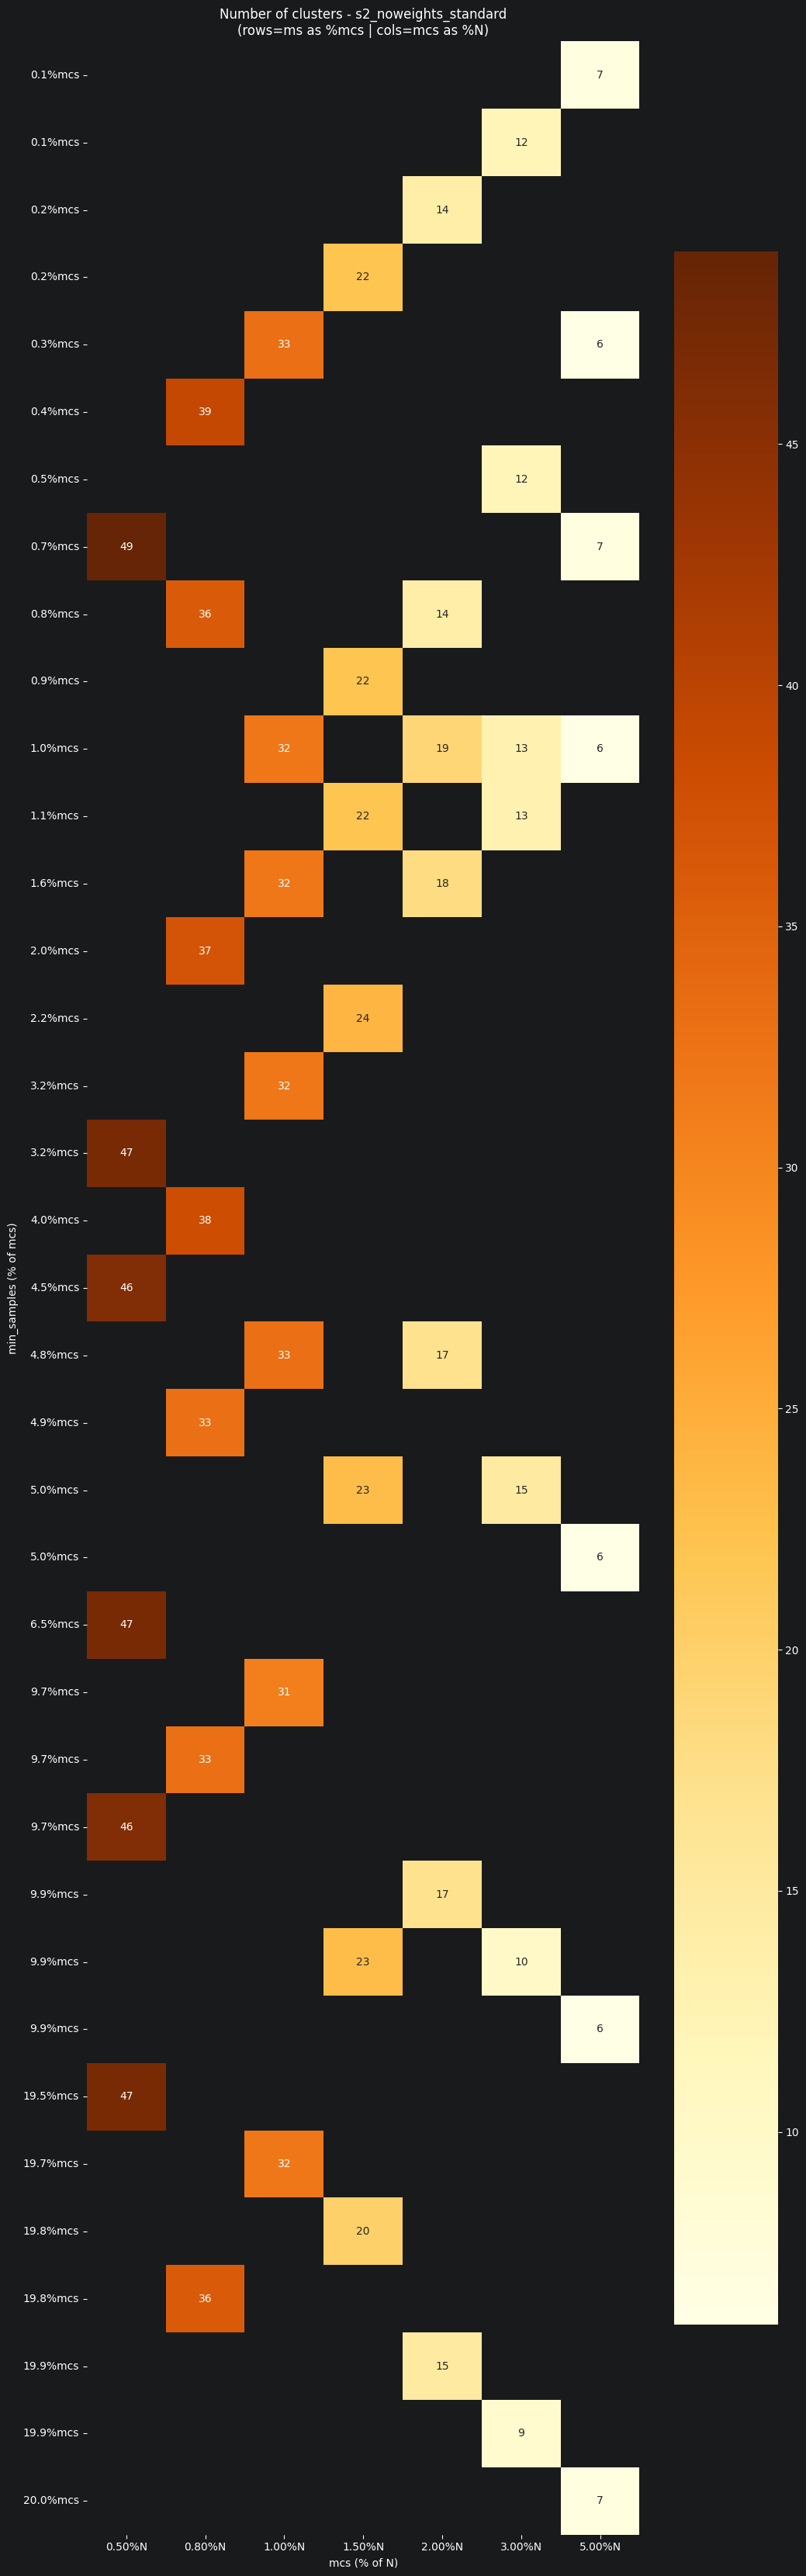

INFO | [s2_hosp3x] n=30940 | binary=11 | cat=0 | quanti=2



=== TOP 10 lowest outlier rate [s2_noweights_standard] ===
 mcs  mcs_pct_N  ms  ms_pct_mcs  n_clusters  outlier_pct  silhouette  stability  combined_score
 618        2.0   6        0.97          19          1.5      0.5429        1.0          0.1683
 154        0.5   1        0.65          49          2.3      0.7652        1.0          0.3843
 154        0.5  10        6.49          47          2.4      0.7742        1.0          0.3928
 309        1.0  15        4.85          33          2.8      0.6656        1.0          0.2848
 618        2.0  10        1.62          18          3.0      0.5716        1.0          0.1920
 464        1.5  23        4.96          23          3.0      0.5641        1.0          0.1845
 247        0.8  10        4.05          38          3.3      0.7142        1.0          0.3313
 928        3.0  10        1.08          13          3.3      0.5140        1.0          0.1345
 247        0.8   1        0.40          39          3.5      0.7097        

INFO | [s2_hosp3x] Distance matrix: 25.5s
INFO | [s2_hosp3x] HDBSCAN: 76.5s
INFO | [s2_hosp3x] clusters=23 | noise=1400 (4.5%)



 Grid: 48 combinations for N=30,940
   mcs range: 154 - 1,547
   ms  range: fixed [1, 5, 10] + ['1%mcs', '5%mcs', '10%mcs', '20%mcs']


INFO | [s2_hosp3x_standard] mcs=  154 (0.50%N) | ms=   1 (0.7%mcs) | clusters=45 | outliers=3.8% | sil=0.778
INFO | [s2_hosp3x_standard] mcs=  154 (0.50%N) | ms=   5 (3.2%mcs) | clusters=48 | outliers=3.1% | sil=0.791
INFO | [s2_hosp3x_standard] mcs=  154 (0.50%N) | ms=   7 (4.5%mcs) | clusters=46 | outliers=2.6% | sil=0.791
INFO | [s2_hosp3x_standard] mcs=  154 (0.50%N) | ms=  10 (6.5%mcs) | clusters=47 | outliers=4.2% | sil=0.773
INFO | [s2_hosp3x_standard] mcs=  154 (0.50%N) | ms=  15 (9.7%mcs) | clusters=49 | outliers=3.8% | sil=0.799
INFO | [s2_hosp3x_standard] mcs=  154 (0.50%N) | ms=  30 (19.5%mcs) | clusters=46 | outliers=4.9% | sil=0.779
INFO | [s2_hosp3x_standard] mcs=  247 (0.80%N) | ms=   1 (0.4%mcs) | clusters=37 | outliers=6.0% | sil=0.728
INFO | [s2_hosp3x_standard] mcs=  247 (0.80%N) | ms=   2 (0.8%mcs) | clusters=33 | outliers=5.0% | sil=0.722
INFO | [s2_hosp3x_standard] mcs=  247 (0.80%N) | ms=   5 (2.0%mcs) | clusters=37 | outliers=2.3% | sil=0.732
INFO | [s2_hosp3x_

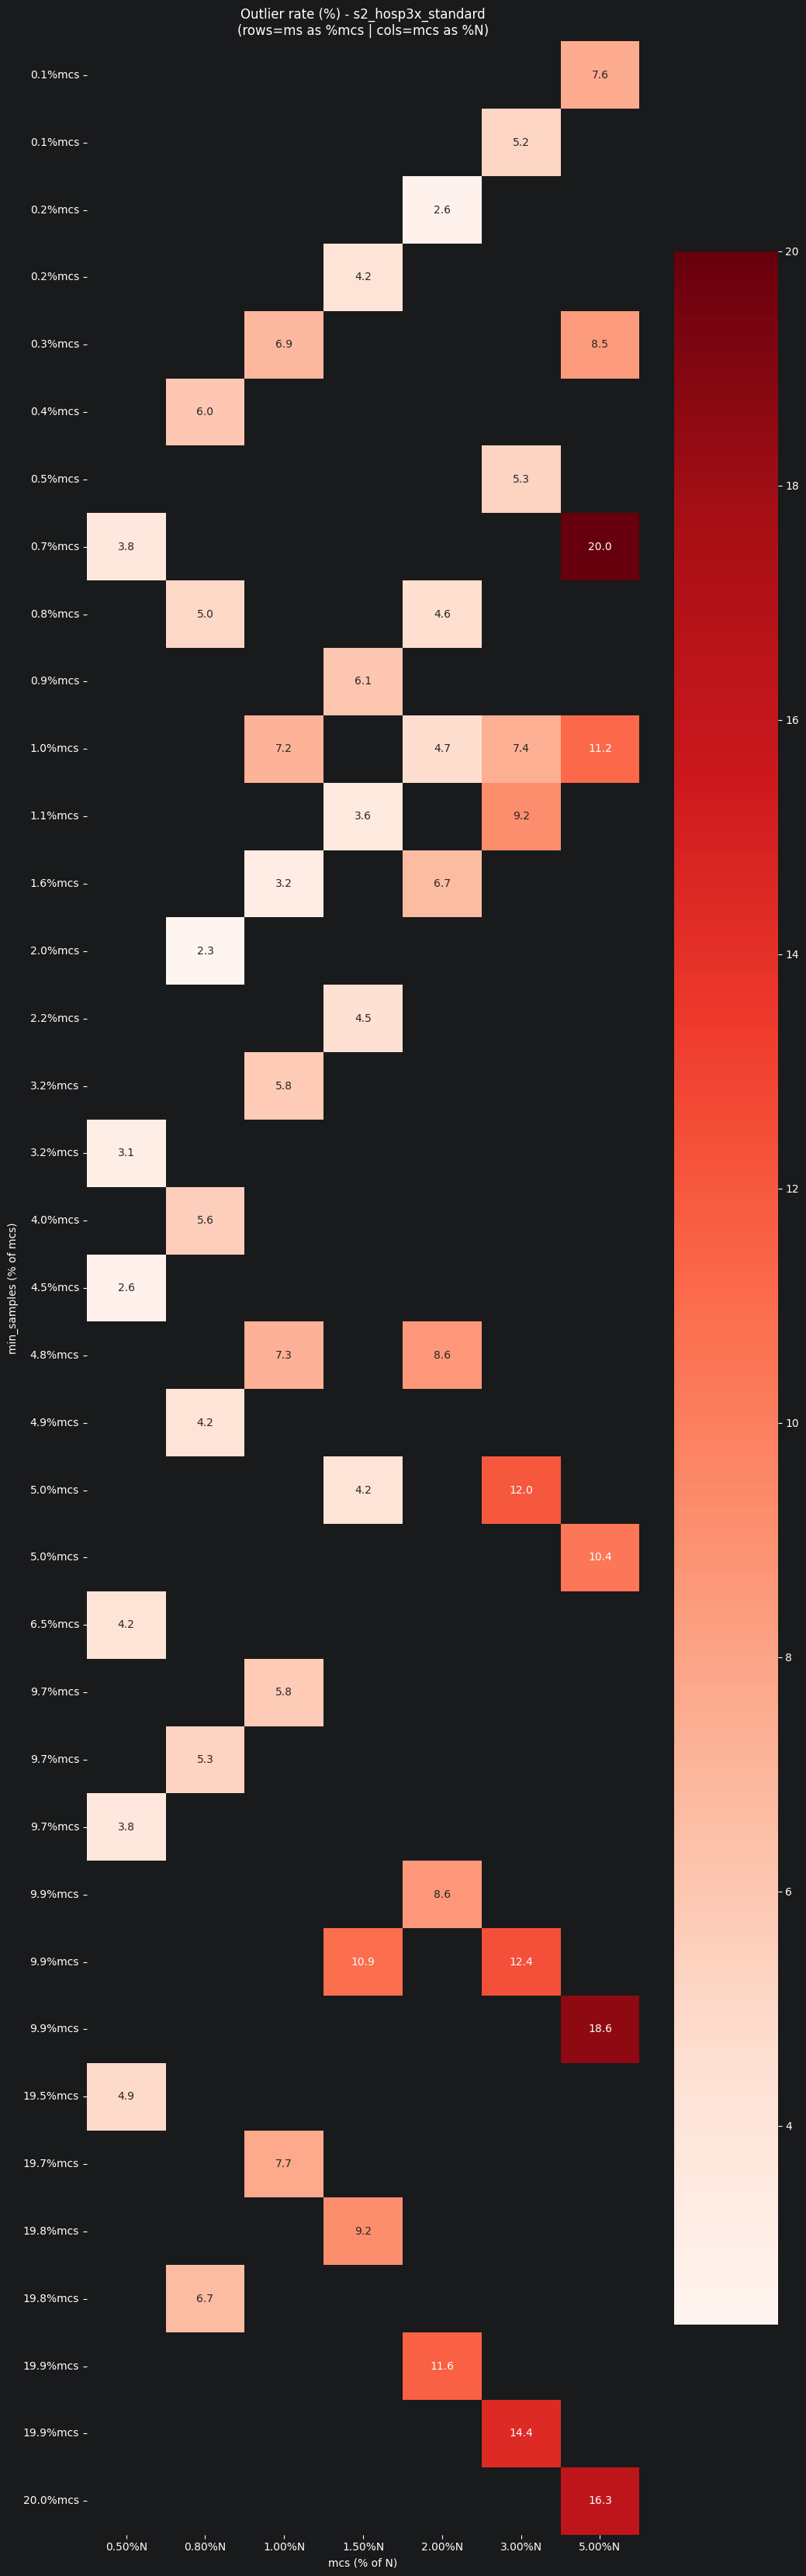

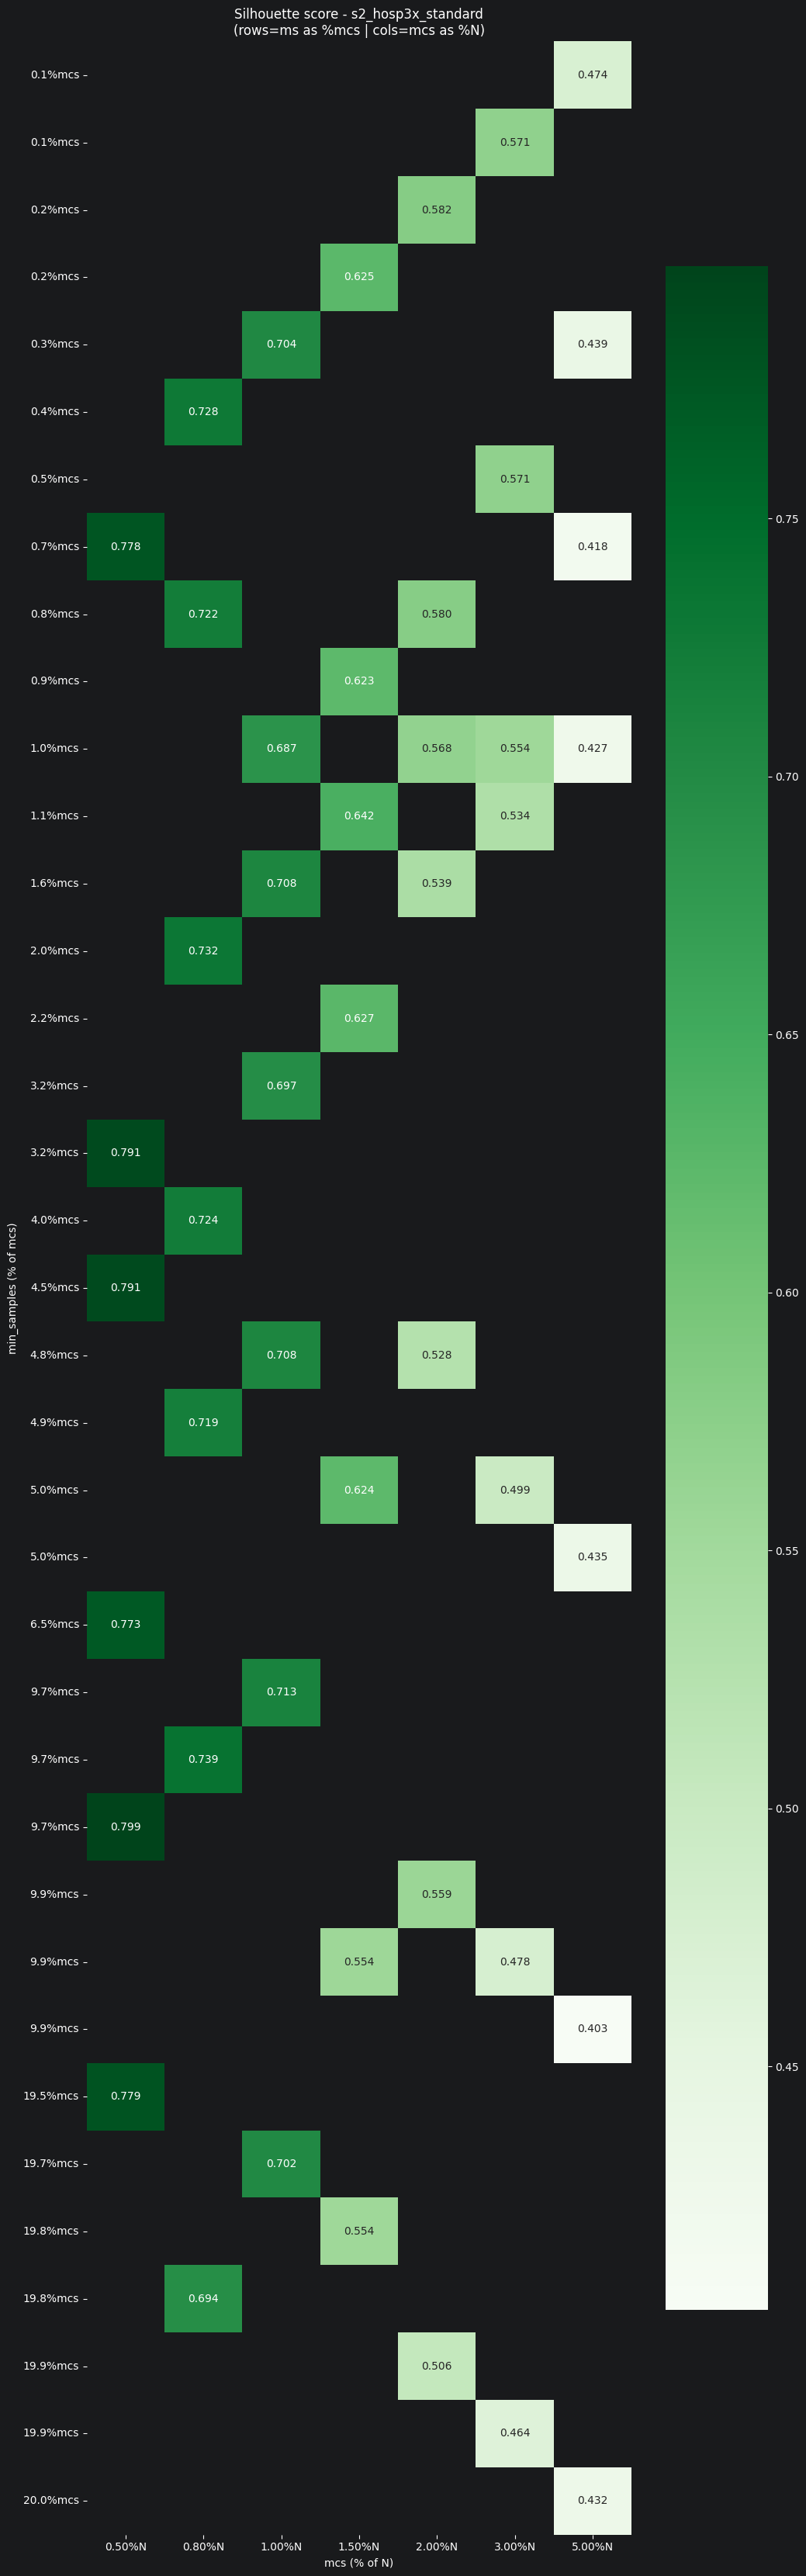

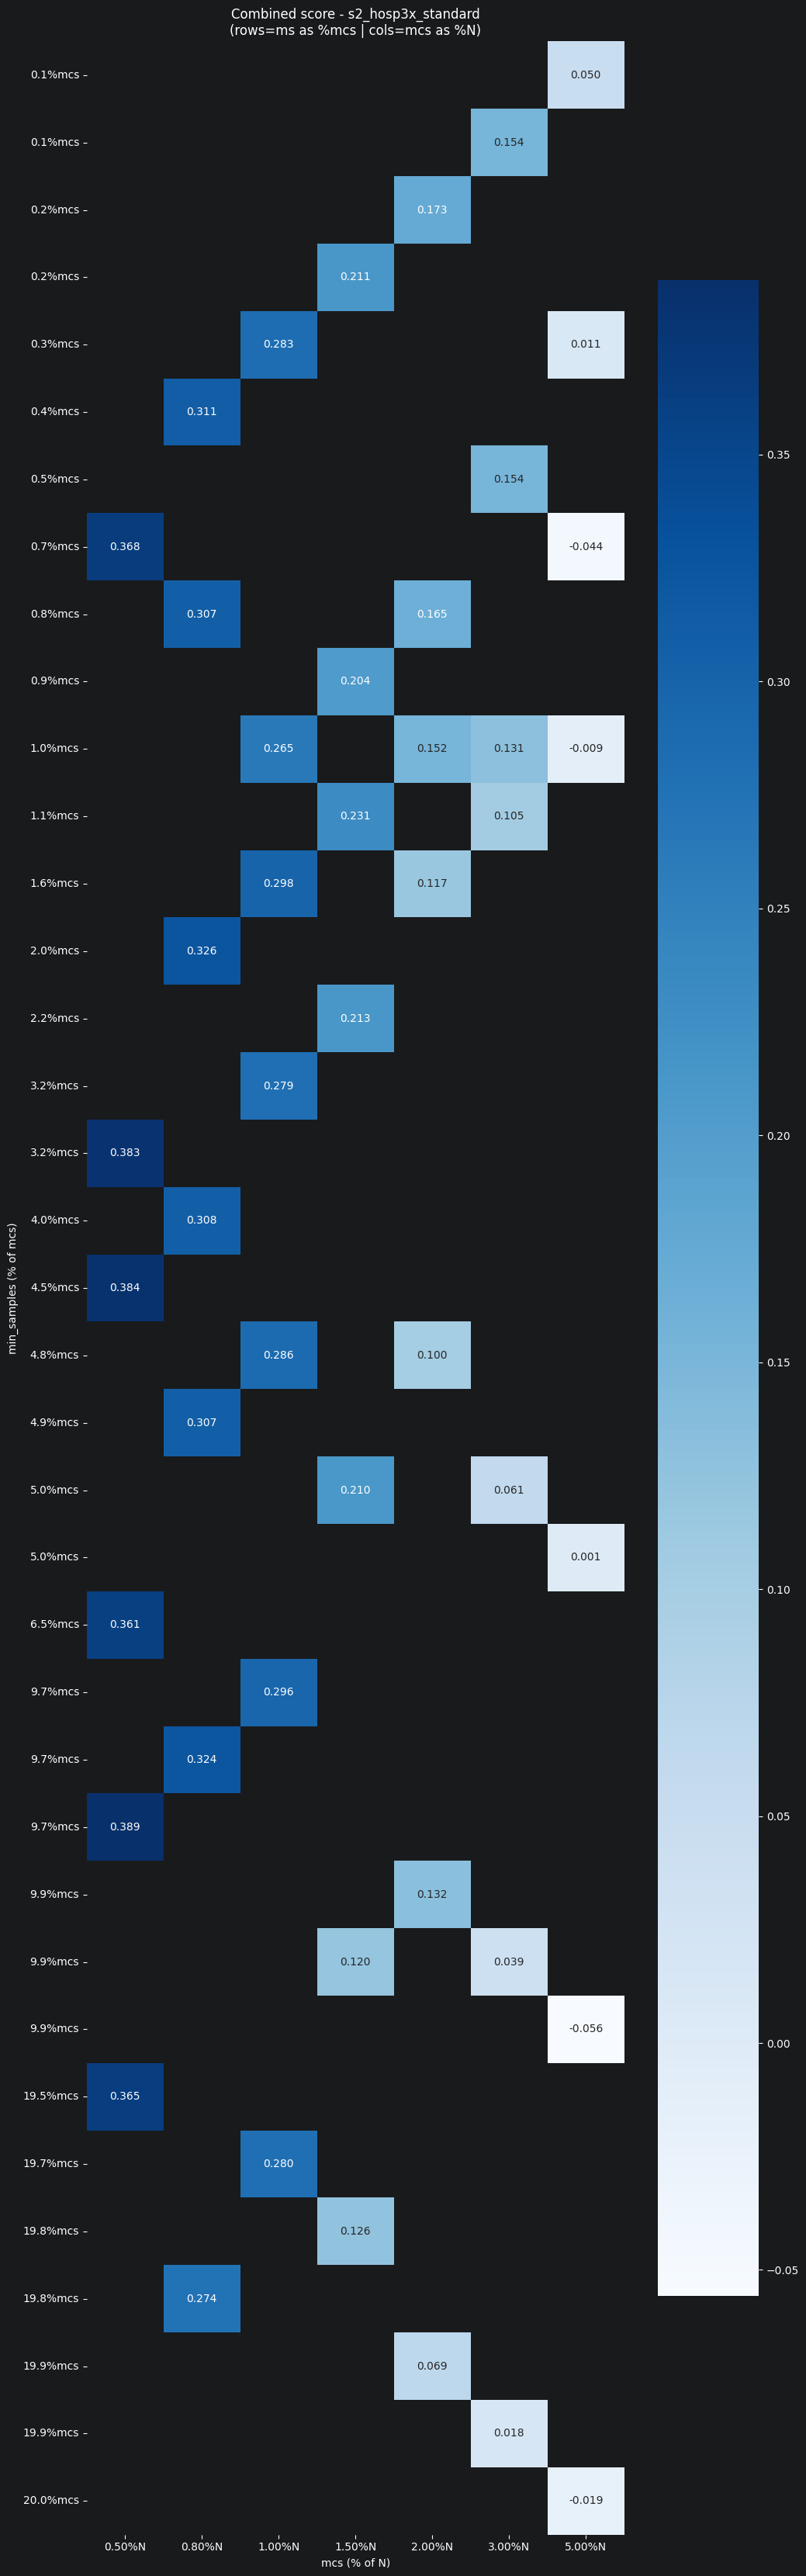

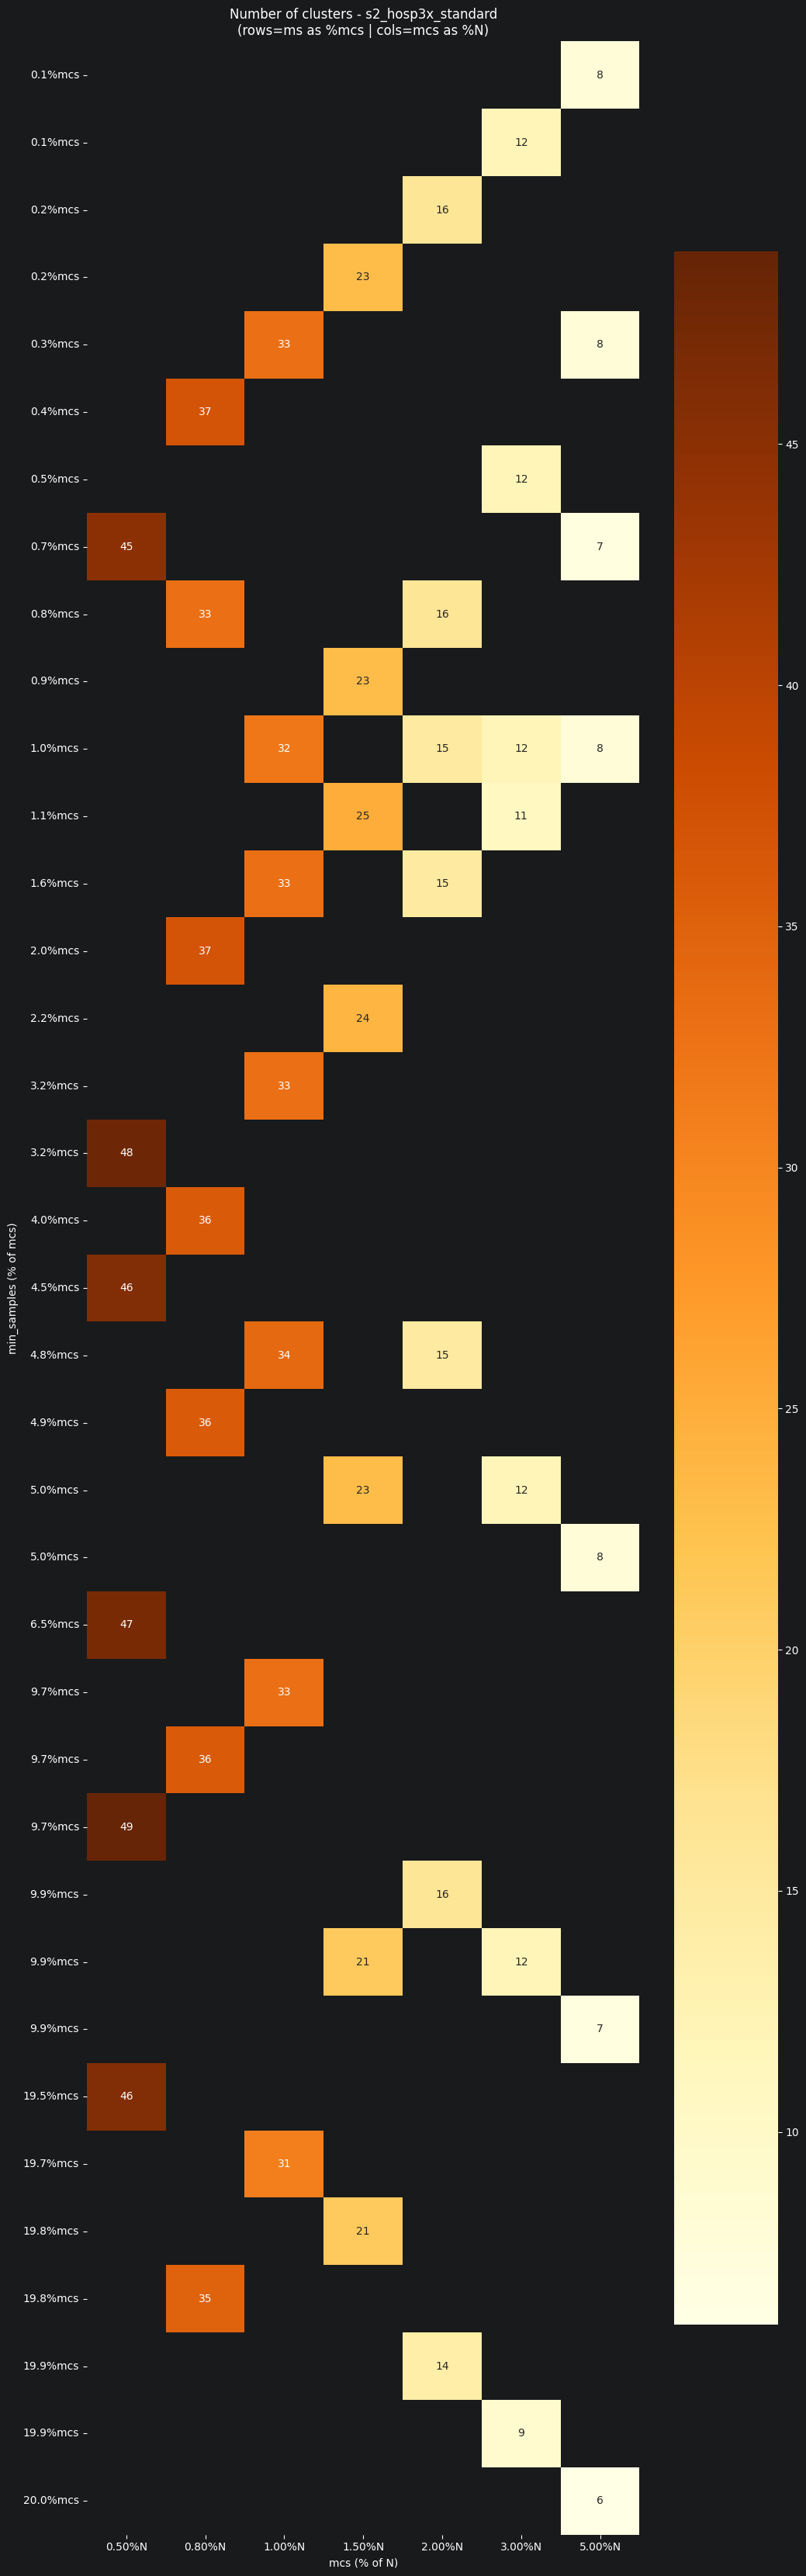

INFO | [s3_noweights] n=30940 | binary=40 | cat=10 | quanti=2



=== TOP 10 lowest outlier rate [s2_hosp3x_standard] ===
 mcs  mcs_pct_N  ms  ms_pct_mcs  n_clusters  outlier_pct  silhouette  stability  combined_score
 247        0.8   5        2.02          37          2.3      0.7322        1.0          0.3257
 154        0.5   7        4.55          46          2.6      0.7909        1.0          0.3841
 618        2.0   1        0.16          16          2.6      0.5820        1.0          0.1733
 154        0.5   5        3.25          48          3.1      0.7906        1.0          0.3825
 309        1.0   5        1.62          33          3.2      0.7076        1.0          0.2984
 464        1.5   5        1.08          25          3.6      0.6421        1.0          0.2307
 154        0.5   1        0.65          45          3.8      0.7781        1.0          0.3676
 154        0.5  15        9.74          49          3.8      0.7988        1.0          0.3885
 464        1.5   1        0.22          23          4.2      0.6246        1.0

INFO | [s3_noweights] Distance matrix: 4100.1s
/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
INFO | [s3_noweights] UMAP shape=(30940, 10) - 165.5s
INFO | [s3_noweights] HDBSCAN: 2.0s
INFO | [s3_noweights] clusters=24 | noise=5249 (17.0%)



 Grid: 48 combinations for N=30,940
   mcs range: 154 - 1,547
   ms  range: fixed [1, 5, 10] + ['1%mcs', '5%mcs', '10%mcs', '20%mcs']


INFO | [s3_noweights] mcs=  154 (0.50%N) | ms=   1 (0.7%mcs) | clusters=62 | outliers=7.5% | sil=0.406
INFO | [s3_noweights] mcs=  154 (0.50%N) | ms=   5 (3.2%mcs) | clusters=58 | outliers=8.9% | sil=0.376
INFO | [s3_noweights] mcs=  154 (0.50%N) | ms=   7 (4.5%mcs) | clusters=60 | outliers=9.7% | sil=0.385
INFO | [s3_noweights] mcs=  154 (0.50%N) | ms=  10 (6.5%mcs) | clusters=58 | outliers=8.5% | sil=0.384
INFO | [s3_noweights] mcs=  154 (0.50%N) | ms=  15 (9.7%mcs) | clusters=58 | outliers=7.9% | sil=0.396
INFO | [s3_noweights] mcs=  154 (0.50%N) | ms=  30 (19.5%mcs) | clusters=55 | outliers=7.9% | sil=0.428
INFO | [s3_noweights] mcs=  247 (0.80%N) | ms=   1 (0.4%mcs) | clusters=39 | outliers=14.4% | sil=0.356
INFO | [s3_noweights] mcs=  247 (0.80%N) | ms=   2 (0.8%mcs) | clusters=37 | outliers=9.9% | sil=0.409
INFO | [s3_noweights] mcs=  247 (0.80%N) | ms=   5 (2.0%mcs) | clusters=33 | outliers=14.1% | sil=0.355
INFO | [s3_noweights] mcs=  247 (0.80%N) | ms=  10 (4.0%mcs) | cluster

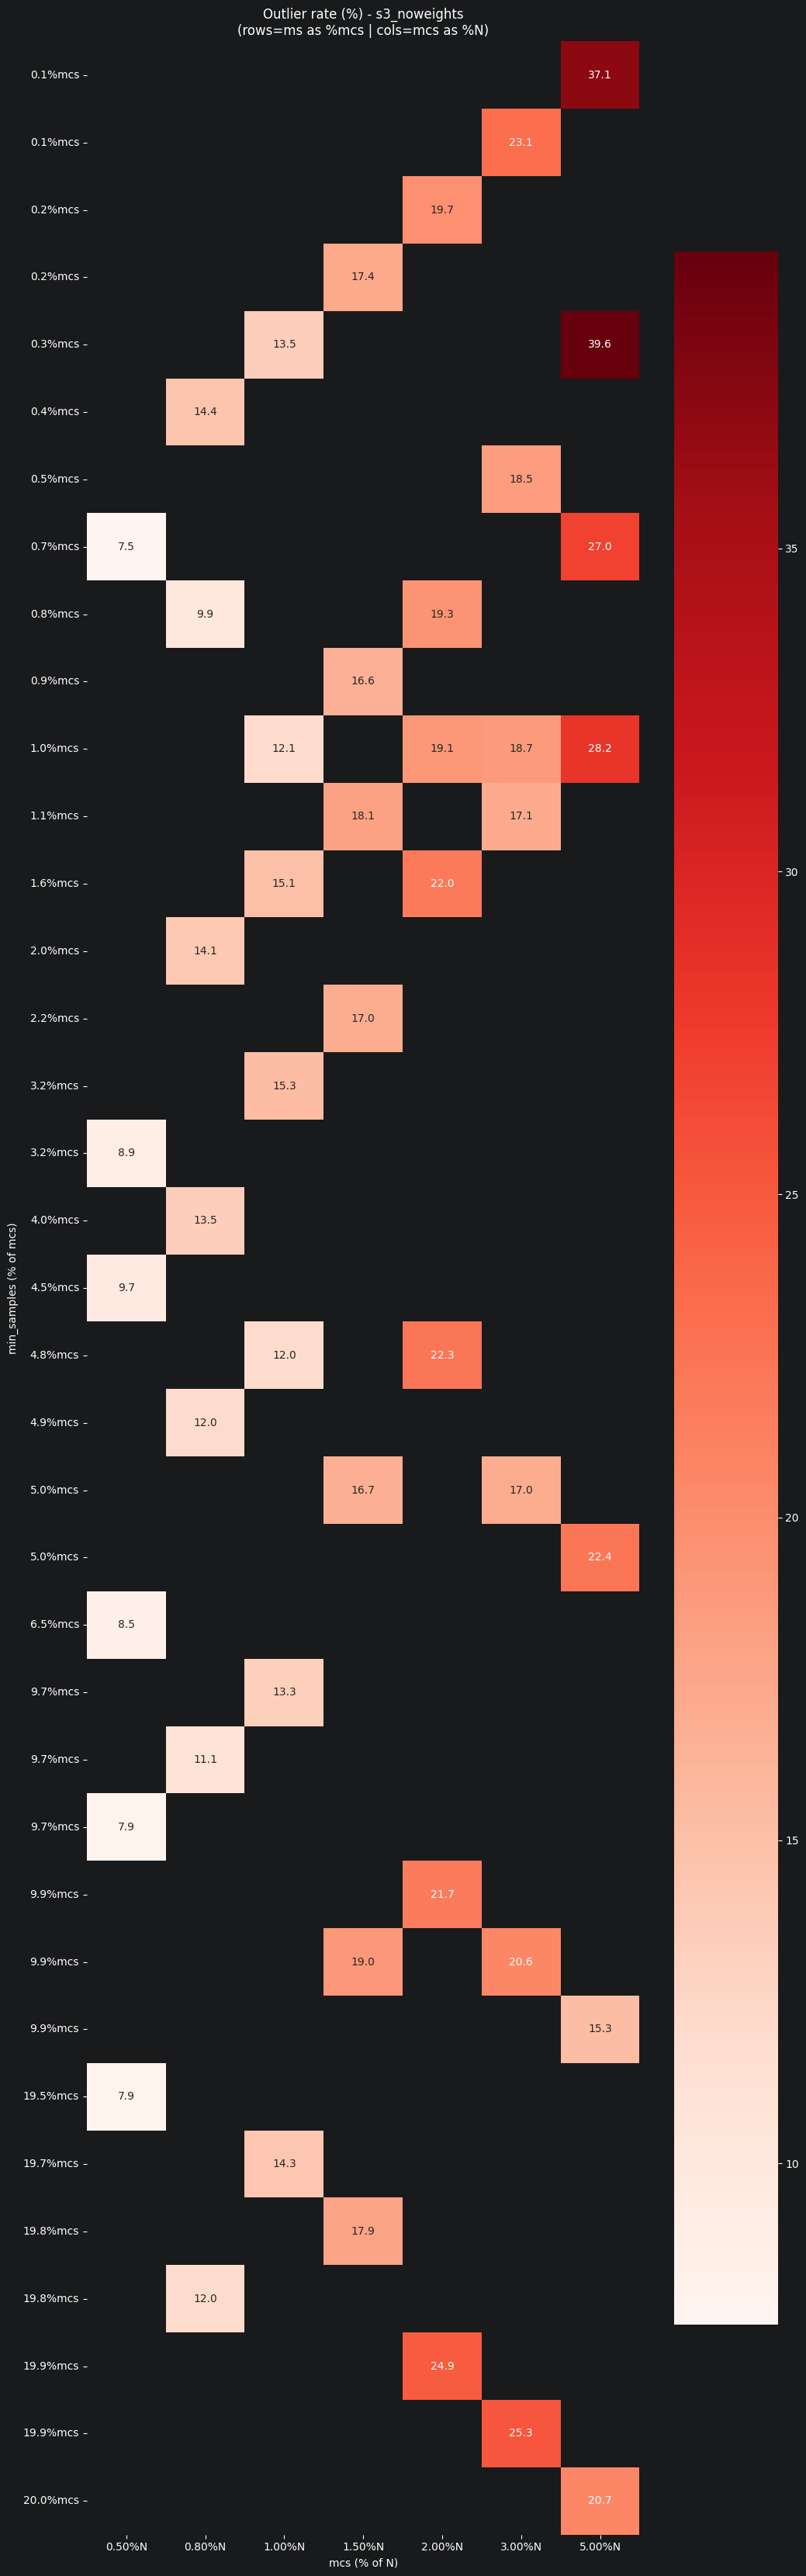

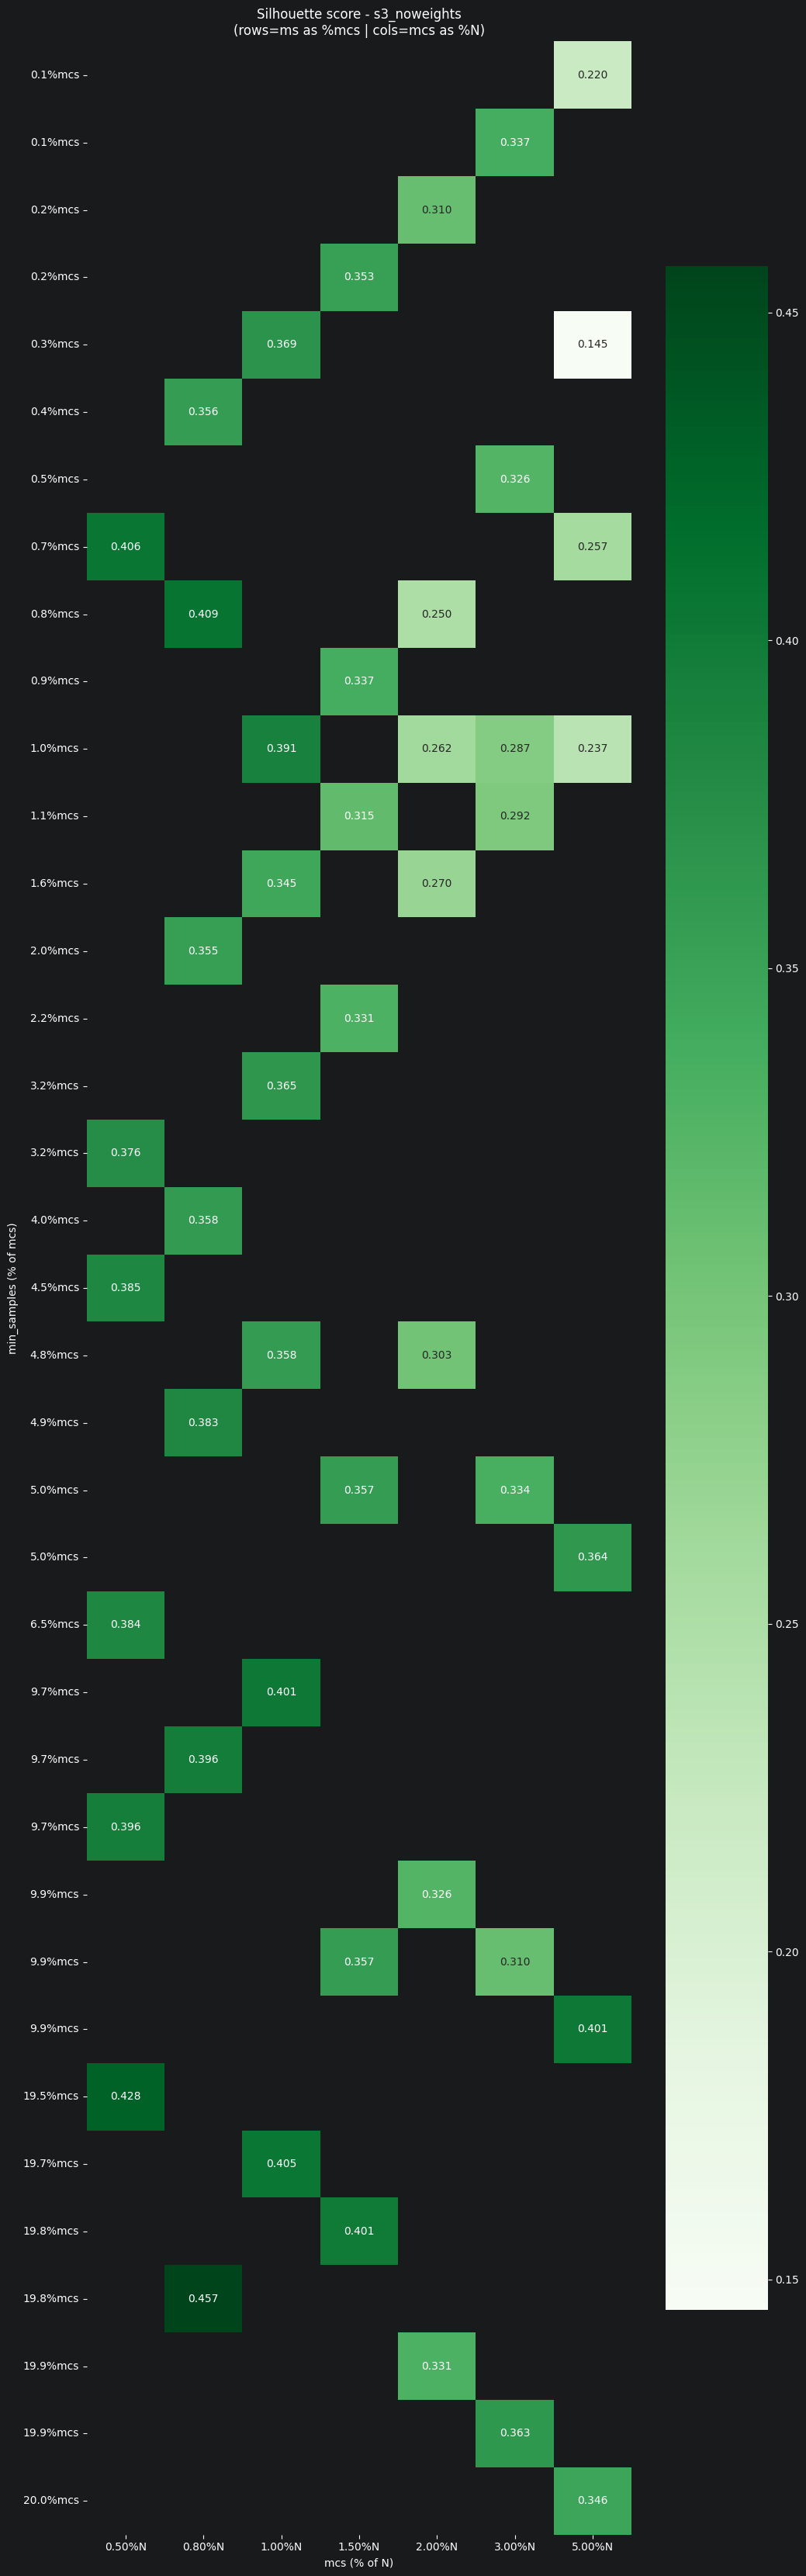

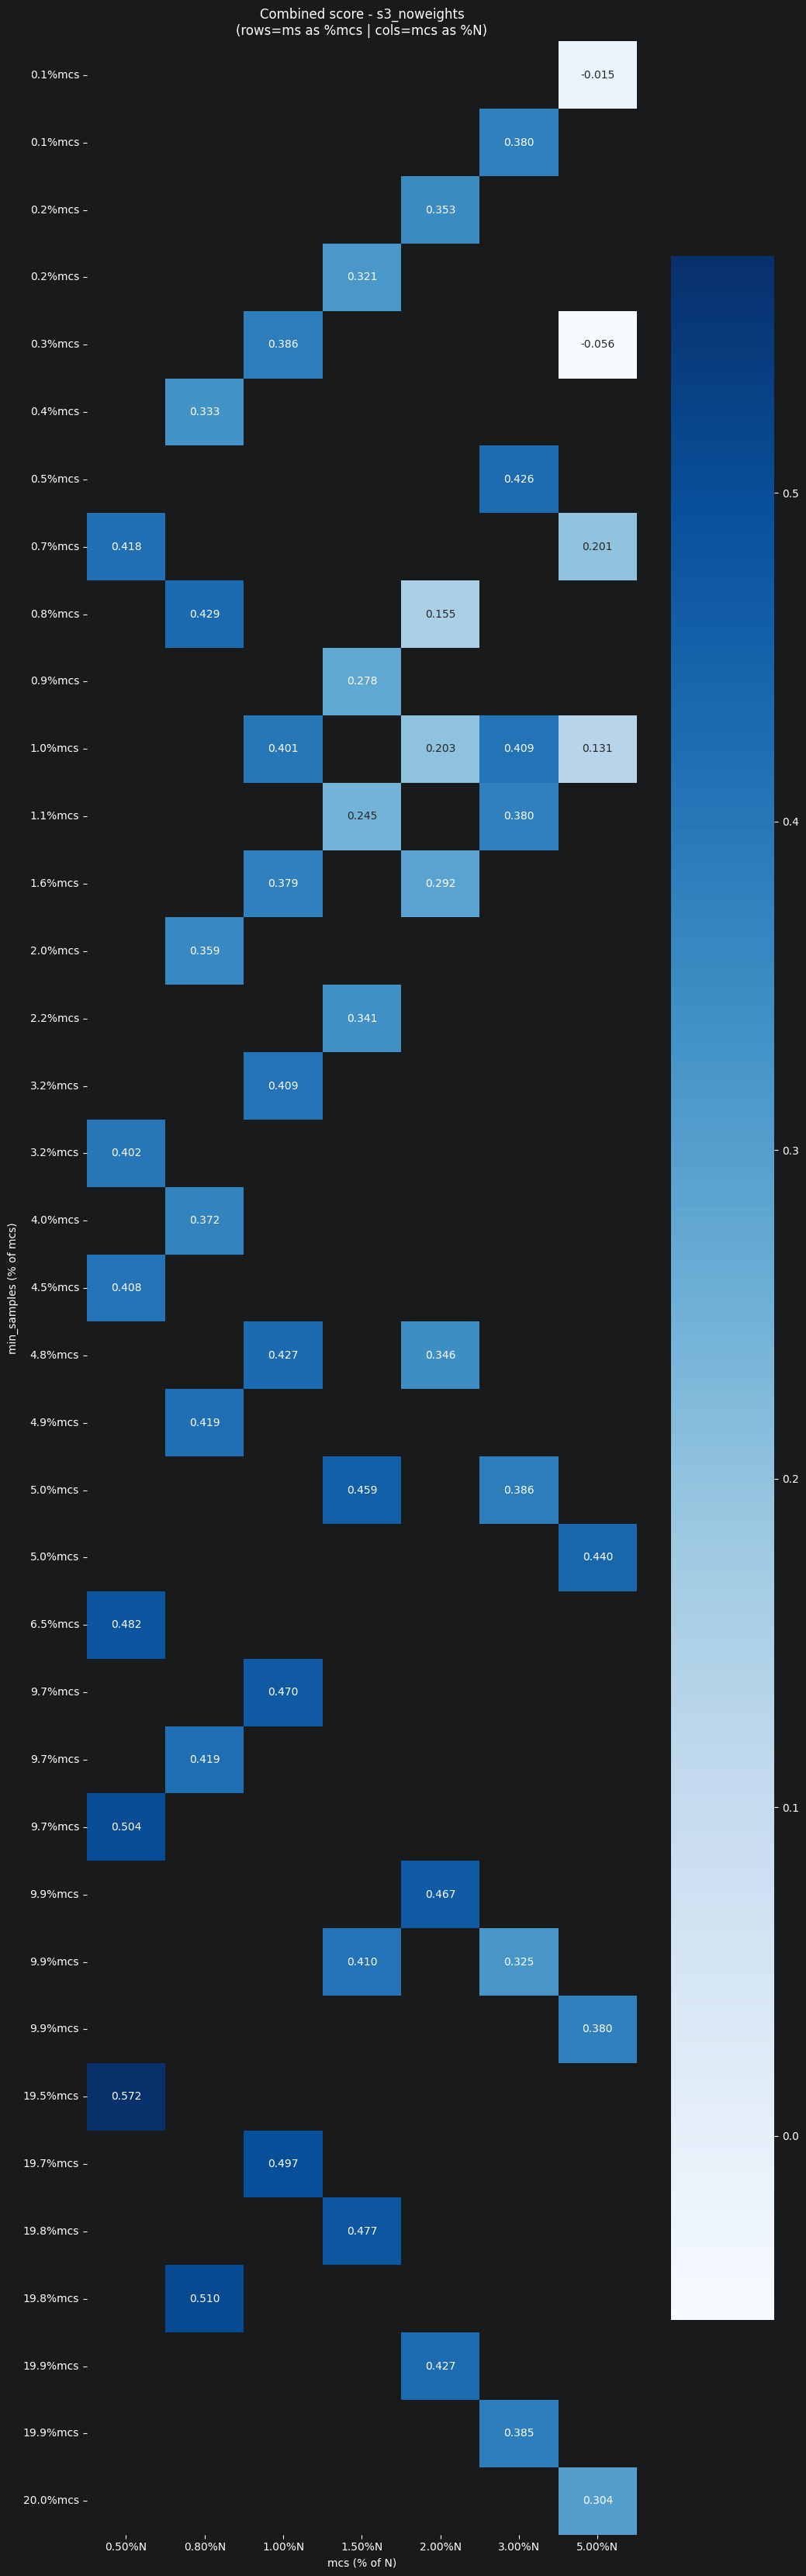

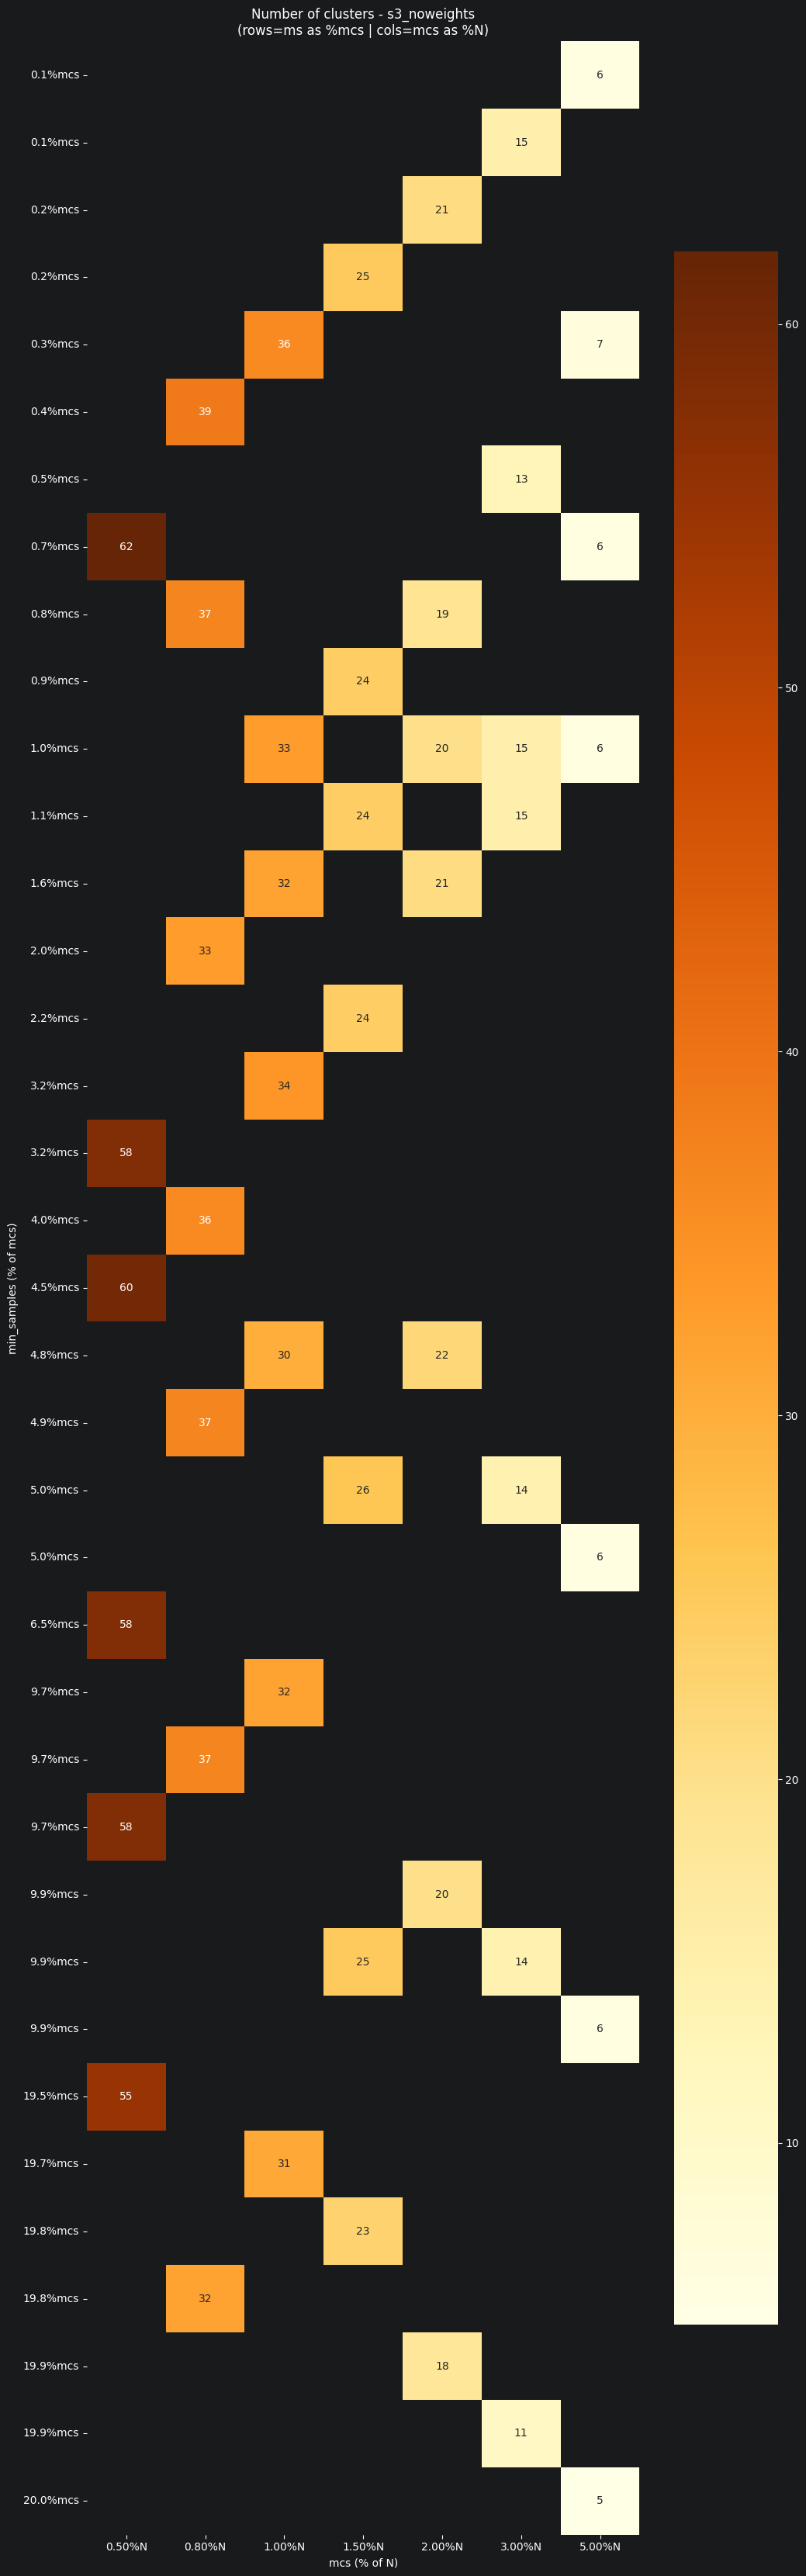

INFO | [s3_catdown] n=30940 | binary=40 | cat=10 | quanti=2



=== TOP 10 lowest outlier rate [s3_noweights] ===
 mcs  mcs_pct_N  ms  ms_pct_mcs  n_clusters  outlier_pct  silhouette  stability  combined_score
 154        0.5   1        0.65          62          7.5      0.4065     0.2165          0.4184
 154        0.5  15        9.74          58          7.9      0.3958     0.2722          0.5045
 154        0.5  30       19.48          55          7.9      0.4278     0.2867          0.5720
 154        0.5  10        6.49          58          8.5      0.3841     0.2690          0.4819
 154        0.5   5        3.25          58          8.9      0.3763     0.2314          0.4024
 154        0.5   7        4.55          60          9.7      0.3846     0.2302          0.4085
 247        0.8   2        0.81          37          9.9      0.4087     0.2247          0.4287
 247        0.8  24        9.72          37         11.1      0.3963     0.2303          0.4195
 247        0.8  49       19.84          32         12.0      0.4570     0.2387      

INFO | [s3_catdown] Distance matrix: 4130.8s
/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
INFO | [s3_catdown] UMAP shape=(30940, 10) - 182.9s
INFO | [s3_catdown] HDBSCAN: 2.9s
INFO | [s3_catdown] clusters=19 | noise=8411 (27.2%)



 Grid: 48 combinations for N=30,940
   mcs range: 154 - 1,547
   ms  range: fixed [1, 5, 10] + ['1%mcs', '5%mcs', '10%mcs', '20%mcs']


INFO | [s3_catdown] mcs=  154 (0.50%N) | ms=   1 (0.7%mcs) | clusters=80 | outliers=12.4% | sil=0.409
INFO | [s3_catdown] mcs=  154 (0.50%N) | ms=   5 (3.2%mcs) | clusters=77 | outliers=15.5% | sil=0.409
INFO | [s3_catdown] mcs=  154 (0.50%N) | ms=   7 (4.5%mcs) | clusters=81 | outliers=15.2% | sil=0.441
INFO | [s3_catdown] mcs=  154 (0.50%N) | ms=  10 (6.5%mcs) | clusters=78 | outliers=12.7% | sil=0.448
INFO | [s3_catdown] mcs=  154 (0.50%N) | ms=  15 (9.7%mcs) | clusters=81 | outliers=14.5% | sil=0.453
INFO | [s3_catdown] mcs=  154 (0.50%N) | ms=  30 (19.5%mcs) | clusters=85 | outliers=14.4% | sil=0.464
INFO | [s3_catdown] mcs=  247 (0.80%N) | ms=   1 (0.4%mcs) | clusters=54 | outliers=19.3% | sil=0.310
INFO | [s3_catdown] mcs=  247 (0.80%N) | ms=   2 (0.8%mcs) | clusters=51 | outliers=23.5% | sil=0.286
INFO | [s3_catdown] mcs=  247 (0.80%N) | ms=   5 (2.0%mcs) | clusters=46 | outliers=26.3% | sil=0.256
INFO | [s3_catdown] mcs=  247 (0.80%N) | ms=  10 (4.0%mcs) | clusters=51 | outlie

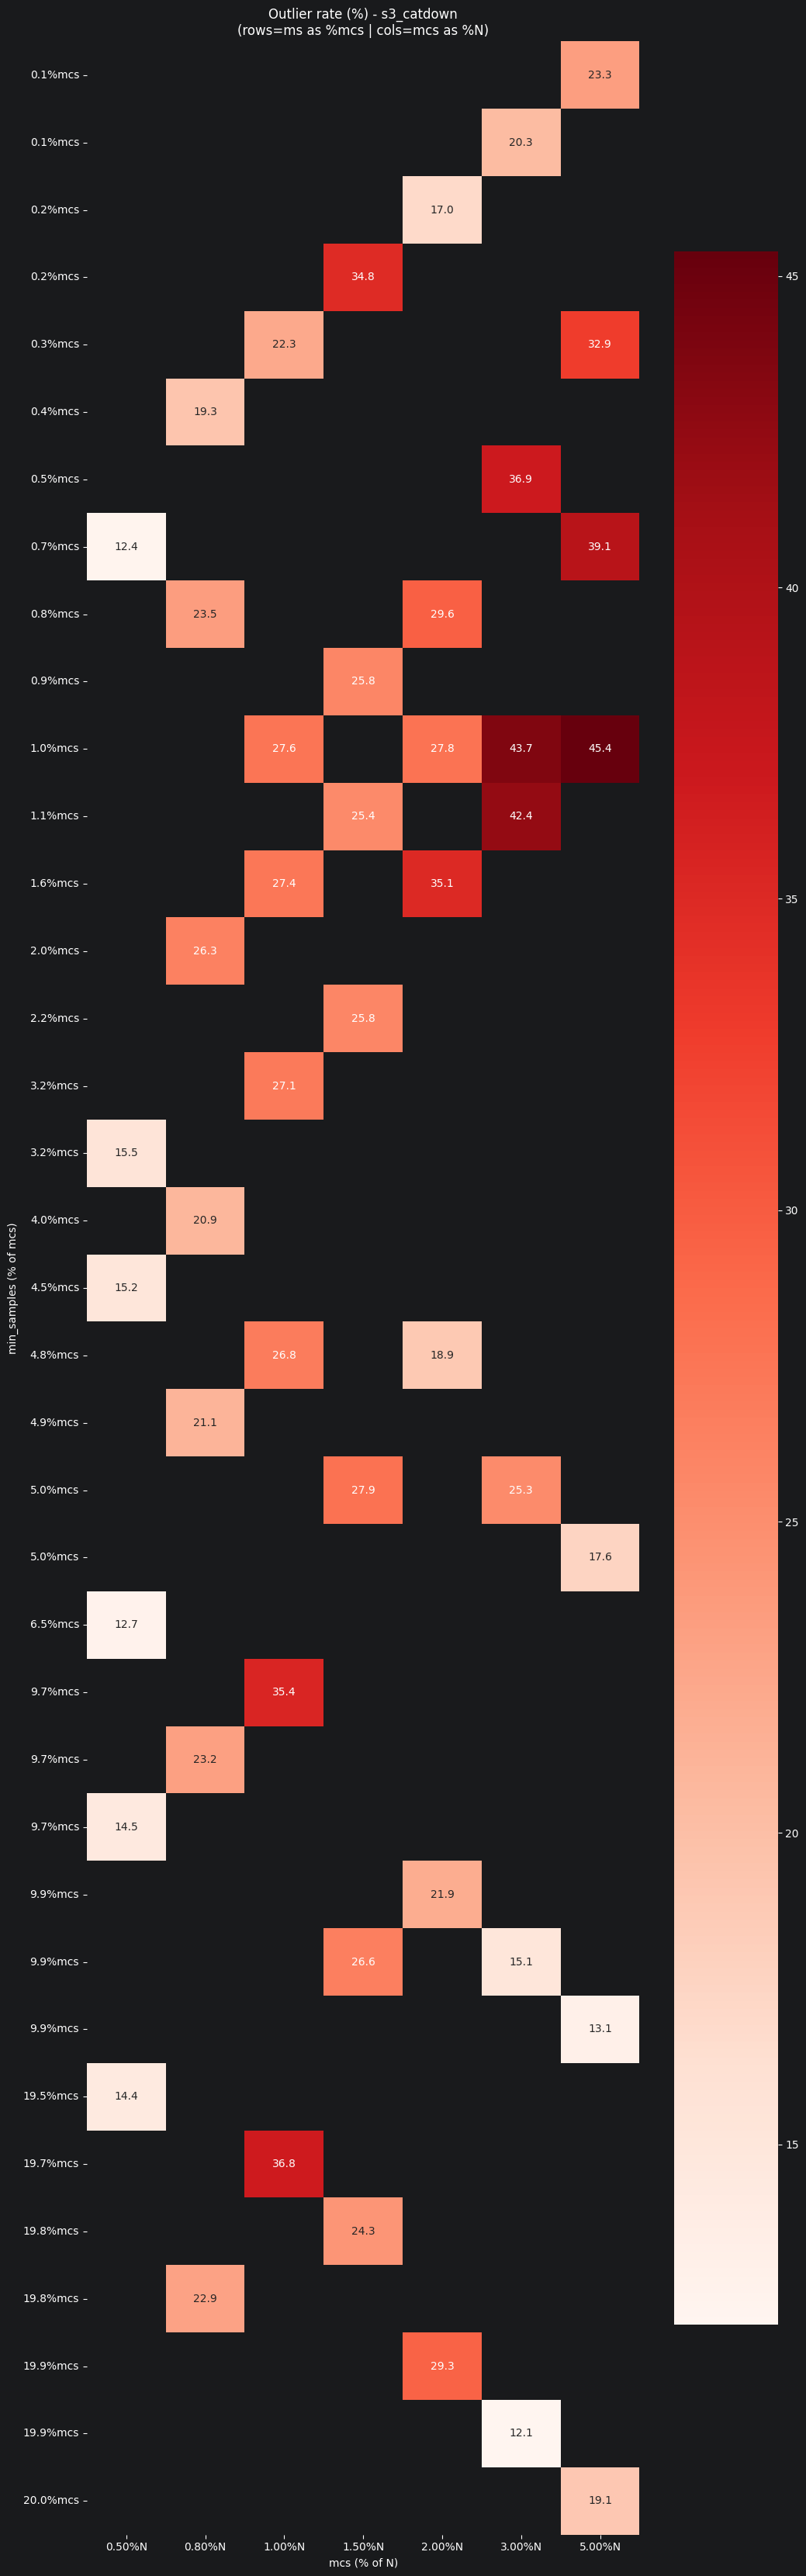

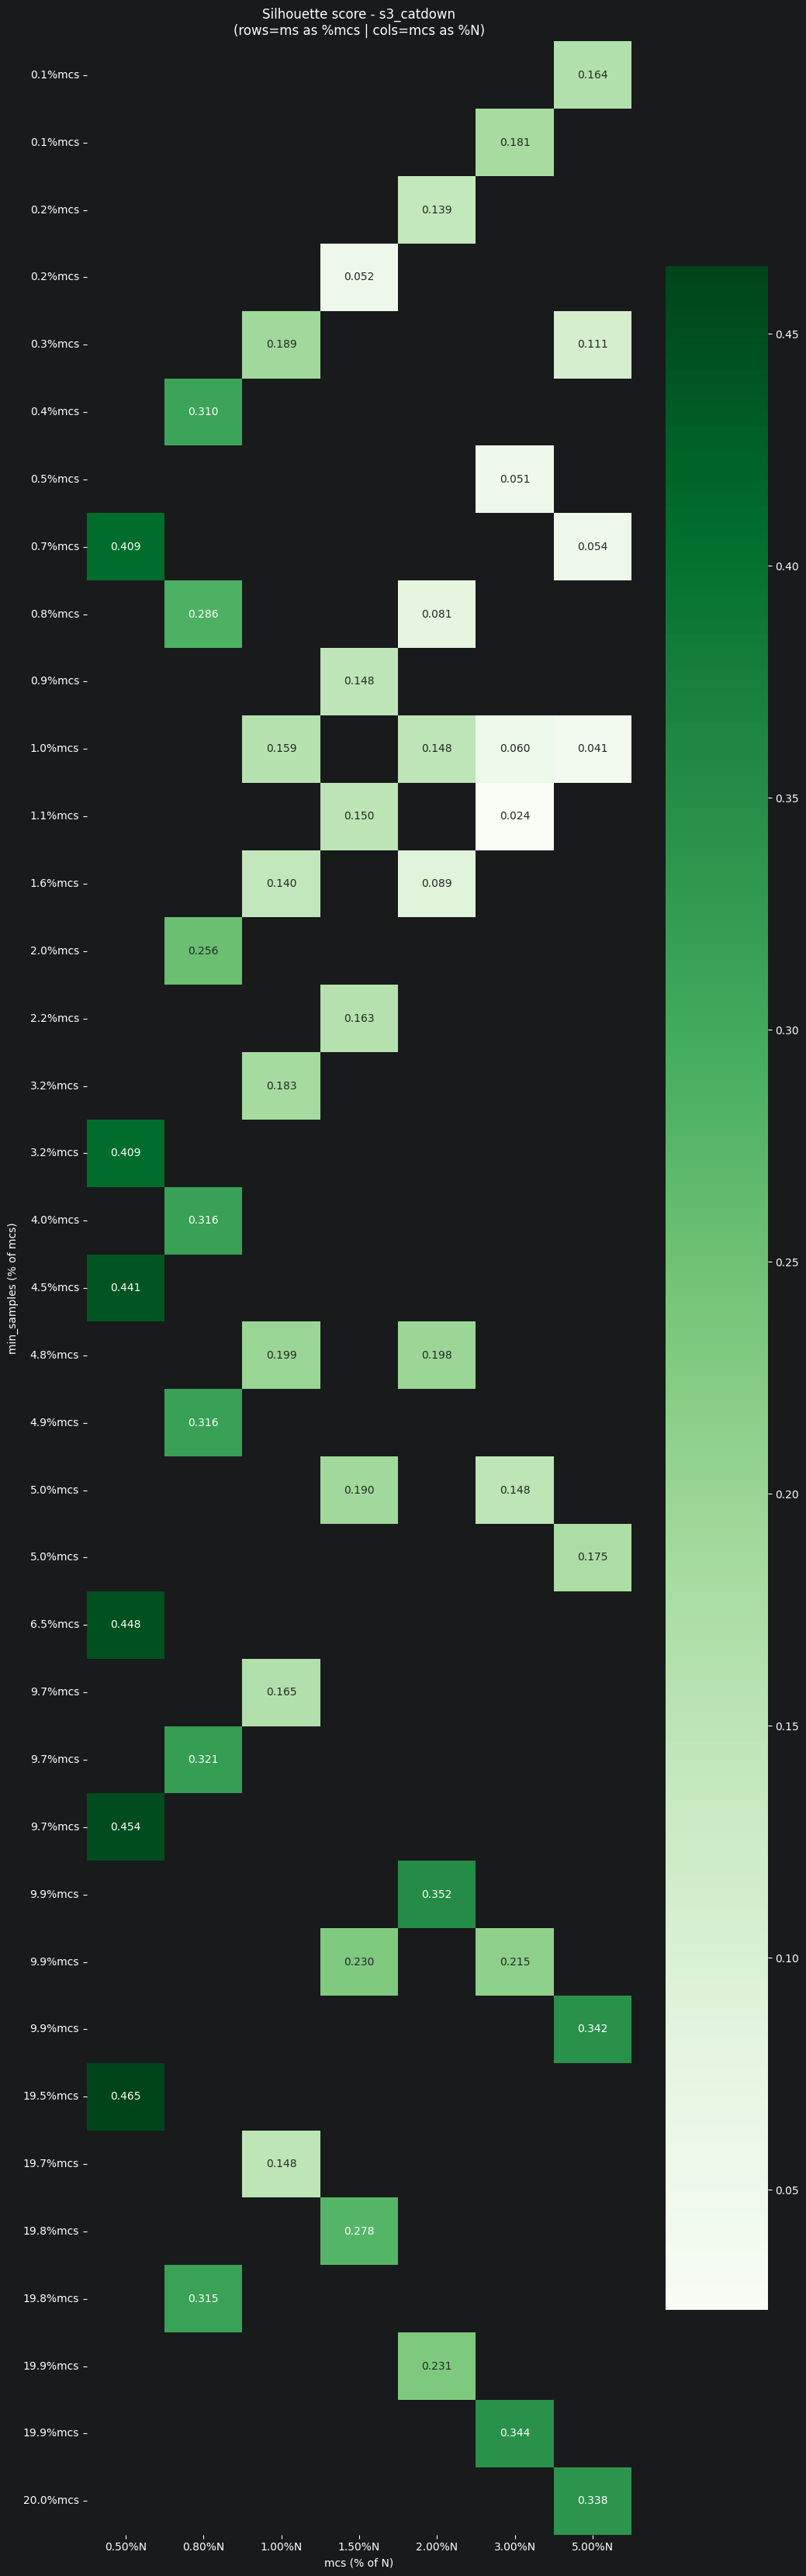

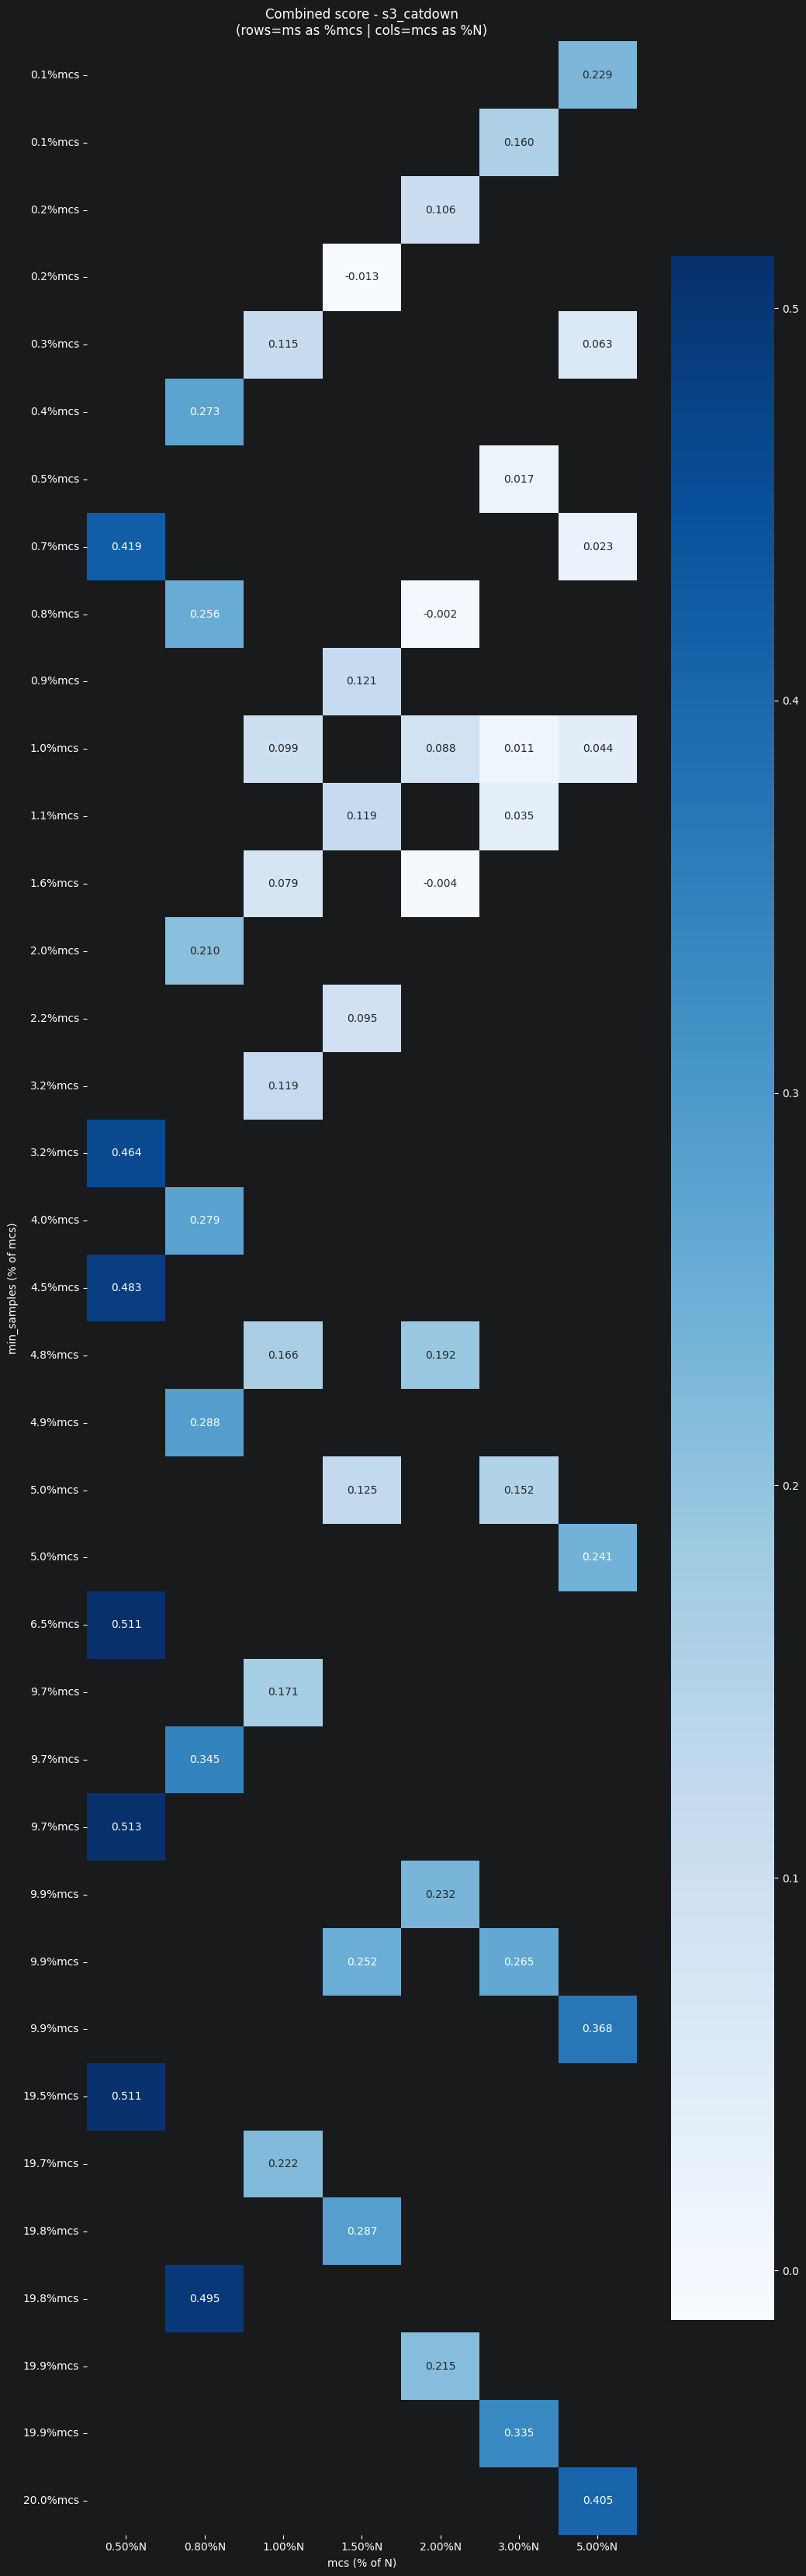

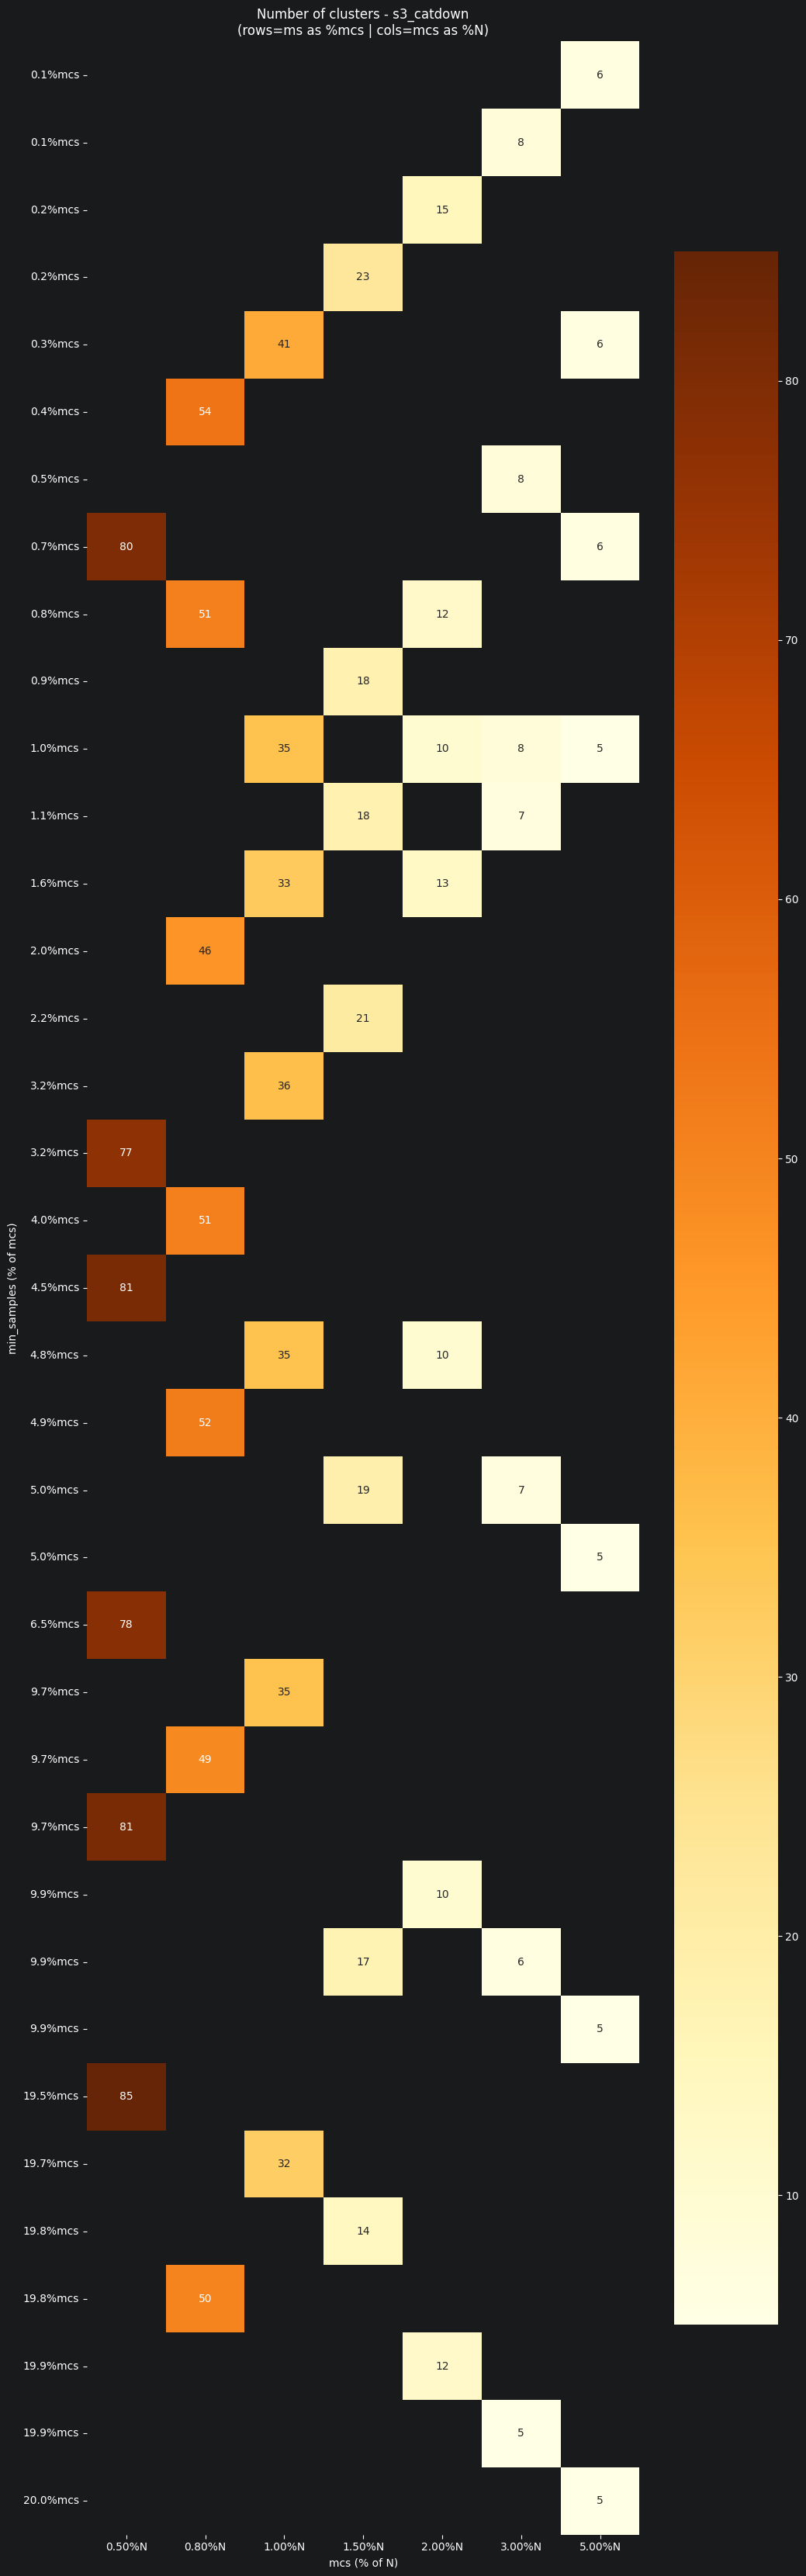

INFO | [s3_catdown_hosp5x] n=30940 | binary=40 | cat=10 | quanti=2



=== TOP 10 lowest outlier rate [s3_catdown] ===
 mcs  mcs_pct_N  ms  ms_pct_mcs  n_clusters  outlier_pct  silhouette  stability  combined_score
 928        3.0 185       19.94           5         12.1      0.3437     0.1419          0.3347
 154        0.5   1        0.65          80         12.4      0.4091     0.1568          0.4189
 154        0.5  10        6.49          78         12.7      0.4478     0.1908          0.5112
1547        5.0 154        9.95           5         13.1      0.3424     0.1639          0.3683
 154        0.5  30       19.48          85         14.4      0.4645     0.1847          0.5107
 154        0.5  15        9.74          81         14.5      0.4535     0.1921          0.5132
 928        3.0  92        9.91           6         15.1      0.2149     0.1745          0.2646
 154        0.5   7        4.55          81         15.2      0.4407     0.1824          0.4829
 154        0.5   5        3.25          77         15.5      0.4094     0.1882        

INFO | [s3_catdown_hosp5x] Distance matrix: 4125.4s
/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
INFO | [s3_catdown_hosp5x] UMAP shape=(30940, 10) - 167.5s
INFO | [s3_catdown_hosp5x] HDBSCAN: 2.0s
INFO | [s3_catdown_hosp5x] clusters=17 | noise=10282 (33.2%)



 Grid: 48 combinations for N=30,940
   mcs range: 154 - 1,547
   ms  range: fixed [1, 5, 10] + ['1%mcs', '5%mcs', '10%mcs', '20%mcs']


INFO | [s3_catdown_hosp5x] mcs=  154 (0.50%N) | ms=   1 (0.7%mcs) | clusters=83 | outliers=11.3% | sil=0.420
INFO | [s3_catdown_hosp5x] mcs=  154 (0.50%N) | ms=   5 (3.2%mcs) | clusters=79 | outliers=11.5% | sil=0.456
INFO | [s3_catdown_hosp5x] mcs=  154 (0.50%N) | ms=   7 (4.5%mcs) | clusters=76 | outliers=11.5% | sil=0.446
INFO | [s3_catdown_hosp5x] mcs=  154 (0.50%N) | ms=  10 (6.5%mcs) | clusters=78 | outliers=14.5% | sil=0.439
INFO | [s3_catdown_hosp5x] mcs=  154 (0.50%N) | ms=  15 (9.7%mcs) | clusters=81 | outliers=14.9% | sil=0.457
INFO | [s3_catdown_hosp5x] mcs=  154 (0.50%N) | ms=  30 (19.5%mcs) | clusters=78 | outliers=16.5% | sil=0.444
INFO | [s3_catdown_hosp5x] mcs=  247 (0.80%N) | ms=   1 (0.4%mcs) | clusters=50 | outliers=20.3% | sil=0.293
INFO | [s3_catdown_hosp5x] mcs=  247 (0.80%N) | ms=   2 (0.8%mcs) | clusters=51 | outliers=19.0% | sil=0.316
INFO | [s3_catdown_hosp5x] mcs=  247 (0.80%N) | ms=   5 (2.0%mcs) | clusters=51 | outliers=18.1% | sil=0.339
INFO | [s3_catdown

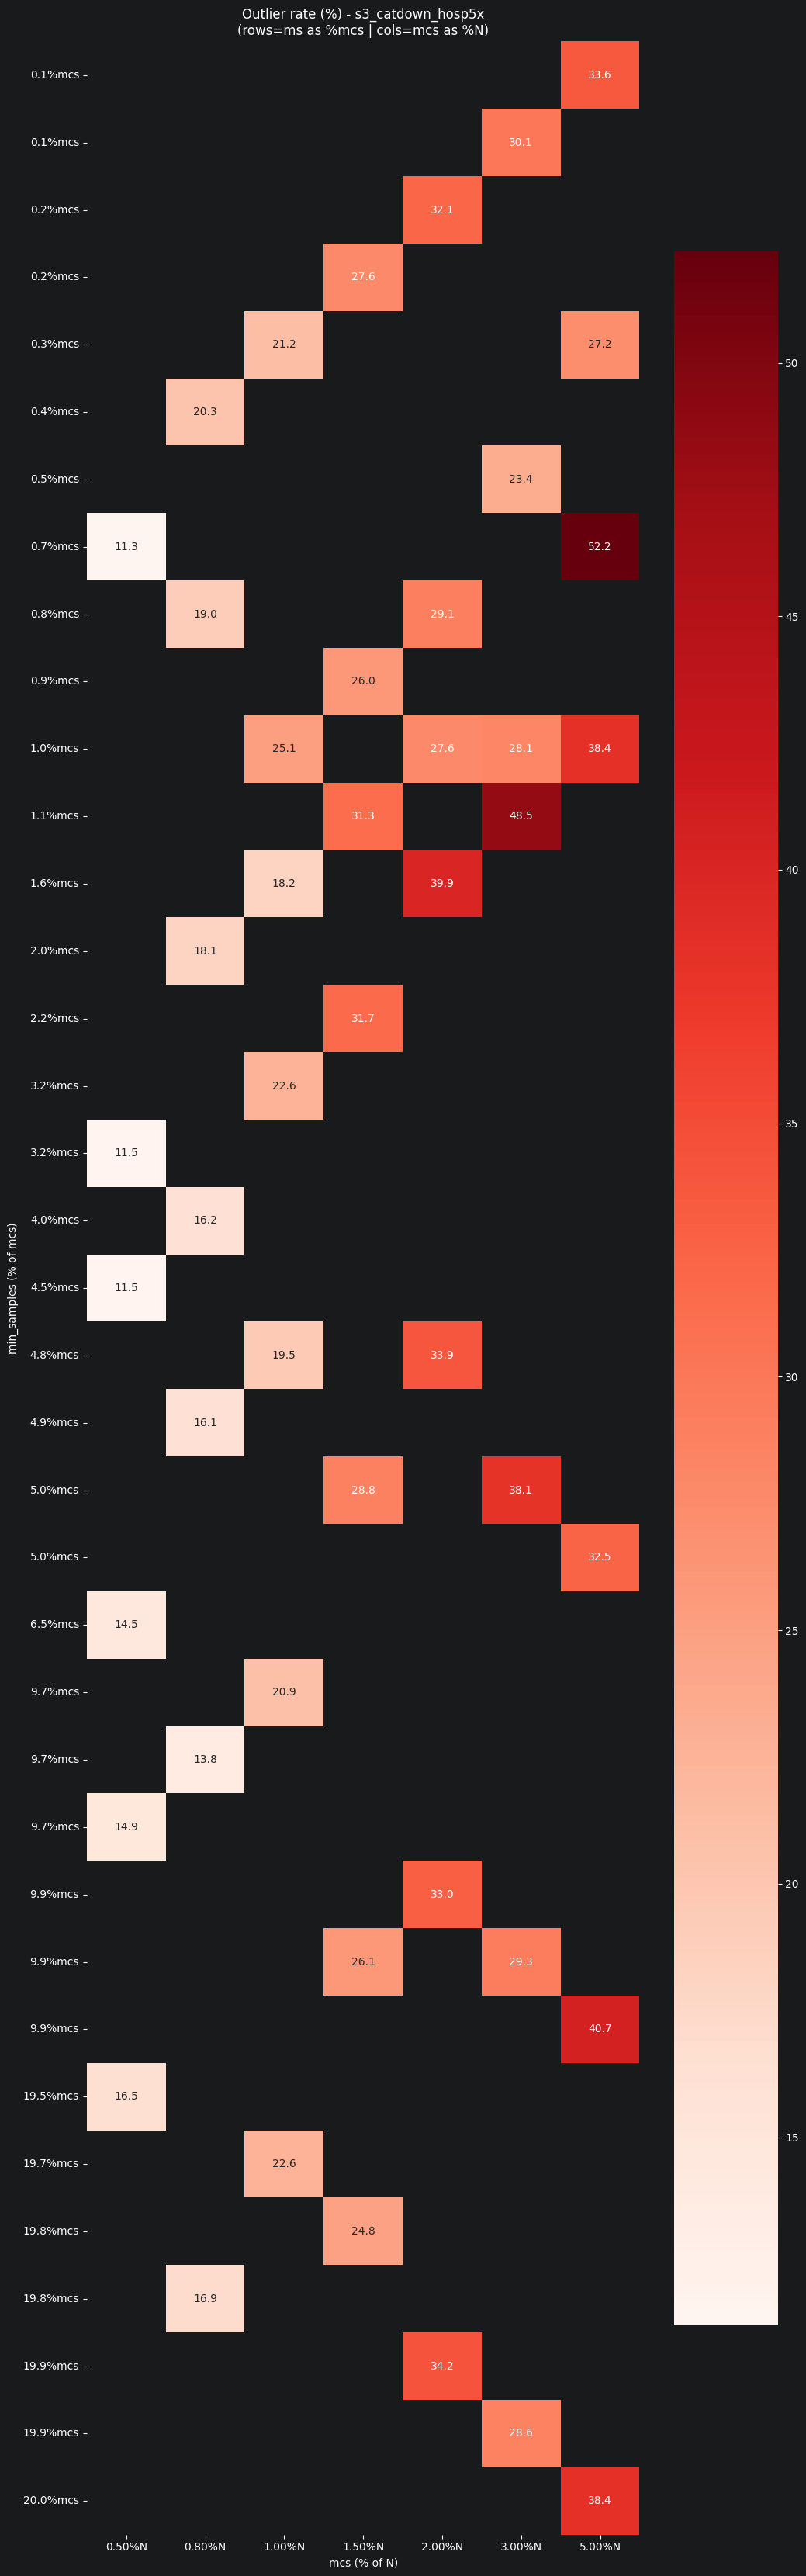

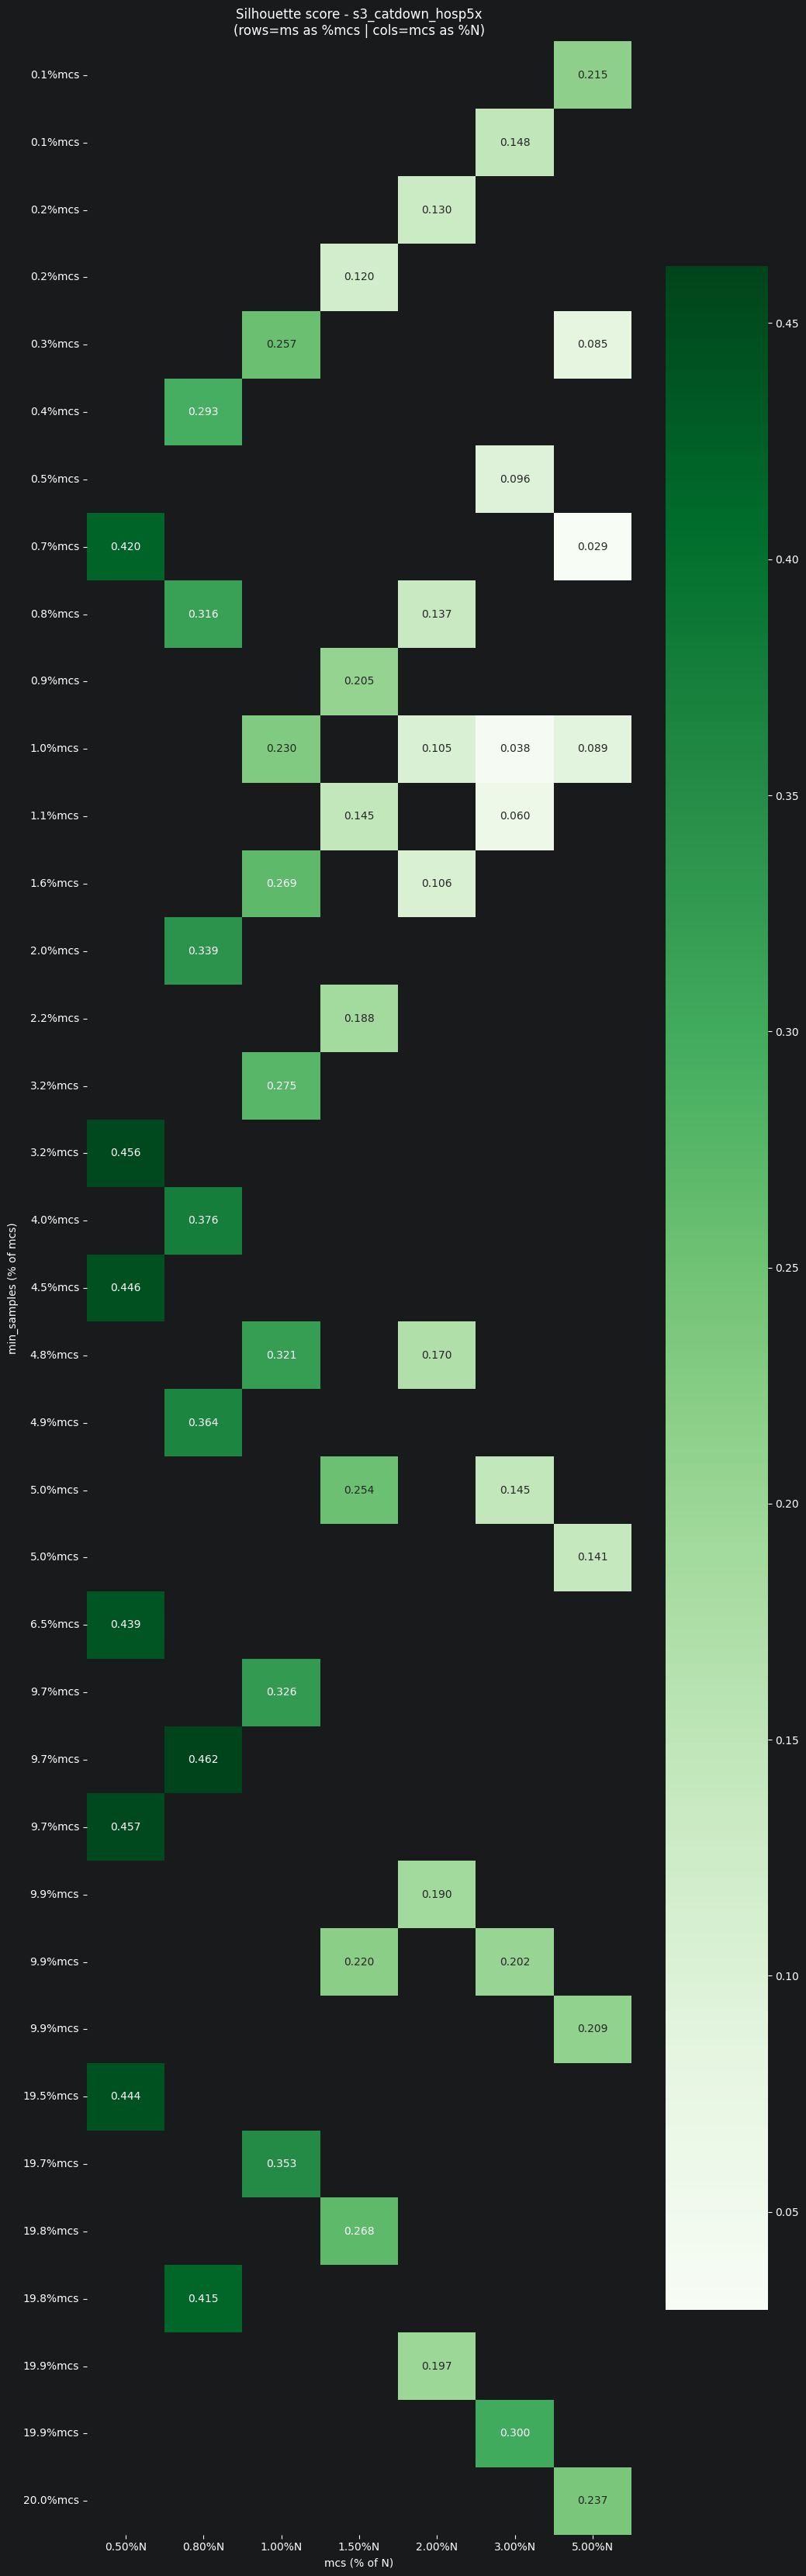

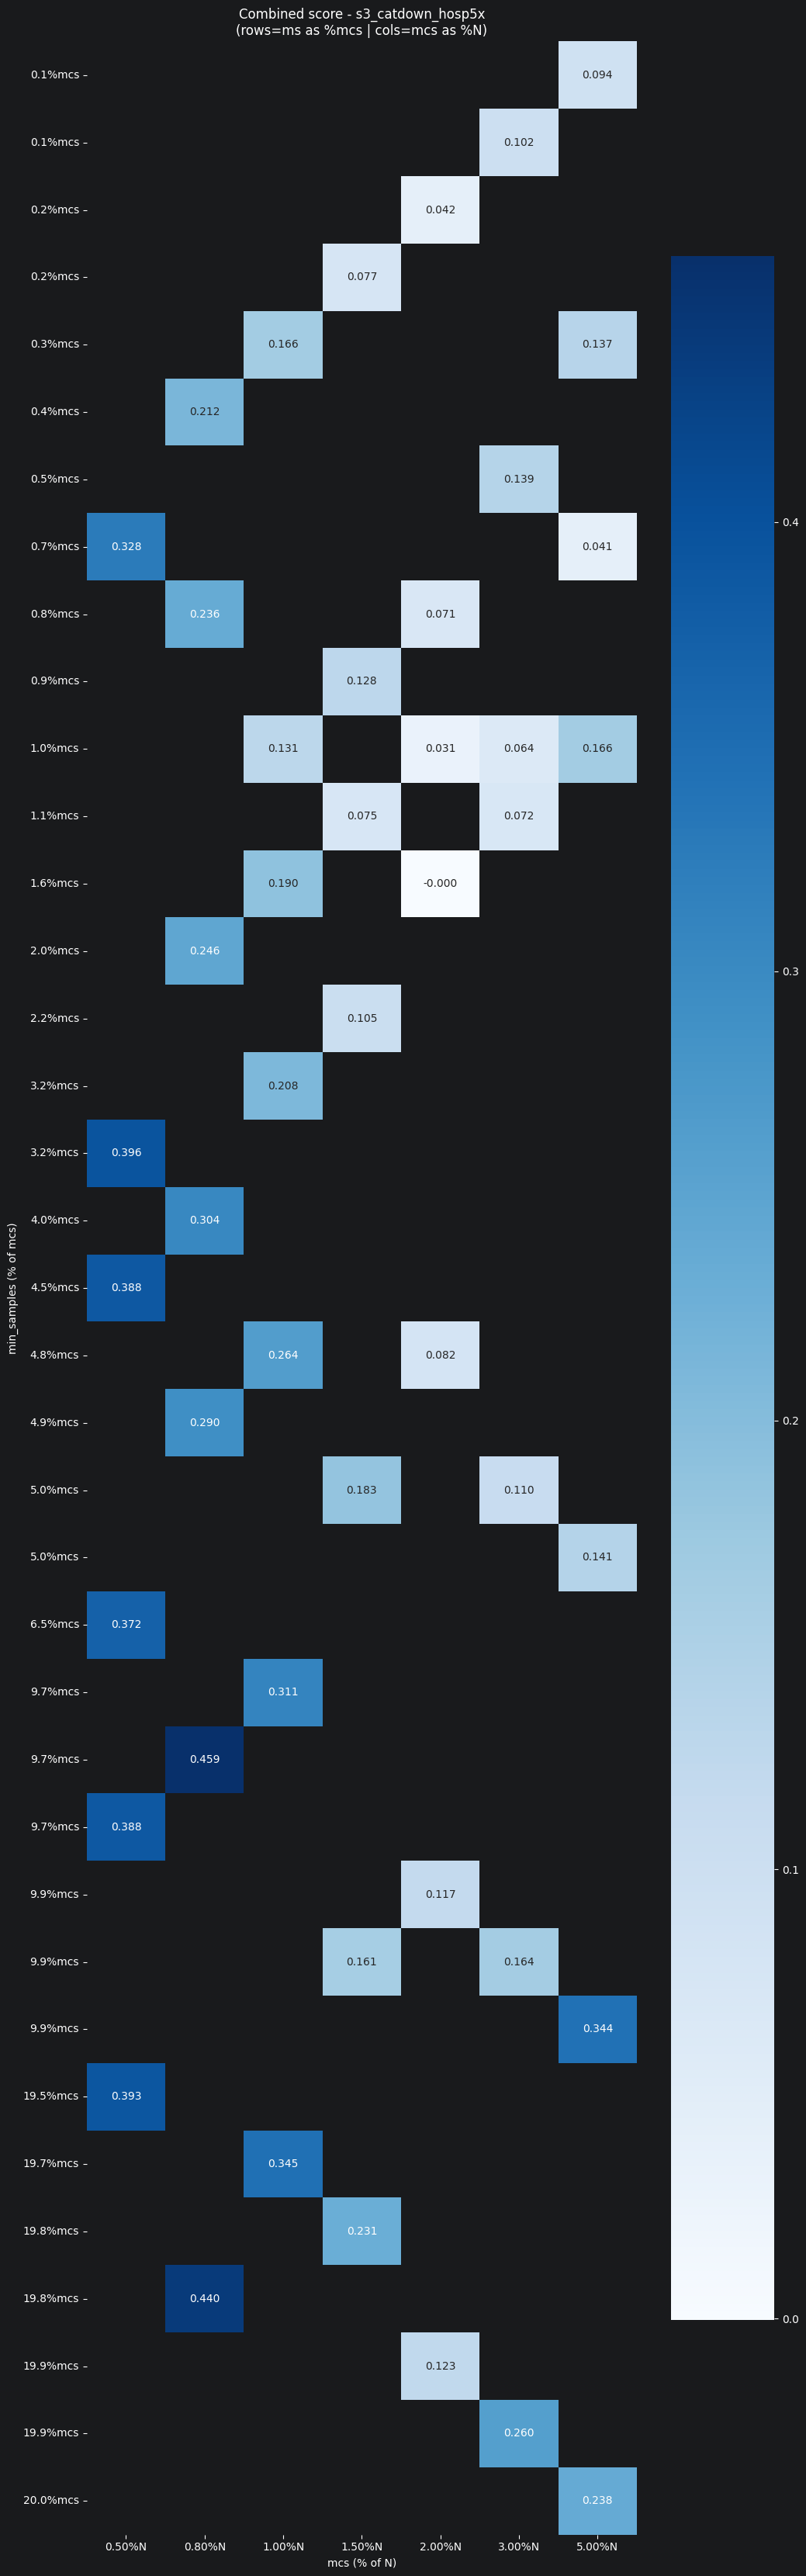

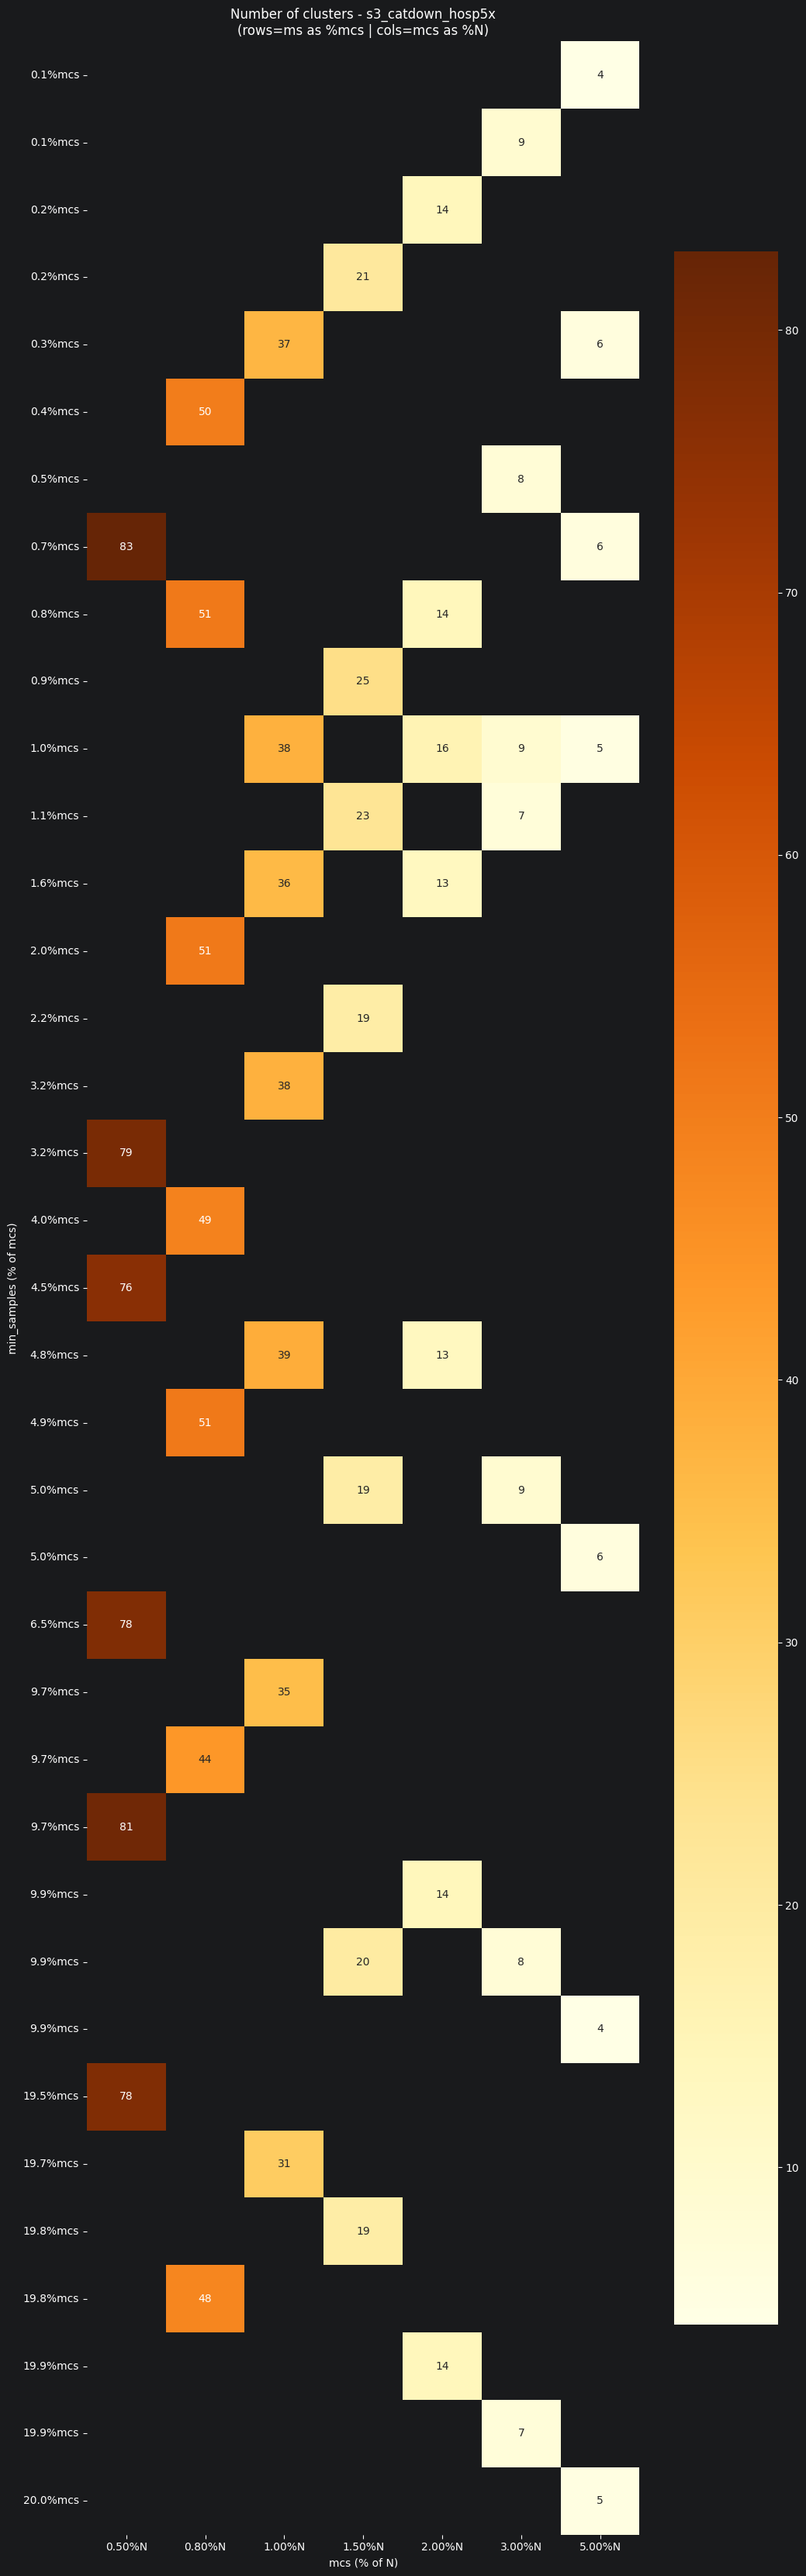


=== TOP 10 lowest outlier rate [s3_catdown_hosp5x] ===
 mcs  mcs_pct_N  ms  ms_pct_mcs  n_clusters  outlier_pct  silhouette  stability  combined_score
 154        0.5   1        0.65          83         11.3      0.4205     0.1138          0.3277
 154        0.5   5        3.25          79         11.5      0.4556     0.1468          0.3960
 154        0.5   7        4.55          76         11.5      0.4464     0.1468          0.3876
 247        0.8  24        9.72          44         13.8      0.4620     0.2051          0.4592
 154        0.5  10        6.49          78         14.5      0.4394     0.1467          0.3719
 154        0.5  15        9.74          81         14.9      0.4568     0.1476          0.3876
 247        0.8  12        4.86          51         16.1      0.3640     0.1403          0.2905
 247        0.8  10        4.05          49         16.2      0.3758     0.1432          0.3042
 154        0.5  30       19.48          78         16.5      0.4438     0.1672 

OSError: [Errno 28] No space left on device

In [3]:
# ==============================================================================
# STEP 1: Load data + compute distance matrices + 2D grid sweep
# ==============================================================================

df = load_and_preprocess(CSV_PATH)
N  = len(df)
print(f"Dataset loaded: {N:,} patients, {df.shape[1]} variables")

print(f"\nGrid parametrization for N={N:,}:")
for pct in MCS_PCT_VALUES:
    mcs     = int(N * pct)
    ms_vals = sorted(set(MS_FIXED_VALUES + [max(1, int(mcs * p)) for p in MS_PCT_MCS_VALUES]))
    print(f"  mcs={mcs:5d} ({pct*100:.1f}%N) | ms={ms_vals}")

stored = {}


# SCENARIO 2 - Hamming + Manhattan, MinMax vs Standard scaler
S2_RUNS = [
    {"run_label": "s2_noweights", "weight_hosp": 1.0,            "weight_quanti": 1.0},
    {"run_label": "s2_hosp3x",    "weight_hosp": WEIGHT_HOSP_S2, "weight_quanti": 1.0},
]

for scaler in SCALERS:
    print(f"\n{'='*60}\nSCALER: {scaler}\n{'='*60}")

    for run in S2_RUNS:
        label   = f"{run['run_label']}_{scaler}"
        out_dir = os.path.join(OUTPUT_DIR, scaler, run["run_label"])
        print(f"\n--- {label} ---")

        df_sub, D, fit_input, labels, clusterer = run_hdbscan(
            df,
            scenario_name   = "scenario_2",
            run_label       = run["run_label"],
            distance_metric = "precomputed",
            scaler          = scaler,
            weight_hosp     = run["weight_hosp"],
            weight_quanti   = run["weight_quanti"],
        )

        stored[label] = {"df_sub": df_sub, "fit_input": D, "metric": "precomputed"}

        run_grid_sweep(fit_input=D, metric="precomputed",
                       run_label=label, out_dir=out_dir, N=N)


# SCENARIO 3 - Gower -> UMAP -> grid sweep
S3_RUNS = [
    {"run_label": "s3_noweights",      "gower_weights": None},
    {
        "run_label"    : "s3_catdown",
        "gower_weights": {
            **{col: WEIGHT_BIO_VEINOUS      for col in BIO_VEINOUS},
            **{col: WEIGHT_IMAGING_DETAILED for col in IMAGING_COLS_DETAILED},
        },
    },
    {
        "run_label"    : "s3_catdown_hosp5x",
        "gower_weights": {
            **{col: WEIGHT_BIO_VEINOUS      for col in BIO_VEINOUS},
            **{col: WEIGHT_IMAGING_DETAILED for col in IMAGING_COLS_DETAILED},
            "hospitalization": WEIGHT_HOSP_S3,
        },
    },
]

print(f"\n{'='*60}\nSCENARIO 3 - Gower\n{'='*60}")

for run in S3_RUNS:
    label   = run["run_label"]
    out_dir = os.path.join(OUTPUT_DIR, "gower", label)
    print(f"\n--- {label} ---")

    df_sub, D, fit_input, labels, clusterer = run_hdbscan(
        df,
        scenario_name   = "scenario_3",
        run_label       = label,
        distance_metric = "gower",
        gower_weights   = run["gower_weights"],
    )

    stored[label] = {"df_sub": df_sub, "fit_input": fit_input, "metric": "euclidean"}

    run_grid_sweep(fit_input=fit_input, metric="euclidean",
                   run_label=label, out_dir=out_dir, N=N)


# Save cache
cache_path  = os.path.join(OUTPUT_DIR, "cache")
os.makedirs(cache_path, exist_ok=True)
timestamp   = datetime.now().strftime("%Y%m%d_%H%M%S")
stored_file = os.path.join(cache_path, f"stored_{timestamp}.pkl")
latest_file = os.path.join(cache_path, "stored_latest.pkl")
with open(stored_file, "wb") as f: pickle.dump(stored, f)
with open(latest_file, "wb") as f: pickle.dump(stored, f)
print(f"\nCache saved: {stored_file}")

print("\n" + "="*60)
print("STEP 1 COMPLETE")
print("="*60)
print("-> Review the 4 heatmaps per run above")
print("-> Pick (mcs, ms): low outlier rate + stable clusters")
print("-> Update FINAL_PARAMS in Chunk 1")
print("-> Run Chunk 4")


---
## CHUNK 4 - STEP 2: Final run with optimal parameters + full visualizations

**Prerequisites:**
1. FINAL_PARAMS updated in Chunk 1
2. Either stored in memory (from Chunk 3) OR cache file available

**Visualizations per run:**
- HDBSCAN native trees: condensed, single linkage, MST (S3 only), cluster persistence
- Cluster profile heatmap + Ward dendrogram (most discriminating variable per merge)
- UMAP 2D (png) + UMAP 3D (interactive HTML)
- t-SNE 2D (png) + t-SNE 3D (interactive HTML)
- Outlier description: heatmap, bar chart, CSV


In [ ]:
# ==============================================================================
# STEP 2: Final HDBSCAN run + full visualizations
# ==============================================================================

# Load cache if stored not in memory
cache_path  = os.path.join(OUTPUT_DIR, "cache")
latest_file = os.path.join(cache_path, "stored_latest.pkl")

if "stored" not in dir() or not stored:
    if os.path.exists(latest_file):
        print("Loading stored from cache...")
        with open(latest_file, "rb") as f:
            stored = pickle.load(f)
    else:
        raise RuntimeError("stored not found - run Chunk 3 first")

print("\nAvailable keys in stored:")
for k in stored.keys():
    print(f"  - {k}")

df = load_and_preprocess(CSV_PATH)


# SCENARIO 2 - Final runs
print("\nSCENARIO 2 - Final runs")
print("="*60)

for run_label, weight_hosp in [
    ("s2_noweights", 1.0),
    ("s2_hosp3x",    WEIGHT_HOSP_S2),
]:
    for scaler in SCALERS:
        final_label = f"{run_label}_{scaler}"
        mcs, ms     = FINAL_PARAMS[final_label]
        out_dir     = os.path.join(OUTPUT_DIR, scaler, run_label, f"final_mcs{mcs}_ms{ms}")

        print(f"\n--- {final_label} | mcs={mcs}, min_samples={ms} ---")

        df_sub, D, fit_input, labels, clusterer = run_hdbscan(
            df,
            scenario_name    = "scenario_2",
            run_label        = run_label,
            distance_metric  = "precomputed",
            scaler           = scaler,
            weight_hosp      = weight_hosp,
            min_cluster_size = mcs,
            min_samples      = ms,
        )

        run_full_postprocessing(
            df_sub=df_sub, D=D, fit_input=fit_input,
            labels=labels, clusterer=clusterer,
            run_label=final_label, out_dir=out_dir, metric="precomputed",
        )


# SCENARIO 3 - Final runs
print("\nSCENARIO 3 - Final runs")
print("="*60)

S3_FINAL_RUNS = [
    {"run_label": "s3_noweights",      "gower_weights": None},
    {
        "run_label"    : "s3_catdown",
        "gower_weights": {
            **{col: WEIGHT_BIO_VEINOUS      for col in BIO_VEINOUS},
            **{col: WEIGHT_IMAGING_DETAILED for col in IMAGING_COLS_DETAILED},
        },
    },
    {
        "run_label"    : "s3_catdown_hosp5x",
        "gower_weights": {
            **{col: WEIGHT_BIO_VEINOUS      for col in BIO_VEINOUS},
            **{col: WEIGHT_IMAGING_DETAILED for col in IMAGING_COLS_DETAILED},
            "hospitalization": WEIGHT_HOSP_S3,
        },
    },
]

for run in S3_FINAL_RUNS:
    label   = run["run_label"]
    mcs, ms = FINAL_PARAMS[label]
    out_dir = os.path.join(OUTPUT_DIR, "gower", label, f"final_mcs{mcs}_ms{ms}")

    print(f"\n--- {label} | mcs={mcs}, min_samples={ms} ---")

    df_sub, D, fit_input, labels, clusterer = run_hdbscan(
        df,
        scenario_name    = "scenario_3",
        run_label        = label,
        distance_metric  = "gower",
        gower_weights    = run["gower_weights"],
        min_cluster_size = mcs,
        min_samples      = ms,
    )

    run_full_postprocessing(
        df_sub=df_sub, D=D, fit_input=fit_input,
        labels=labels, clusterer=clusterer,
        run_label=label, out_dir=out_dir, metric="euclidean",
    )


print("\n" + "="*60)
print("PIPELINE COMPLETE")
print("="*60)
print(f"Results saved in: {OUTPUT_DIR}/")
print("  |-- minmax/   s2_noweights/ + s2_hosp3x/  -> grid_sweep_*.csv + heatmaps + final_mcs*/")
print("  |-- standard/ (same structure)")
print("  |-- gower/    s3_noweights/ + s3_catdown/ + s3_catdown_hosp5x/")
print("  |-- cache/    stored_latest.pkl")


"Le scénario 3 a été évalué mais présente une stabilité des clusters nettement inférieure (≈0.20 vs 1.0 pour S2), indiquant que les structures identifiées dépendent fortement des hyperparamètres et ne sont pas reproductibles. S2 offre par ailleurs une meilleure traçabilité métier des distances utilisées. Le scénario 2 est donc retenu pour l'analyse des profils."